<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/stage_02_target_definition/stage_02_01_target_investigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **stage_02_target_investigation**


## **Definición de targets a investigar (alineado con ML for Algorithmic Trading)**

El enfoque del libro establece que el objetivo del modelado no debe centrarse en predecir retornos o magnitudes exactas del precio, sino en construir **targets más estables, robustos y alineados con decisiones reales de trading**.

En este contexto, se define el siguiente conjunto de targets a investigar:

---

**T1. Dirección del movimiento (clasificación binaria)**

Se modela el problema como una clasificación simple:

* 1 → el precio sube en el horizonte H
* 0 → el precio no sube

Este enfoque reduce el ruido presente en los retornos y simplifica el problema a una decisión direccional.

---

**T2. Dirección con umbral (clasificación ternaria)**

Se introduce un umbral mínimo para filtrar movimientos poco relevantes:

* 1 → movimiento positivo significativo
* -1 → movimiento negativo significativo
* 0 → movimiento no significativo

Este target mejora la relación señal/ruido al ignorar variaciones pequeñas sin valor económico.

---

**T3. Outcome de trade (calidad de señal)**

El modelo no predice el mercado directamente, sino la calidad de una posible operación:

* 1 → trade exitoso
* 0 → trade no exitoso

Este enfoque permite evaluar si una señal tiene valor operativo, alineando el modelo con decisiones reales de trading.

---

**T4. Target basado en eventos (tipo barrera)**

Se define el target en función del resultado de un evento futuro:

* 1 → se alcanza take profit primero
* -1 → se alcanza stop loss primero
* 0 → no se alcanza ninguna condición dentro del horizonte

Este tipo de target está directamente alineado con la lógica de ejecución en trading.

---

**T5. Probabilidad de clase**

En todos los casos anteriores, el modelo puede formularse como un problema probabilístico:

* el modelo estima la probabilidad de cada clase
* las decisiones se toman en función de un umbral de confianza

Esto permite filtrar señales débiles y operar únicamente en escenarios de mayor certidumbre.



## **Estructura recomendada**

## Capítulo 1 — Construcción jerárquica de targets

Acá defines TODOS los targets.

Desarrollas:

* qué es T1, T2, T3, T4, T5
* fórmulas
* relación entre ellos
* cómo evolucionan
* por qué cada uno mejora al anterior

Objetivo:
dejar toda la arquitectura conceptual cerrada.

---

## Capítulo 2 — Investigación estadística de targets

Acá analizas TODOS los targets estadísticamente.

Por ejemplo:

* distribución de clases
* balance/desbalance
* frecuencia de trades
* cantidad de señales
* estabilidad temporal
* comportamiento por régimen

Objetivo:
entender si cada target es usable.

---

## Capítulo 3 — Relación targets-features

Acá investigas:

* qué indicadores funcionan mejor para cada target
* mutual information
* IC
* correlaciones
* redundancia
* estabilidad OOS

Objetivo:
entender qué tipo de señales necesita cada target.

---

## Capítulo 4 — Modelado predictivo

Acá entrenas modelos para TODOS los targets.

Por ejemplo:

* Logistic Regression
* Random Forest
* XGBoost
* GRU
* Transformer

Y comparas:

* accuracy
* f1
* balanced accuracy
* precision
* probabilidades

Objetivo:
ver qué targets son realmente predecibles.

---

## Capítulo 5 — Evaluación operativa final

Acá conectas todo con trading real.

Analizas:

* pnl
* drawdown
* trade rate
* turnover
* Sharpe
* robustness
* thresholds de probabilidad

Y finalmente respondes:

* qué target sirve más
* qué modelo funciona mejor
* qué combinación es operable

---

Entonces:

NO sería:

* notebook T1
* notebook T2
* notebook T3

Porque repetirías mucho trabajo.

Sería más bien:

“todos los targets vistos desde distintos ángulos”.


## **Configuración del Entorno**


### **Acceso a Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/neural_profit"

Mounted at /content/drive


###**Importación de librerías**


In [2]:
import sys
import re
#Instalación de librería pandas_market_calendars
#!{sys.executable} -m pip install -q pandas_market_calendars
#print("Librería instalada: pandas_market_calendars")


from functools import reduce
# Utilidades generales
from datetime import datetime, timedelta
import os
import glob
import requests
import warnings
warnings.filterwarnings('ignore')

# Manejo y procesamiento de datos
#import ta
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
# Calendario de mercados
#import pandas_market_calendars as mcal

#from ta.momentum import StochasticOscillator, ROCIndicator
#from ta.volatility import BollingerBands, AverageTrueRange

from scipy.stats import spearmanr
from __future__ import annotations  # permite type hints modernos (Python < 3.11)
import json                         # para guardar el summary como JSON
import os                           # para leer variables de entorno
from pathlib import Path            # manejo robusto de rutas
import pandas as pd

###**Definición de rutas**

In [3]:
DRIVE_DIR =   Path(os.environ.get("DRIVE_DIR", "/content/drive/MyDrive/neural_profit/"))

In [4]:
IN_PARQUET = Path(os.environ.get("IN_PARQUET", "data/02_processed/mnq_intraday.parquet"))
OUT_SUMMARY = Path(os.environ.get("OUT_SUMMARY", "reports/state_02_target_investigation_summary.json"))

In [5]:
# PARA EL NOTEBOOK:
IN_PARQUET = DRIVE_DIR / IN_PARQUET
OUT_SUMMARY = DRIVE_DIR / OUT_SUMMARY

### **Función para ver información de dataset**


In [6]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple

import pandas as pd


def mnq_dataset_info(
    df: pd.DataFrame,
    *,
    name: str = "mnq_raw",
    tz_assume_if_naive: Optional[str] = None,  # ej: "UTC" o "America/New_York"
    day_def: str = "calendar",  # "calendar" (fecha calendario) o "trading" (días con datos)
) -> Dict[str, Any]:
    """
    Resume un dataset OHLCV con DatetimeIndex (ideal para mnq_raw).

    - Si el índice es tz-naive:
        - Si tz_assume_if_naive != None, lo localiza a esa tz.
        - Si no, reporta "tz-naive" (no se puede afirmar horario UTC).
    - Devuelve dict con métricas principales (y lo imprime bonito si se desea).
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(f"{name}: se requiere DatetimeIndex, recibido: {type(df.index)}")

    idx = df.index

    # --- timezone / UTC info ---
    tzinfo = idx.tz
    if tzinfo is None:
        tz_status = "tz-naive (sin zona horaria)"
        if tz_assume_if_naive:
            idx = idx.tz_localize(tz_assume_if_naive)
            tzinfo = idx.tz
            tz_status = f"localizado como {tzinfo}"
    else:
        tz_status = f"{tzinfo}"

    # --- rango temporal ---
    ts_min = idx.min()
    ts_max = idx.max()

    first_day = ts_min.date()
    last_day = ts_max.date()

    # --- días ---
    if day_def == "calendar":
        total_days = (pd.Timestamp(last_day) - pd.Timestamp(first_day)).days + 1
    elif day_def == "trading":
        total_days = idx.normalize().nunique()
    else:
        raise ValueError("day_def debe ser 'calendar' o 'trading'")

    # --- columnas ---
    columns = list(df.columns)

    # --- checks útiles ---
    n_rows = len(df)
    n_cols = df.shape[1]
    n_missing = int(df.isna().sum().sum())
    missing_by_col = df.isna().sum().to_dict()
    dup_index = int(idx.duplicated().sum())
    is_monotonic = bool(idx.is_monotonic_increasing)

    # Frecuencia estimada (puede fallar si hay huecos grandes)
    freq = pd.infer_freq(idx[: min(50000, len(idx))])  # muestra grande pero acotada

    # Cobertura por día (min/max de hora del día, en tz del índice)
    # (Útil para ver si es 24/7 o horario de sesión)
    tod = pd.Series(idx.time)
    # Convertimos time a minutos del día para resumen robusto
    tod_minutes = pd.Series([t.hour * 60 + t.minute for t in tod])
    typical_minute_min = int(tod_minutes.min())
    typical_minute_max = int(tod_minutes.max())

    # Rango promedio de filas por día (sólo días con datos)
    rows_per_day = df.groupby(idx.normalize()).size()
    rows_per_day_stats = {
        "days_with_data": int(rows_per_day.shape[0]),
        "rows_per_day_min": int(rows_per_day.min()),
        "rows_per_day_p50": float(rows_per_day.median()),
        "rows_per_day_max": int(rows_per_day.max()),
    }

    # Si hay tz, también mostramos rango en UTC
    if tzinfo is not None:
        ts_min_utc = ts_min.tz_convert("UTC")
        ts_max_utc = ts_max.tz_convert("UTC")
        utc_range = (str(ts_min_utc), str(ts_max_utc))
        utc_note = "El índice está tz-aware; el horario UTC es inequívoco."
    else:
        utc_range = None
        utc_note = "El índice es tz-naive; no se puede asegurar si está en UTC sin suposiciones."

    info: Dict[str, Any] = {
        "name": name,
        "shape": (n_rows, n_cols),
        "columns": columns,
        "index_type": type(df.index).__name__,
        "index_tz": tz_status,
        "utc_note": utc_note,
        "datetime_min": str(ts_min),
        "datetime_max": str(ts_max),
        "first_day": str(first_day),
        "last_day": str(last_day),
        "total_days": int(total_days),
        "day_definition": day_def,
        "utc_range_if_applicable": utc_range,
        "is_index_monotonic_increasing": is_monotonic,
        "duplicated_timestamps_in_index": dup_index,
        "inferred_freq_sample": freq,
        "missing_total_cells": n_missing,
        "missing_by_col": missing_by_col,
        "rows_per_day_stats": rows_per_day_stats,
        "time_of_day_minutes_range": {
            "min_minute_of_day": typical_minute_min,
            "max_minute_of_day": typical_minute_max,
        },
    }
    return info


def print_mnq_dataset_info(info: Dict[str, Any]) -> None:
    """Imprime el dict de mnq_dataset_info de forma ordenada."""
    print(f"Dataset: {info['name']}")
    print(f"Shape: {info['shape']}")
    print(f"Columns: {info['columns']}")
    print(f"Index: {info['index_type']} | TZ: {info['index_tz']}")
    print(f"Datetime min/max: {info['datetime_min']}  ->  {info['datetime_max']}")
    print(f"First/Last day: {info['first_day']}  ->  {info['last_day']}")
    print(f"Total days ({info['day_definition']}): {info['total_days']}")
    #print(f"Inferred freq (sample): {info['inferred_freq_sample']}")
    #print(f"Index monotonic increasing: {info['is_index_monotonic_increasing']}")
    #print(f"Duplicated timestamps in index: {info['duplicated_timestamps_in_index']}")
    #print(f"Missing total cells: {info['missing_total_cells']}")
    #print(f"Missing by col: {info['missing_by_col']}")
    #print(f"Rows/day stats: {info['rows_per_day_stats']}")
    print(f"Time-of-day range (minutes): {info['time_of_day_minutes_range']}")
    print(f"UTC note: {info['utc_note']}")
    if info["utc_range_if_applicable"] is not None:
        print(f"UTC range: {info['utc_range_if_applicable'][0]}  ->  {info['utc_range_if_applicable'][1]}")


### **Carga de dataset `intraday_mnq`**


In [7]:
def load_mnq_parquet():
    os.path.exists(IN_PARQUET)
    print("Archivo encontrado en disco. Cargando dataset local...")
    mnq_parquet = pd.read_parquet(IN_PARQUET)
    return mnq_parquet

In [8]:
mnq_intraday = load_mnq_parquet()

Archivo encontrado en disco. Cargando dataset local...


In [9]:
info = mnq_dataset_info(mnq_intraday, name="mnq_intraday", tz_assume_if_naive=None, day_def="trading")
print_mnq_dataset_info(info)

Dataset: mnq_intraday
Shape: (1024062, 8)
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'minute_of_day', 'regime_id']
Index: DatetimeIndex | TZ: America/New_York
Datetime min/max: 2020-01-02 04:30:00-05:00  ->  2026-04-17 16:00:00-04:00
First/Last day: 2020-01-02  ->  2026-04-17
Total days (trading): 1482
Time-of-day range (minutes): {'min_minute_of_day': 270, 'max_minute_of_day': 960}
UTC note: El índice está tz-aware; el horario UTC es inequívoco.
UTC range: 2020-01-02 09:30:00+00:00  ->  2026-04-17 20:00:00+00:00


### **Validación temporal de dataset `mnq_intraday`**


Valida lo esencial para series temporales antes de construir targets: orden cronológico, duplicados, consistencia por día, monotonicidad de minute_of_day, gaps temporales y saltos sospechosos. Esto es importante porque en trading hay que validar cuidadosamente los timestamps para evitar look-ahead bias, y porque en series temporales el orden secuencial es parte central del problema.

In [10]:
import pandas as pd
import numpy as np

# ============================================================
# Validación temporal de mnq_intraday
# Ejecutar inmediatamente después de:
# mnq_intraday = load_mnq_parquet()
# ============================================================

def validate_mnq_intraday(df: pd.DataFrame, verbose: bool = True) -> dict:
    """
    Valida consistencia temporal básica para un dataset intradía.

    Chequeos:
    1) Índice datetime válido
    2) Orden cronológico global
    3) Duplicados de timestamp
    4) Consistencia de columna `date`
    5) Monotonía de `minute_of_day` dentro de cada día
    6) Duplicados de `minute_of_day` dentro de cada día
    7) Saltos temporales negativos o nulos
    8) Gaps intradía distintos de 1 minuto
    """

    result = {
        "ok": True,
        "checks": {},
        "summary": {},
        "artifacts": {}
    }

    df = df.copy()

    # ------------------------------------------------------------
    # 0) Verificaciones básicas de estructura
    # ------------------------------------------------------------
    required_cols = ["date", "minute_of_day", "open", "high", "low", "close", "volume"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Faltan columnas requeridas: {missing_cols}")

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("El índice del DataFrame debe ser un pd.DatetimeIndex")

    if df.empty:
        raise ValueError("El DataFrame está vacío")

    # ------------------------------------------------------------
    # 1) Orden global del índice
    # ------------------------------------------------------------
    is_monotonic = df.index.is_monotonic_increasing
    has_unique_index = df.index.is_unique
    duplicated_index = df.index[df.index.duplicated()].unique()

    result["checks"]["index_is_monotonic_increasing"] = bool(is_monotonic)
    result["checks"]["index_is_unique"] = bool(has_unique_index)
    result["summary"]["n_duplicated_timestamps"] = int(len(duplicated_index))
    result["artifacts"]["duplicated_timestamps"] = duplicated_index

    # Si no está ordenado, mostramos evidencia pero no reordenamos silenciosamente
    if not is_monotonic:
        diffs_ns = pd.Series(df.index.view("i8")).diff()
        bad_order_pos = np.where(diffs_ns <= 0)[0]
        result["artifacts"]["bad_global_order_positions"] = bad_order_pos[:20]
        result["ok"] = False

    if not has_unique_index:
        result["ok"] = False

    # ------------------------------------------------------------
    # 2) Consistencia entre index.date y columna `date`
    # ------------------------------------------------------------
    # Normalizamos ambos a fecha sin hora
    index_dates = pd.Index(df.index.tz_localize(None).date if df.index.tz is not None else df.index.date)
    col_dates = pd.to_datetime(df["date"]).dt.date

    date_match = (index_dates == col_dates).all()
    result["checks"]["date_column_matches_index_date"] = bool(date_match)

    if not date_match:
        mismatch_mask = index_dates != col_dates
        mismatches = df.loc[mismatch_mask, ["date", "minute_of_day", "close"]].head(20)
        result["artifacts"]["date_mismatches_head"] = mismatches
        result["summary"]["n_date_mismatches"] = int(mismatch_mask.sum())
        result["ok"] = False
    else:
        result["summary"]["n_date_mismatches"] = 0

    # ------------------------------------------------------------
    # 3) Diferencias temporales globales
    # ------------------------------------------------------------
    # Trabajamos en segundos
    diffs_sec = pd.Series(df.index).diff().dt.total_seconds()

    n_non_positive_diffs = int((diffs_sec.iloc[1:] <= 0).sum())
    result["checks"]["all_global_time_diffs_positive"] = (n_non_positive_diffs == 0)
    result["summary"]["n_non_positive_global_diffs"] = n_non_positive_diffs

    if n_non_positive_diffs > 0:
        bad_diff_rows = df.iloc[np.where((diffs_sec <= 0).fillna(False))[0][:20]]
        result["artifacts"]["non_positive_global_diffs_head"] = bad_diff_rows
        result["ok"] = False

    # ------------------------------------------------------------
    # 4) Validación por día
    # ------------------------------------------------------------
    daily_stats = []
    bad_minute_order_days = []
    duplicate_minute_days = []
    intraday_gap_rows = []

    grouped = df.groupby("date", sort=False)

    for day, g in grouped:
        g = g.copy()

        # 4.1 orden del índice dentro del día
        idx_mono = g.index.is_monotonic_increasing

        # 4.2 minute_of_day creciente dentro del día
        mod_diff = g["minute_of_day"].diff()
        minute_order_ok = bool((mod_diff.iloc[1:] > 0).all())

        # 4.3 duplicados de minute_of_day dentro del día
        dup_mod = g["minute_of_day"].duplicated().sum()
        has_dup_mod = dup_mod > 0

        # 4.4 gaps intradía del índice
        idx_diff_sec = pd.Series(g.index).diff().dt.total_seconds()
        gap_mask = (~idx_diff_sec.isna()) & (idx_diff_sec != 60)

        n_intraday_gaps = int(gap_mask.sum())

        if not minute_order_ok:
            bad_minute_order_days.append(day)

        if has_dup_mod:
            duplicate_minute_days.append(day)

        if n_intraday_gaps > 0:
            gap_info = g.loc[gap_mask, ["date", "minute_of_day", "open", "high", "low", "close", "volume"]].copy()
            gap_info["gap_seconds"] = idx_diff_sec[gap_mask].values
            intraday_gap_rows.append(gap_info)

        daily_stats.append({
            "date": day,
            "n_rows": len(g),
            "index_monotonic": bool(idx_mono),
            "minute_of_day_monotonic": minute_order_ok,
            "n_duplicate_minute_of_day": int(dup_mod),
            "n_intraday_gaps_not_60s": n_intraday_gaps,
            "minute_min": int(g["minute_of_day"].min()),
            "minute_max": int(g["minute_of_day"].max()),
        })

        if not idx_mono or not minute_order_ok or has_dup_mod:
            result["ok"] = False

    daily_stats_df = pd.DataFrame(daily_stats)

    result["artifacts"]["daily_stats"] = daily_stats_df
    result["summary"]["n_days"] = int(daily_stats_df.shape[0])
    result["summary"]["days_with_bad_minute_order"] = int(len(bad_minute_order_days))
    result["summary"]["days_with_duplicate_minute_of_day"] = int(len(duplicate_minute_days))
    result["summary"]["days_with_intraday_gaps_not_60s"] = int((daily_stats_df["n_intraday_gaps_not_60s"] > 0).sum())

    result["checks"]["all_days_have_monotonic_minute_of_day"] = (len(bad_minute_order_days) == 0)
    result["checks"]["no_duplicate_minute_of_day_within_day"] = (len(duplicate_minute_days) == 0)
    result["checks"]["all_intraday_steps_are_60s_within_day"] = bool(
        (daily_stats_df["n_intraday_gaps_not_60s"] == 0).all()
    )

    result["artifacts"]["bad_minute_order_days"] = bad_minute_order_days
    result["artifacts"]["duplicate_minute_days"] = duplicate_minute_days

    if intraday_gap_rows:
        result["artifacts"]["intraday_gaps_head"] = pd.concat(intraday_gap_rows, axis=0).head(50)
    else:
        result["artifacts"]["intraday_gaps_head"] = pd.DataFrame()

    # ------------------------------------------------------------
    # 5) Resumen global
    # ------------------------------------------------------------
    result["summary"]["n_rows"] = int(len(df))
    result["summary"]["start"] = df.index.min()
    result["summary"]["end"] = df.index.max()

    # ------------------------------------------------------------
    # 6) Reporte por pantalla
    # ------------------------------------------------------------
    if verbose:
        print("=" * 70)
        print("VALIDACIÓN TEMPORAL DE mnq_intraday")
        print("=" * 70)
        print(f"Rows                     : {result['summary']['n_rows']}")
        print(f"Days                     : {result['summary']['n_days']}")
        print(f"Start                    : {result['summary']['start']}")
        print(f"End                      : {result['summary']['end']}")
        print("-" * 70)
        print(f"Index monotonic          : {result['checks']['index_is_monotonic_increasing']}")
        print(f"Index unique             : {result['checks']['index_is_unique']}")
        print(f"Date == index.date       : {result['checks']['date_column_matches_index_date']}")
        print(f"Global diffs > 0         : {result['checks']['all_global_time_diffs_positive']}")
        print(f"minute_of_day monotonic  : {result['checks']['all_days_have_monotonic_minute_of_day']}")
        print(f"No dup minute_of_day     : {result['checks']['no_duplicate_minute_of_day_within_day']}")
        print(f"Intraday steps = 60s     : {result['checks']['all_intraday_steps_are_60s_within_day']}")
        print("-" * 70)
        print(f"Duplicated timestamps    : {result['summary']['n_duplicated_timestamps']}")
        print(f"Date mismatches          : {result['summary']['n_date_mismatches']}")
        print(f"Non-positive global diffs: {result['summary']['n_non_positive_global_diffs']}")
        print(f"Bad minute order days    : {result['summary']['days_with_bad_minute_order']}")
        print(f"Dup minute_of_day days   : {result['summary']['days_with_duplicate_minute_of_day']}")
        print(f"Days with !=60s gaps     : {result['summary']['days_with_intraday_gaps_not_60s']}")
        print("-" * 70)
        print(f"DATASET OK               : {result['ok']}")
        print("=" * 70)

        if result["summary"]["n_duplicated_timestamps"] > 0:
            print("\nDuplicated timestamps (head):")
            print(pd.Index(result["artifacts"]["duplicated_timestamps"][:10]))

        if result["summary"]["n_date_mismatches"] > 0:
            print("\nDate mismatches (head):")
            print(result["artifacts"]["date_mismatches_head"])

        if result["summary"]["days_with_bad_minute_order"] > 0:
            print("\nDays with bad minute_of_day order (head):")
            print(result["artifacts"]["bad_minute_order_days"][:10])

        if result["summary"]["days_with_duplicate_minute_of_day"] > 0:
            print("\nDays with duplicate minute_of_day (head):")
            print(result["artifacts"]["duplicate_minute_days"][:10])

        if not result["artifacts"]["intraday_gaps_head"].empty:
            print("\nIntraday gaps != 60 seconds (head):")
            print(result["artifacts"]["intraday_gaps_head"])

    return result


# ============================================================
# Ejecución inmediata
# ============================================================
validation = validate_mnq_intraday(mnq_intraday, verbose=True)

# Si quiere abortar automáticamente cuando haya problemas críticos:
critical_checks = [
    "index_is_monotonic_increasing",
    "index_is_unique",
    "date_column_matches_index_date",
    "all_global_time_diffs_positive",
    "all_days_have_monotonic_minute_of_day",
    "no_duplicate_minute_of_day_within_day",
]

failed_critical = [k for k in critical_checks if not validation["checks"].get(k, False)]

if failed_critical:
    raise ValueError(
        "Validación temporal fallida. Checks críticos con error: "
        + ", ".join(failed_critical)
    )

VALIDACIÓN TEMPORAL DE mnq_intraday
Rows                     : 1024062
Days                     : 1482
Start                    : 2020-01-02 04:30:00-05:00
End                      : 2026-04-17 16:00:00-04:00
----------------------------------------------------------------------
Index monotonic          : True
Index unique             : True
Date == index.date       : True
Global diffs > 0         : True
minute_of_day monotonic  : True
No dup minute_of_day     : True
Intraday steps = 60s     : True
----------------------------------------------------------------------
Duplicated timestamps    : 0
Date mismatches          : 0
Non-positive global diffs: 0
Bad minute order days    : 0
Dup minute_of_day days   : 0
Days with !=60s gaps     : 0
----------------------------------------------------------------------
DATASET OK               : True


El dataset `mnq_intraday` se encuentra correctamente estructurado para la construcción de targets temporales.

En particular, se verificó que:

- el índice `datetime` está ordenado cronológicamente en forma ascendente,
- no existen timestamps duplicados,
- la columna `date` coincide con la fecha derivada del índice,
- no hay saltos temporales negativos ni diferencias no positivas,
- dentro de cada jornada, `minute_of_day` es estrictamente creciente,
- no existen duplicados de `minute_of_day` dentro de un mismo día,
- y todos los pasos intradía son consistentes con una frecuencia de 1 minuto.

Por lo tanto, el dataset queda validado como temporalmente consistente y apto para construir targets forward del tipo `delta_h` y `ret_h`, siempre que dichos horizontes se calculen respetando los límites de cada jornada y evitando cruces entre días.

# **Indicadores Técnicos**

Los indicadores técnicos calculados en cada jornada tienen como objetivo capturar dinámicas intradía relevantes del precio y el volumen, tales como momentum, sobrecompra/sobreventa, presión institucional o posibles reversiones. Cada uno aporta información complementaria sobre el comportamiento del mercado a corto plazo. En particular:

## **Código para cálculo de IT**

In [11]:
!{sys.executable} -m pip install -q ta
print("Librería instalada: technical-analysis")

  Preparing metadata (setup.py) ... done
Librería instalada: technical-analysis


In [12]:
import os
import glob
import numpy as np
import pandas as pd

import ta
from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands, AverageTrueRange


# =============================================================================
# 1) CÁLCULO CENTRALIZADO DE INDICADORES TÉCNICOS
# =============================================================================

def calcular_indicadores_tecnicos(
    df,
    target="close",
    date_col="date",
    rsi_windows=(14, 7, 5, 3),
    momentum_windows=(10, 5, 3),
    volume_windows=(15, 20, 30, 60, 90),
    ema_windows=(15, 20, 30, 60),
    stoch_windows=(14, 20, 30),
    bollinger_windows=(15, 20, 30, 60),
    bollinger_devs=(1.5, 2.0, 2.5),
    atr_windows=(5, 10, 14, 20, 30),
    roc_windows=(5, 10, 20, 30, 60),
):
    df = df.copy()
    indicator_columns = []

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()

        # RSI: fuerza relativa del precio. Sobrecompra/sobreventa.
        for w in rsi_windows:
            col = f"rsi_{w}"
            grupo[col] = RSIIndicator(close=grupo[target], window=w).rsi()
            indicator_columns.append(col)

        # Momentum: variación porcentual contra N velas atrás.
        for w in momentum_windows:
            col = f"mom_{w}"
            grupo[col] = grupo[target].pct_change(w)
            indicator_columns.append(col)

        # Volume Ratio: volumen actual vs media móvil de volumen.
        for w in volume_windows:
            col = f"volume_ratio_{w}"
            grupo[col] = grupo["volume"] / grupo["volume"].rolling(w).mean()
            indicator_columns.append(col)

        # MACD: cambio de momentum/tendencia.
        grupo["macd"] = MACD(close=grupo[target]).macd_diff()
        indicator_columns.append("macd")

        # EMA: distancia porcentual del precio contra su media exponencial.
        for w in ema_windows:
            col = f"ema_{w}"
            ema = grupo[target].ewm(span=w, adjust=False).mean()
            grupo[col] = grupo[target] / ema - 1
            indicator_columns.append(col)

        # Stochastic: posición del cierre dentro del rango high-low reciente.
        for w in stoch_windows:
            col = f"stoch_k_{w}"
            stoch = StochasticOscillator(
                high=grupo["high"],
                low=grupo["low"],
                close=grupo[target],
                window=w,
                smooth_window=3,
            )
            grupo[col] = stoch.stoch()
            indicator_columns.append(col)

        # Bollinger %B: posición del precio dentro de las bandas.
        for w in bollinger_windows:
            for dev in bollinger_devs:
                dev_label = str(dev).replace(".", "")
                col = f"bb_{w}_{dev_label}"
                bb = BollingerBands(
                    close=grupo[target],
                    window=w,
                    window_dev=dev,
                )
                grupo[col] = bb.bollinger_pband()
                indicator_columns.append(col)

        # ATR normalizado: volatilidad relativa al precio.
        for w in atr_windows:
            col = f"atr_norm_{w}"
            atr = AverageTrueRange(
                high=grupo["high"],
                low=grupo["low"],
                close=grupo[target],
                window=w,
            )
            grupo[col] = atr.average_true_range() / grupo[target]
            indicator_columns.append(col)

        # ROC: tasa de cambio porcentual del precio.
        for w in roc_windows:
            col = f"roc_{w}"
            grupo[col] = ROCIndicator(close=grupo[target], window=w).roc()
            indicator_columns.append(col)

        return grupo

    df = df.groupby(date_col, group_keys=False).apply(aplicar_por_dia)

    indicator_columns = list(dict.fromkeys(indicator_columns))

    return df, indicator_columns




## **Cálculo de IT**

In [13]:
# =============================================================================
# 2) CARGAR O CONSTRUIR DATASET CON INDICADORES
# =============================================================================

def load_or_build_mnq_intraday_with_indicators(
    mnq_intraday: pd.DataFrame,
    *,
    processed_dir: str = "/content/drive/MyDrive/neural_profit/data/02_processed",
    parquet_name: str = "mnq_intraday_tech_indicators.parquet",
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    regime_col: str = "regime_id",
    valid_regime_ids: tuple[int, ...] = (0, 1, 2, 3, 4),
    dropna_after_indicators: bool = True,
    print_report: bool = True,
):
    processed_dir = os.path.abspath(processed_dir)
    parquet_path = os.path.join(processed_dir, parquet_name)
    os.makedirs(processed_dir, exist_ok=True)

    loaded_from = None

    # ============================================================
    # 1) Cargar parquet existente o calcular indicadores
    # ============================================================
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
        loaded_from = parquet_path

        if print_report:
            print(f"[OK] Cargado: {parquet_path}")

    else:
        candidates = sorted(
            glob.glob(os.path.join(processed_dir, "*with_indicators*.parquet"))
        )

        if candidates:
            df = pd.read_parquet(candidates[-1])
            loaded_from = candidates[-1]

            if print_report:
                print(f"[OK] Cargado fallback: {candidates[-1]}")

        else:
            df = mnq_intraday.copy()
            loaded_from = "computed"

            if print_report:
                print("[OK] Calculando indicadores técnicos...")

            df, indicator_columns = calcular_indicadores_tecnicos(
                df=df,
                target="close",
                date_col=date_col,
            )

            if dropna_after_indicators:
                n_before_dropna = len(df)
                df = df.dropna(subset=indicator_columns).copy()
                n_after_dropna = len(df)
            else:
                n_before_dropna = len(df)
                n_after_dropna = len(df)

            df.to_parquet(parquet_path, index=True)

            if print_report:
                print(f"[OK] Calculado y guardado: {parquet_path}")

    # ============================================================
    # 2) Normalización temporal
    # ============================================================
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])

    df = df.sort_index().copy()

    # ============================================================
    # 3) Reconstrucción de columnas de indicadores
    # ============================================================
    columns_to_remove = {
        date_col,
        minute_col,
        regime_col,
        "open",
        "high",
        "low",
        "close",
        "volume",
    }

    indicator_columns = [
        col for col in df.columns
        if col not in columns_to_remove
    ]

    # ============================================================
    # 4) Validaciones
    # ============================================================
    is_sorted = df.index.is_monotonic_increasing
    duplicated_timestamps = int(df.index.duplicated().sum())

    nan_counts_indicators = (
        df[indicator_columns]
        .isna()
        .sum()
        .sort_values(ascending=False)
    )

    indicators_with_nan = nan_counts_indicators[nan_counts_indicators > 0]

    if regime_col in df.columns:
        regime_summary = (
            df[regime_col]
            .value_counts(dropna=False)
            .sort_index()
            .rename_axis(regime_col)
            .reset_index(name="n_rows")
        )

        invalid_regime_rows = int(
            (~df[regime_col].isin(valid_regime_ids)).sum()
        )
    else:
        regime_summary = pd.DataFrame(columns=[regime_col, "n_rows"])
        invalid_regime_rows = np.nan

    if date_col in df.columns and minute_col in df.columns:
        day_minute_summary = (
            df.groupby(date_col)[minute_col]
            .agg(first_minute="min", last_minute="max", n_rows="count")
            .reset_index()
        )

        suspicious_cross_day_days = day_minute_summary[
            day_minute_summary["first_minute"] < 60
        ].copy()
    else:
        day_minute_summary = pd.DataFrame()
        suspicious_cross_day_days = pd.DataFrame()

    # ============================================================
    # 5) Reporte
    # ============================================================
    report = {
        "loaded_from": loaded_from,
        "n_rows_final": int(len(df)),
        "n_cols_final": int(df.shape[1]),
        "n_indicator_columns": int(len(indicator_columns)),
        "is_sorted_chronologically": bool(is_sorted),
        "duplicated_timestamps": duplicated_timestamps,
        "n_indicators_with_nan": int(len(indicators_with_nan)),
        "invalid_regime_rows": invalid_regime_rows,
        "n_suspicious_cross_day_days": int(len(suspicious_cross_day_days)),
    }

    if loaded_from == "computed":
        report["n_rows_before_dropna"] = int(n_before_dropna)
        report["n_rows_after_dropna"] = int(n_after_dropna)
        report["rows_removed_by_dropna"] = int(n_before_dropna - n_after_dropna)

    if print_report:
        print("=" * 100)
        print("DATASET FINAL CON INDICADORES TÉCNICOS")
        print("=" * 100)
        print(f"Origen: {report['loaded_from']}")
        print(f"Filas finales: {report['n_rows_final']}")
        print(f"Columnas finales: {report['n_cols_final']}")
        print(f"Cantidad de indicadores técnicos: {report['n_indicator_columns']}")

        if "n_rows_before_dropna" in report:
            print(f"Filas antes de dropna final: {report['n_rows_before_dropna']}")
            print(f"Filas después de dropna final: {report['n_rows_after_dropna']}")
            print(f"Filas eliminadas por NaNs: {report['rows_removed_by_dropna']}")

        print(f"Orden cronológico correcto: {report['is_sorted_chronologically']}")
        print(f"Timestamps duplicados: {report['duplicated_timestamps']}")
        print(f"Indicadores con NaNs remanentes: {report['n_indicators_with_nan']}")
        print(f"Filas con regime_id inválido: {report['invalid_regime_rows']}")
        print(f"Días sospechosos de cruce entre días: {report['n_suspicious_cross_day_days']}")
        print()

        print("-" * 100)
        print("FILAS POR REGIME_ID")
        print("-" * 100)
        print(regime_summary.to_string(index=False))
        print()

        print("-" * 100)
        print("LISTADO TOTAL DE INDICADORES TÉCNICOS")
        print("-" * 100)
        print(indicator_columns)
        print()

        if len(indicators_with_nan) == 0:
            print("[OK] No quedan NaNs en los indicadores técnicos.")
        else:
            print("[WARN] Quedan NaNs en algunos indicadores:")
            print(indicators_with_nan.to_string())
            print()

        if is_sorted:
            print("[OK] El dataset final está en orden cronológico.")
        else:
            print("[WARN] El dataset final NO está en orden cronológico.")

        if duplicated_timestamps == 0:
            print("[OK] No hay timestamps duplicados.")
        else:
            print(f"[WARN] Hay {duplicated_timestamps} timestamps duplicados.")

        if invalid_regime_rows == 0:
            print("[OK] Todos los valores de regime_id son válidos.")
        else:
            print(f"[WARN] Hay {invalid_regime_rows} filas con regime_id inválido.")

    return df, indicator_columns, {
        "report": report,
        "regime_summary": regime_summary,
        "indicator_columns": indicator_columns,
        "nan_counts_indicators": indicators_with_nan,
        "suspicious_cross_day_days": suspicious_cross_day_days,
        "day_minute_summary": day_minute_summary,
    }




In [14]:
# =============================================================================
# 3) USO FINAL
# =============================================================================

mnq_intraday, indicator_columns, info_indicators = load_or_build_mnq_intraday_with_indicators(
    mnq_intraday=mnq_intraday,
    processed_dir="/content/drive/MyDrive/neural_profit/data/02_processed",
    parquet_name="mnq_intraday_tech_indicators.parquet",
    date_col="date",
    minute_col="minute_of_day",
    regime_col="regime_id",
    dropna_after_indicators=True,
    print_report=True,
)

[OK] Cargado: /content/drive/MyDrive/neural_profit/data/02_processed/mnq_intraday_tech_indicators.parquet
DATASET FINAL CON INDICADORES TÉCNICOS
Origen: /content/drive/MyDrive/neural_profit/data/02_processed/mnq_intraday_tech_indicators.parquet
Filas finales: 892164
Columnas finales: 50
Cantidad de indicadores técnicos: 42
Orden cronológico correcto: True
Timestamps duplicados: 0
Indicadores con NaNs remanentes: 0
Filas con regime_id inválido: 0
Días sospechosos de cruce entre días: 0

----------------------------------------------------------------------------------------------------
FILAS POR REGIME_ID
----------------------------------------------------------------------------------------------------
 regime_id  n_rows
         0  225264
         1   88920
         2   88920
         3  444600
         4   44460

----------------------------------------------------------------------------------------------------
LISTADO TOTAL DE INDICADORES TÉCNICOS
---------------------------------

In [15]:
mnq_intraday

,date,open,high,low,close,volume,minute_of_day,regime_id,rsi_14,rsi_7,...,atr_norm_5,atr_norm_10,atr_norm_14,atr_norm_20,atr_norm_30,roc_5,roc_10,roc_20,roc_30,roc_60
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-02 05:59:00-05:00,2020-01-02,8819.50,8819.50,8818.50,8818.75,42,359,0,45.868327,37.935475,...,0.000101,0.000108,0.000110,0.000112,0.000117,-0.011338,-0.031174,-0.008504,-0.008504,0.042541
2020-01-02 06:00:00-05:00,2020-01-02,8818.50,8818.75,8818.00,8818.00,70,360,0,41.589146,31.183907,...,0.000098,0.000105,0.000108,0.000111,0.000116,-0.017008,-0.042509,-0.019842,-0.014174,0.025523
2020-01-02 06:01:00-05:00,2020-01-02,8818.00,8818.25,8817.75,8817.75,20,361,0,40.241471,29.165302,...,0.000090,0.000100,0.000104,0.000108,0.000114,-0.022676,-0.028344,-0.014174,-0.011339,0.022687
2020-01-02 06:02:00-05:00,2020-01-02,8817.50,8817.75,8816.50,8816.50,81,362,0,34.263058,21.171024,...,0.000100,0.000105,0.000107,0.000110,0.000115,-0.039683,-0.022680,-0.039683,-0.028348,-0.011341
2020-01-02 06:03:00-05:00,2020-01-02,8816.75,8817.50,8816.75,8817.50,28,363,0,41.722215,37.229525,...,0.000103,0.000105,0.000107,0.000110,0.000115,-0.019843,-0.017009,-0.028345,-0.008505,0.017015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-17 15:56:00-04:00,2026-04-17,26815.50,26829.00,26814.25,26820.00,4185,956,4,59.341041,62.903563,...,0.000518,0.000479,0.000461,0.000445,0.000436,0.052227,0.035434,0.073693,0.128801,0.109179
2026-04-17 15:57:00-04:00,2026-04-17,26819.75,26830.00,26815.00,26817.50,2536,957,4,57.443452,58.980019,...,0.000526,0.000487,0.000468,0.000451,0.000440,0.038236,0.014918,0.080236,0.118533,0.100782
2026-04-17 15:58:00-04:00,2026-04-17,26818.00,26824.50,26809.00,26823.75,2518,958,4,60.816875,65.293894,...,0.000537,0.000496,0.000475,0.000457,0.000444,0.092354,0.069016,0.086752,0.153084,0.121308


# **Régimen de mercado**

In [16]:
# =========================================
# 1. Rangos por régimen (con hora y nombre)
# =========================================

import pandas as pd

df = mnq_intraday.copy()

# Mapeo de nombres de régimen
regime_map = {
    0: "overnight",
    1: "pre_market",
    2: "opening",
    3: "regular",
    4: "closing",
}

df["regime_name"] = df["regime_id"].map(regime_map)

# Función para convertir minute_of_day -> HH:MM
def minute_to_time(minute):
    h = int(minute // 60)
    m = int(minute % 60)
    return f"{h:02d}:{m:02d}"

# Agrupación
regime_ranges = (
    df
    .groupby(["regime_id", "regime_name"])
    .agg(
        min_minute=("minute_of_day", "min"),
        max_minute=("minute_of_day", "max"),
        n_rows=("minute_of_day", "count")
    )
    .reset_index()
    .sort_values("regime_id")
)

# Convertir a hora
regime_ranges["start_time"] = regime_ranges["min_minute"].apply(minute_to_time)
regime_ranges["end_time"]   = regime_ranges["max_minute"].apply(minute_to_time)

# Orden final
regime_ranges = regime_ranges[
    ["regime_id", "regime_name", "start_time", "end_time", "n_rows"]
]

print(regime_ranges)

   regime_id regime_name start_time end_time  n_rows
0          0   overnight      05:59    16:00  225264
1          1  pre_market      08:30    09:29   88920
2          2     opening      09:30    10:29   88920
3          3     regular      10:30    15:29  444600
4          4     closing      15:30    15:59   44460


In [17]:
# =========================================
# 0. Crear deltas forward (base T2)
# =========================================

df = mnq_intraday.copy()

horizons = (30, 60, 90, 120)

for h in horizons:
    df[f"close_fwd_{h}"] = df["close"].shift(-h)
    df[f"delta_{h}"] = df[f"close_fwd_{h}"] - df["close"]

print("Deltas creados:", [f"delta_{h}" for h in horizons])

Deltas creados: ['delta_30', 'delta_60', 'delta_90', 'delta_120']


# **Target T2**

## **2. Target T2: Dirección con umbral (clasificación ternaria)**

Luego de evaluar T1 (dirección binaria) y no encontrar señal predictiva, se introduce una formulación más robusta del target: la **dirección con umbral (T2)**.

Adicionalmente, el análisis se restringe únicamente a los regímenes **pre market (1)** y **opening (2)**.
Esto se debe a que, en etapas previas, se observó que la señal explotable del mercado se concentra principalmente en estos períodos, mientras que el resto de los regímenes presenta un comportamiento más cercano al ruido o con menor consistencia operativa.

La idea central es que no todos los movimientos del precio son relevantes desde el punto de vista del trading. Variaciones pequeñas suelen estar dominadas por ruido y costos de transacción, por lo que intentar predecirlas no aporta valor.

En este contexto, T2 redefine el problema como una clasificación ternaria:

* 1 → movimiento positivo significativo
* -1 → movimiento negativo significativo
* 0 → movimiento no significativo

El uso de un umbral permite **filtrar movimientos pequeños** y concentrar el modelado en escenarios donde existe potencial económico real.

Este enfoque está alineado con el principio de mejorar la relación señal/ruido: en lugar de modelar todo el comportamiento del mercado, el modelo se enfoca únicamente en los movimientos que podrían ser explotables, y además lo hace en los períodos del día donde esa señal ha demostrado existir.

El objetivo de T2 es responder:

> ¿Existe señal predictiva en movimientos suficientemente grandes, ignorando el ruido de baja magnitud y enfocándose en los regímenes más informativos?

Si T2 muestra señal donde T1 no lo hizo, esto indicaría que la información útil no está en la dirección general del mercado, sino en eventos más definidos, relevantes y concentrados en ciertos momentos del día.


### **2.1. Cálculo de thresholds para la definición del target T2**

Como punto de partida para la construcción del target T2, primero es necesario definir de manera objetiva qué se considera un “movimiento significativo” del precio. En lugar de utilizar umbrales arbitrarios, se adopta un enfoque basado en la distribución empírica de los retornos futuros.

Este cálculo se realiza únicamente sobre los regímenes pre market (1) y opening (2), ya que son los únicos períodos donde previamente se ha identificado presencia de señal explotable. De esta forma, los thresholds quedan calibrados sobre la dinámica real del mercado en los momentos relevantes para la toma de decisiones.

Para cada horizonte temporal $h$, el threshold se calcula como un percentil del valor absoluto de $Δ_h$, es decir, de la magnitud del movimiento futuro:

$$
\text{threshold}_{h,p} = \text{percentil}_p(|\Delta_h|)
$$

El uso del valor absoluto es importante porque en esta etapa interesa medir la intensidad del movimiento, independientemente de su dirección. La dirección se incorporará posteriormente al construir el target ternario:

- $+1$: movimiento positivo significativo  
- $0$: movimiento no significativo  
- $-1$: movimiento negativo significativo  

Este enfoque tiene dos ventajas principales. En primer lugar, permite que el threshold se adapte a la escala real del mercado en cada horizonte, considerando únicamente los períodos donde se busca operar. En segundo lugar, permite controlar explícitamente el nivel de ruido que se desea filtrar mediante la elección del percentil.

En una etapa previa ya se había trabajado con el percentil 70, que resultó útil como referencia inicial para explorar movimientos más exigentes. Sin embargo, como no produjo un target suficientemente operable, en esta nueva etapa se amplía el análisis a varios percentiles, con el objetivo de identificar configuraciones más frecuentes y operativas dentro de los regímenes seleccionados. Ese análisis previo se conserva como referencia para mantener consistencia en la comparación y reutilizar la mejor configuración de XGBoost obtenida anteriormente.

El resultado de este paso es una grilla de thresholds por horizonte y percentil, calibrada específicamente sobre los regímenes más informativos, que servirá como base para construir y comparar distintas variantes del target T2.

In [ ]:
import numpy as np
import pandas as pd


def compute_thresholds_grid(
    df: pd.DataFrame,
    *,
    horizons: tuple[int, ...] = (30, 60, 90, 120),
    percentiles: tuple[int, ...] = (30, 40, 50, 55, 60, 65, 70),
    regimes: tuple[int, ...] = (1, 2),
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Calcula thresholds para múltiples percentiles y horizontes,
    considerando solo ciertos regímenes.

    threshold_h,p = percentile_p(|delta_h|)

    Retorna
    -------
    pd.DataFrame con columnas:
        percentile, horizon, threshold_pts, threshold_usd
    """

    if "regime_id" not in df.columns:
        raise ValueError("El DataFrame debe contener la columna 'regime_id'")

    # =========================================
    # Filtrar por regímenes relevantes
    # =========================================
    df_filtered = df[df["regime_id"].isin(regimes)].copy()

    if df_filtered.empty:
        raise ValueError("El DataFrame filtrado por regímenes está vacío")

    rows = []

    print("=" * 80)
    print(f"GRID DE THRESHOLDS | regimes={regimes}")
    print("=" * 80)

    for p in percentiles:

        if verbose:
            print(f"\nPercentil: {p}")
            print("-" * 80)

        for h in horizons:
            delta_col = f"delta_{h}"

            if delta_col not in df_filtered.columns:
                raise ValueError(f"No existe {delta_col} en el DataFrame")

            abs_delta = df_filtered[delta_col].abs().dropna()
            thr = np.percentile(abs_delta, p)

            rows.append({
                "percentile": p,
                "horizon": h,
                "threshold_pts": float(thr),
                "threshold_usd": float(thr * 2),
            })

            if verbose:
                print(f"h={h} | thr={thr:.2f} pts | ≈ {thr*2:.2f} USD")

    print("=" * 80)

    df_thr = pd.DataFrame(rows).sort_values(
        ["percentile", "horizon"]
    ).reset_index(drop=True)

    return df_thr

**Los thresholds siempre se calculan sobre el dataset base limpio
(sin pérdidas de filas)**

In [ ]:
df_thresholds = compute_thresholds_grid(
    df,
    percentiles=(30, 40, 50, 55, 60, 65, 70),
)

GRID DE THRESHOLDS | regimes=(1, 2)

Percentil: 30
--------------------------------------------------------------------------------
h=30 | thr=13.75 pts | ≈ 27.50 USD
h=60 | thr=24.25 pts | ≈ 48.50 USD
h=90 | thr=30.50 pts | ≈ 61.00 USD
h=120 | thr=34.00 pts | ≈ 68.00 USD

Percentil: 40
--------------------------------------------------------------------------------
h=30 | thr=19.50 pts | ≈ 39.00 USD
h=60 | thr=33.50 pts | ≈ 67.00 USD
h=90 | thr=42.00 pts | ≈ 84.00 USD
h=120 | thr=47.00 pts | ≈ 94.00 USD

Percentil: 50
--------------------------------------------------------------------------------
h=30 | thr=26.25 pts | ≈ 52.50 USD
h=60 | thr=43.75 pts | ≈ 87.50 USD
h=90 | thr=54.75 pts | ≈ 109.50 USD
h=120 | thr=61.50 pts | ≈ 123.00 USD

Percentil: 55
--------------------------------------------------------------------------------
h=30 | thr=30.50 pts | ≈ 61.00 USD
h=60 | thr=49.75 pts | ≈ 99.50 USD
h=90 | thr=62.00 pts | ≈ 124.00 USD
h=120 | thr=70.00 pts | ≈ 140.00 USD

Percentil: 

#### **Observaciones sobre la grilla de thresholds**

Los thresholds calculados sobre los regímenes pre market (1) y opening (2) muestran una estructura consistente: aumentan tanto con el horizonte como con el percentil utilizado. Esto confirma que la calibración del target está capturando correctamente la escala de los movimientos futuros dentro de los períodos donde previamente se identificó señal explotable.

Desde el punto de vista práctico, los percentiles más bajos generan targets más frecuentes y potencialmente más operables, aunque con mayor exposición al ruido. En cambio, los percentiles más altos exigen movimientos más amplios y, por tanto, más selectivos, pero reducen la frecuencia de oportunidades. Por este motivo, resulta razonable explorar una grilla amplia de percentiles para encontrar el mejor equilibrio entre frecuencia operativa y calidad de señal.

### **2.2. Construcción del target T2 a partir de la grilla de thresholds**

Una vez calculada la grilla de thresholds por percentil y horizonte, el siguiente paso consiste en transformar esos umbrales en targets T2 concretos.

La idea es construir, de forma sistemática, múltiples versiones del target ternario a partir de la misma lógica base:

- $+1$: el movimiento futuro supera positivamente el threshold  
- $0$: el movimiento futuro queda dentro del rango neutral  
- $-1$: el movimiento futuro supera negativamente el threshold  

Como ahora se dispone de una grilla completa de thresholds, ya no resulta conveniente pasar los umbrales manualmente como un diccionario. En su lugar, se utiliza directamente el DataFrame `df_thresholds`, que contiene todas las combinaciones de percentil y horizonte.

Esto permite generar automáticamente una familia completa de targets T2, con nombres consistentes del tipo:

- `t2_p30_h30`
- `t2_p30_h60`
- `t2_p40_h30`
- `t2_p50_h90`

De esta manera, cada columna representa una definición distinta del problema, lo que permite comparar más adelante cómo cambia la distribución de clases, la operabilidad y la capacidad predictiva del modelo según el nivel de threshold utilizado.

El objetivo de este paso no es todavía seleccionar el target final, sino construir de forma ordenada y reproducible el conjunto de candidatos que serán evaluados en las siguientes etapas.

#### Función create_t2_targets_from_thresholds_df

In [ ]:
import numpy as np
import pandas as pd


def create_t2_targets_from_thresholds_df(
    df: pd.DataFrame,
    df_thresholds: pd.DataFrame,
    *,
    close_col: str = "close",
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    regime_col: str = "regime_id",
    percentiles: tuple[int, ...] | None = None,
    horizons: tuple[int, ...] | None = None,
    threshold_col: str = "threshold_pts",
    regimes: tuple[int, ...] = (1, 2),
    drop_na_targets: bool = False,
    validate_order: bool = True,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Crea targets T2 de clasificación ternaria para múltiples percentiles y horizontes,
    usando un DataFrame de thresholds, y calculándolos solo en los regímenes indicados.

    Definición:
        delta_h = close_{t+h} - close_t

        t2_p{p}_h{h} =
             1  si delta_h > +threshold_{p,h}
             0  si -threshold_{p,h} <= delta_h <= +threshold_{p,h}
            -1  si delta_h < -threshold_{p,h}

    Fuera de los regímenes indicados en `regimes`, el target queda como NaN.

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset intradía.
    df_thresholds : pd.DataFrame
        DataFrame con columnas:
        - percentile
        - horizon
        - threshold_pts (o la columna indicada en threshold_col)
    close_col : str
        Columna de precio de cierre actual.
    date_col : str
        Columna de fecha de sesión.
    minute_col : str
        Columna de orden intradía.
    regime_col : str
        Columna que identifica el régimen.
    percentiles : tuple[int, ...] | None
        Percentiles a construir. Si None, usa todos los disponibles en df_thresholds.
    horizons : tuple[int, ...] | None
        Horizontes a construir. Si None, usa todos los disponibles en df_thresholds.
    threshold_col : str
        Nombre de la columna de thresholds a usar.
    regimes : tuple[int, ...]
        Regímenes donde sí se calculará el target.
    drop_na_targets : bool
        Si True, elimina filas con NaN en todos los targets generados.
    validate_order : bool
        Si True, valida orden temporal y duplicados por día/minuto.
    verbose : bool
        Si True, imprime resumen.

    Retorna
    -------
    pd.DataFrame
        Copia del dataframe con columnas nuevas:
        - close_fwd_{h}    (si no existe)
        - delta_{h}        (si no existe)
        - t2_p{p}_h{h}
    """

    # =========================
    # Validaciones básicas
    # =========================
    required_cols_df = [close_col, date_col, minute_col, regime_col]
    missing_df = [c for c in required_cols_df if c not in df.columns]
    if missing_df:
        raise ValueError(f"Faltan columnas requeridas en df: {missing_df}")

    required_cols_thr = ["percentile", "horizon", threshold_col]
    missing_thr = [c for c in required_cols_thr if c not in df_thresholds.columns]
    if missing_thr:
        raise ValueError(f"Faltan columnas requeridas en df_thresholds: {missing_thr}")

    out = df.copy()
    thr_df = df_thresholds.copy()

    if validate_order:
        sorted_index = out.sort_values([date_col, minute_col]).index
        if not out.index.equals(sorted_index):
            raise ValueError(
                f"El DataFrame no está ordenado por [{date_col}, {minute_col}]."
            )

        n_dupes = out.duplicated(subset=[date_col, minute_col]).sum()
        if n_dupes > 0:
            raise ValueError(
                f"Se encontraron {n_dupes} combinaciones duplicadas de "
                f"[{date_col}, {minute_col}]."
            )

    # =========================
    # Resolver percentiles/horizontes
    # =========================
    if percentiles is None:
        percentiles = tuple(sorted(thr_df["percentile"].unique()))

    if horizons is None:
        horizons = tuple(sorted(thr_df["horizon"].unique()))

    thr_df = thr_df[
        thr_df["percentile"].isin(percentiles) & thr_df["horizon"].isin(horizons)
    ].copy()

    if thr_df.empty:
        raise ValueError(
            "No quedaron filas en df_thresholds luego de filtrar percentiles/horizontes."
        )

    # Validar unicidad percentile-horizon
    n_dupes_thr = thr_df.duplicated(subset=["percentile", "horizon"]).sum()
    if n_dupes_thr > 0:
        raise ValueError(
            f"df_thresholds tiene {n_dupes_thr} filas duplicadas para [percentile, horizon]."
        )

    # Mapa: (percentile, horizon) -> threshold
    threshold_map = {
        (int(row["percentile"]), int(row["horizon"])): float(row[threshold_col])
        for _, row in thr_df.iterrows()
    }

    # Validar cobertura completa
    missing_pairs = [
        (p, h) for p in percentiles for h in horizons
        if (p, h) not in threshold_map
    ]
    if missing_pairs:
        raise ValueError(
            f"Faltan thresholds para las combinaciones percentile-horizon: {missing_pairs}"
        )

    # =========================
    # Crear close_fwd y delta por horizonte
    # =========================
    grouped_close = out.groupby(date_col, sort=False)[close_col]

    for h in horizons:
        fwd_col = f"close_fwd_{h}"
        delta_col = f"delta_{h}"

        if fwd_col not in out.columns:
            out[fwd_col] = grouped_close.shift(-h)

        if delta_col not in out.columns:
            out[delta_col] = out[fwd_col] - out[close_col]

    # =========================
    # Crear máscara de regímenes válidos
    # =========================
    mask_regime = out[regime_col].isin(regimes)

    # =========================
    # Crear targets T2
    # =========================
    created_target_cols = []

    for p in percentiles:
        for h in horizons:
            thr = threshold_map[(p, h)]
            fwd_col = f"close_fwd_{h}"
            delta_col = f"delta_{h}"
            target_col = f"t2_p{p}_h{h}"

            delta = out[delta_col]

            out[target_col] = np.where(
                (~mask_regime) | (out[fwd_col].isna()),
                np.nan,
                np.where(
                    delta > thr,
                    1,
                    np.where(delta < -thr, -1, 0)
                )
            ).astype("float")

            created_target_cols.append(target_col)

    # =========================
    # Drop NaN targets
    # =========================
    if drop_na_targets:
        out = out.dropna(subset=created_target_cols).copy()

    # =========================
    # Resumen
    # =========================
    if verbose:
        print("=" * 100)
        print("RESUMEN | T2 Targets desde df_thresholds")
        print("=" * 100)
        print(f"Filas de entrada         : {len(df):,}")
        print(f"Filas de salida          : {len(out):,}")
        print(f"Regímenes usados         : {regimes}")
        print(f"Percentiles              : {percentiles}")
        print(f"Horizontes               : {horizons}")
        print(f"Targets creados          : {len(created_target_cols)}")
        print(f"Filas dentro de regímenes: {mask_regime.sum():,}")

        for p in percentiles:
            print("-" * 100)
            print(f"PERCENTIL = {p}")

            for h in horizons:
                target_col = f"t2_p{p}_h{h}"
                thr = threshold_map[(p, h)]

                valid = out[target_col].notna().sum()
                n_up = (out[target_col] == 1).sum()
                n_mid = (out[target_col] == 0).sum()
                n_down = (out[target_col] == -1).sum()

                print(f"  {target_col} | thr={thr:.2f} pts")
                if valid > 0:
                    print(f"     clase  1 : {n_up:,} ({n_up/valid:.2%})")
                    print(f"     clase  0 : {n_mid:,} ({n_mid/valid:.2%})")
                    print(f"     clase -1 : {n_down:,} ({n_down/valid:.2%})")
                else:
                    print("     sin observaciones válidas")

    return out

#### Aplicación

In [ ]:
mnq_intraday_t2 = create_t2_targets_from_thresholds_df(
    df=mnq_intraday,
    df_thresholds=df_thresholds,
    percentiles=(30, 40, 50, 55, 60, 65, 70),
    regimes=(1, 2),
    verbose=True,
)

RESUMEN | T2 Targets desde df_thresholds
Filas de entrada         : 1,024,062
Filas de salida          : 1,024,062
Regímenes usados         : (1, 2)
Percentiles              : (30, 40, 50, 55, 60, 65, 70)
Horizontes               : (np.int64(30), np.int64(60), np.int64(90), np.int64(120))
Targets creados          : 28
Filas dentro de regímenes: 177,840
----------------------------------------------------------------------------------------------------
PERCENTIL = 30
  t2_p30_h30 | thr=13.75 pts
     clase  1 : 64,497 (36.27%)
     clase  0 : 53,925 (30.32%)
     clase -1 : 59,418 (33.41%)
  t2_p30_h60 | thr=24.25 pts
     clase  1 : 65,296 (36.72%)
     clase  0 : 53,741 (30.22%)
     clase -1 : 58,803 (33.07%)
  t2_p30_h90 | thr=30.50 pts
     clase  1 : 66,328 (37.30%)
     clase  0 : 53,615 (30.15%)
     clase -1 : 57,897 (32.56%)
  t2_p30_h120 | thr=34.00 pts
     clase  1 : 67,015 (37.68%)
     clase  0 : 53,374 (30.01%)
     clase -1 : 57,451 (32.30%)
----------------------------

La distribución de clases obtenida para T2, restringida a los regímenes pre market y opening, muestra un comportamiento estable entre horizontes para cada percentil analizado. Esto sugiere que la construcción del target es consistente dentro del universo temporal donde previamente se identificó señal explotable.

Desde el punto de vista operativo, los percentiles bajos generan targets más frecuentes, pero probablemente más expuestos al ruido, mientras que los percentiles altos vuelven dominante a la clase neutra y reducen la cantidad de eventos significativos. En este sentido, los percentiles intermedios, especialmente 40, 50 y 55, parecen ofrecer el mejor equilibrio entre frecuencia operativa y filtrado de movimientos no relevantes.

### **2.3. Análisis de la distribución de clases de los targets T2**



Una vez construidas las distintas variantes del target T2, el siguiente paso consiste en analizar cómo se distribuyen sus clases para cada combinación de percentil y horizonte.

Este análisis es importante porque la definición del threshold impacta directamente en la estructura del problema de clasificación. En particular:

- thresholds bajos tienden a generar más observaciones en las clases \(-1\) y \(+1\)
- thresholds altos tienden a concentrar una mayor proporción de observaciones en la clase \(0\)

Por lo tanto, estudiar la distribución de clases permite evaluar si un target queda demasiado cargado hacia la clase neutral, o si por el contrario produce una estructura más balanceada y potencialmente más operable.

El objetivo de este paso es comparar de manera sistemática todas las variantes generadas y entender cómo cambia la dificultad del problema según el percentil elegido.

In [ ]:
import pandas as pd


def summarize_t2_class_distribution(
    df: pd.DataFrame,
    *,
    percentiles: tuple[int, ...] = (30, 40, 50, 55, 60, 65, 70),
    horizons: tuple[int, ...] = (30, 60, 90, 120),
    prefix: str = "t2_p",
    regime_col: str = "regime_id",
    regimes: tuple[int, ...] = (1, 2),
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Resume la distribución de clases de los targets T2 generados,
    considerando solo los regímenes indicados.

    Espera columnas con formato:
        t2_p{percentile}_h{horizon}

    Retorna
    -------
    pd.DataFrame con columnas:
        percentile
        horizon
        target
        n_valid
        n_down
        n_mid
        n_up
        pct_down
        pct_mid
        pct_up
    """

    if regime_col not in df.columns:
        raise ValueError(f"No existe la columna de régimen: {regime_col}")

    df_eval = df[df[regime_col].isin(regimes)].copy()

    rows = []

    for p in percentiles:
        for h in horizons:
            target_col = f"{prefix}{p}_h{h}"

            if target_col not in df_eval.columns:
                raise ValueError(f"No existe la columna target: {target_col}")

            s = df_eval[target_col].dropna()
            n_valid = len(s)

            n_down = (s == -1).sum()
            n_mid = (s == 0).sum()
            n_up = (s == 1).sum()

            rows.append({
                "percentile": p,
                "horizon": h,
                "target": target_col,
                "n_valid": int(n_valid),
                "n_down": int(n_down),
                "n_mid": int(n_mid),
                "n_up": int(n_up),
                "pct_down": float(n_down / n_valid) if n_valid > 0 else 0.0,
                "pct_mid": float(n_mid / n_valid) if n_valid > 0 else 0.0,
                "pct_up": float(n_up / n_valid) if n_valid > 0 else 0.0,
            })

    summary = (
        pd.DataFrame(rows)
        .sort_values(["percentile", "horizon"])
        .reset_index(drop=True)
    )

    if verbose:
        print("=" * 100)
        print(f"RESUMEN | DISTRIBUCIÓN DE CLASES T2 | regimes={regimes}")
        print("=" * 100)
        print(summary)

    return summary

In [ ]:
df_t2_class_dist = summarize_t2_class_distribution(
    mnq_intraday_t2,
    percentiles=(30, 40, 50, 55, 60, 65, 70),
    regimes=(1, 2),
    verbose=True,
)

RESUMEN | DISTRIBUCIÓN DE CLASES T2 | regimes=(1, 2)
    percentile  horizon       target  n_valid  n_down   n_mid   n_up  \
0           30       30   t2_p30_h30   177840   59418   53925  64497   
1           30       60   t2_p30_h60   177840   58803   53741  65296   
2           30       90   t2_p30_h90   177840   57897   53615  66328   
3           30      120  t2_p30_h120   177840   57451   53374  67015   
4           40       30   t2_p40_h30   177840   51052   71511  55277   
5           40       60   t2_p40_h60   177840   50762   71534  55544   
6           40       90   t2_p40_h90   177840   50247   71352  56241   
7           40      120  t2_p40_h120   177840   49809   71187  56844   
8           50       30   t2_p50_h30   177840   42980   88933  45927   
9           50       60   t2_p50_h60   177840   42859   88966  46015   
10          50       90   t2_p50_h90   177840   42672   88998  46170   
11          50      120  t2_p50_h120   177840   42401   89027  46412   
12         

#### **Observaciones sobre la distribución de clases del target T2**


**1. Consistencia temporal**

Para cada percentil, las proporciones de clases se mantienen prácticamente constantes a lo largo de los distintos horizontes (30, 60, 90 y 120 minutos).
Esto indica que el target presenta una alta estabilidad temporal dentro de los regímenes `pre_market` y `opening`, lo cual es una señal positiva de robustez estructural.

---

**2. Relación entre percentil y balance de clases**

Se observa un comportamiento esperado y consistente:

* A medida que aumenta el percentil:

  * aumenta la proporción de la clase 0 (movimiento no significativo)
  * disminuye la proporción de las clases ±1 (movimientos significativos)

Esto confirma que el diseño del target T2 está funcionando correctamente, ya que el threshold controla efectivamente el nivel de filtrado del ruido.

---

**3. Identificación de la zona operativa**

Desde el punto de vista práctico, los percentiles pueden interpretarse de la siguiente manera:

* p30

  * clase 0 ≈ 30%
  * exceso de señales
  * probablemente dominado por ruido

* p40

  * clase 0 ≈ 40%
  * clases ±1 entre 28% y 32%
  * buen equilibrio entre frecuencia y calidad de señal

* p50

  * clase 0 ≈ 50%
  * clases ±1 entre 24% y 26%
  * distribución muy balanceada, adecuada como baseline

* p55

  * clase 0 ≈ 55%
  * clases ±1 entre 22% y 23%
  * aún operable

* p60

  * clase 0 ≈ 60%
  * clases ±1 alrededor de 20%
  * límite inferior de señal

* p65 y p70

  * clase 0 mayor al 65%
  * clases ±1 por debajo de 18%
  * señal escasa y menor operabilidad

---

**4. Simetría entre clases**

En todos los casos se observa que:

* `pct_up ≈ pct_down`

Esto indica que no existe sesgo direccional en el target, lo cual es deseable para evitar que el modelo aprenda un comportamiento trivial.

---

**5. Tamaño de muestra**

El número de observaciones válidas es constante:

* `n_valid = 177,840`

Esto garantiza que el dataset es suficientemente grande para entrenar modelos de forma estable.

---

**Conclusión**

Los percentiles que ofrecen el mejor equilibrio entre frecuencia operativa y filtrado de ruido son:

* candidatos principales: p40, p50, p55
* aceptable: p60
* menos adecuados: p30, p65, p70

Como siguiente paso, se puede formalizar la selección aplicando un criterio automático, por ejemplo:

* 0.40 ≤ pct_mid ≤ 0.60
* pct_up ≥ 0.20
* pct_down ≥ 0.20

y seleccionar únicamente los targets que cumplan estas condiciones.


### **2.4. Señales por día para cada percentil**

Luego de analizar la distribución global de clases, el siguiente paso es evaluar la operabilidad real de cada target a lo largo del tiempo. Para ello, no es suficiente observar proporciones agregadas; es necesario medir cómo se distribuyen las señales en el eje temporal.

En particular, interesa analizar cuántas señales se generan por día para cada combinación de percentil y horizonte. Esto permite determinar si un target produce oportunidades de trading de forma consistente o si, por el contrario, la actividad se concentra en un subconjunto reducido de jornadas.

De esta manera, se pasa de una visión puramente estadística del target a una evaluación de su comportamiento operativo en el tiempo.

#### **Cálculo de señales por día para cada target T2**

Para evaluar la operabilidad diaria de los distintos targets T2, se calcula la cantidad de señales por día para cada combinación de percentil y horizonte.

En este contexto, se define como señal operativa cualquier observación cuya clase sea distinta de 0, es decir, aquellas clasificadas como (+1) o (-1).

A partir de esta definición, se resume la actividad diaria de cada target mediante métricas como:

- cantidad de señales por día
- proporción de días con al menos una señal
- tasa media de señal diaria
- estabilidad temporal de la actividad

Este análisis permite comparar no solo el volumen total de señales, sino también su regularidad en el tiempo, lo cual es un aspecto clave para evaluar la utilidad práctica del target en un contexto operativo.

In [ ]:
import numpy as np
import pandas as pd


def summarize_t2_signals_by_day(
    df: pd.DataFrame,
    *,
    date_col: str = "date",
    regime_col: str = "regime_id",
    regimes: tuple[int, ...] = (1, 2),
    percentiles: tuple[int, ...] = (30, 40, 50, 55, 60, 65, 70),
    horizons: tuple[int, ...] = (30, 60, 90, 120),
    prefix: str = "t2_p",
    verbose: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Resume la operabilidad diaria de los targets T2 para múltiples percentiles y horizontes,
    considerando solo los regímenes indicados.

    Para cada target:
    - calcula señales por día (n_up, n_down, n_signals, signal_rate)
    - genera un resumen agregado de estabilidad/operabilidad diaria

    Señal operativa:
    - cualquier observación con clase != 0
    - equivale a clases +1 o -1

    Retorna
    -------
    daily_summary : pd.DataFrame
        Resumen por día para cada target.

    agg_summary : pd.DataFrame
        Resumen agregado por target con métricas de operabilidad diaria.
    """

    if date_col not in df.columns:
        raise ValueError(f"No existe la columna {date_col} en el DataFrame")

    if regime_col not in df.columns:
        raise ValueError(f"No existe la columna {regime_col} en el DataFrame")

    df_eval = df[df[regime_col].isin(regimes)].copy()

    daily_rows = []
    agg_rows = []

    for p in percentiles:
        for h in horizons:
            target_col = f"{prefix}{p}_h{h}"

            if target_col not in df_eval.columns:
                raise ValueError(f"No existe la columna target: {target_col}")

            tmp = df_eval[[date_col, target_col]].copy()
            tmp = tmp[tmp[target_col].notna()].copy()

            if tmp.empty:
                continue

            daily = (
                tmp.groupby(date_col)[target_col]
                .agg(
                    n_total="size",
                    n_up=lambda s: (s == 1).sum(),
                    n_down=lambda s: (s == -1).sum(),
                    n_neutral=lambda s: (s == 0).sum(),
                )
                .reset_index()
            )

            daily["n_signals"] = daily["n_up"] + daily["n_down"]
            daily["signal_rate"] = daily["n_signals"] / daily["n_total"]

            daily["pct_up_among_signals"] = np.where(
                daily["n_signals"] > 0,
                daily["n_up"] / daily["n_signals"],
                np.nan,
            )
            daily["pct_down_among_signals"] = np.where(
                daily["n_signals"] > 0,
                daily["n_down"] / daily["n_signals"],
                np.nan,
            )

            daily["percentile"] = p
            daily["horizon"] = h
            daily["target"] = target_col

            daily_rows.append(daily)

            # Resumen agregado
            n_days = len(daily)
            days_with_signals = (daily["n_signals"] > 0).sum()
            pct_days_with_signals = days_with_signals / n_days if n_days > 0 else np.nan

            agg_rows.append({
                "percentile": p,
                "horizon": h,
                "target": target_col,
                "n_days": int(n_days),
                "days_with_signals": int(days_with_signals),
                "pct_days_with_signals": float(pct_days_with_signals) if pd.notna(pct_days_with_signals) else np.nan,
                "signals_per_day_mean": float(daily["n_signals"].mean()),
                "signals_per_day_median": float(daily["n_signals"].median()),
                "signals_per_day_std": float(daily["n_signals"].std()),
                "signals_per_day_min": int(daily["n_signals"].min()),
                "signals_per_day_p25": float(daily["n_signals"].quantile(0.25)),
                "signals_per_day_p75": float(daily["n_signals"].quantile(0.75)),
                "signals_per_day_max": int(daily["n_signals"].max()),
                "signal_rate_mean": float(daily["signal_rate"].mean()),
                "signal_rate_median": float(daily["signal_rate"].median()),
            })

    if not daily_rows:
        raise ValueError("No se pudo construir ningún resumen diario. Revisa columnas y targets.")

    daily_summary = pd.concat(daily_rows, ignore_index=True)
    agg_summary = (
        pd.DataFrame(agg_rows)
        .sort_values(["percentile", "horizon"])
        .reset_index(drop=True)
    )

    if verbose:
        print("=" * 100)
        print(f"RESUMEN | OPERABILIDAD DIARIA T2 | regimes={regimes}")
        print("=" * 100)
        print(agg_summary)

    return daily_summary, agg_summary

In [ ]:
daily_t2_signals, agg_t2_signals = summarize_t2_signals_by_day(
    mnq_intraday_t2,
    regimes=(1, 2),
    percentiles=(30, 40, 50, 55, 60, 65, 70),
    verbose=True,
)

RESUMEN | OPERABILIDAD DIARIA T2 | regimes=(1, 2)
    percentile  horizon       target  n_days  days_with_signals  \
0           30       30   t2_p30_h30    1482               1482   
1           30       60   t2_p30_h60    1482               1480   
2           30       90   t2_p30_h90    1482               1474   
3           30      120  t2_p30_h120    1482               1474   
4           40       30   t2_p40_h30    1482               1481   
5           40       60   t2_p40_h60    1482               1469   
6           40       90   t2_p40_h90    1482               1451   
7           40      120  t2_p40_h120    1482               1430   
8           50       30   t2_p50_h30    1482               1474   
9           50       60   t2_p50_h60    1482               1445   
10          50       90   t2_p50_h90    1482               1395   
11          50      120  t2_p50_h120    1482               1352   
12          55       30   t2_p55_h30    1482               1468   
13          

#### **Análisis de operabilidad diaria del target T2**


**1. Cobertura temporal**

La métrica `pct_days_with_signals` permite evaluar en qué proporción de días existe al menos una señal operativa.

| Percentil | Cobertura aproximada |
| --------- | -------------------- |
| p30–p40   | 99% – 100%           |
| p50       | 91% – 99%            |
| p55       | 88% – 99%            |
| p60       | 83% – 98%            |
| p65       | 78% – 97%            |
| p70       | 71% – 94%            |

Interpretación:

* p30–p50 generan señales prácticamente todos los días
* p60 comienza a perder consistencia temporal
* p65–p70 presentan una proporción significativa de días sin señales

Esto es clave, ya que la regularidad en el tiempo es un requisito fundamental para la operabilidad real.

---

**2. Frecuencia de señales por día**

La métrica `signals_per_day_mean` muestra la cantidad promedio de señales por jornada:

* p30 → ~84 señales/día
* p40 → ~72
* p50 → ~60
* p55 → ~54
* p60 → ~48
* p65 → ~42
* p70 → ~36

Interpretación:

* p30 presenta una actividad excesiva, probablemente asociada a ruido
* p40–p55 se ubican en un rango razonable de frecuencia
* p60 en adelante comienza a reducirse la actividad operativa

---

**3. Tasa de señal**

La métrica `signal_rate_mean` refleja la proporción de observaciones que generan señal:

* p30 → ~0.70
* p40 → ~0.60
* p50 → ~0.50
* p55 → ~0.45
* p60 → ~0.40
* p65 → ~0.35
* p70 → ~0.30

Este comportamiento es consistente con la distribución de clases observada previamente, lo cual valida la coherencia del pipeline de construcción del target.

---

**4. Estabilidad de la actividad**

Se observa que:

* la desviación estándar (`signals_per_day_std`) aumenta con el horizonte
* el mínimo (`signals_per_day_min`) es 0 en múltiples configuraciones

Interpretación:

* existen días sin señales, especialmente en percentiles altos
* la actividad no es homogénea a lo largo del tiempo
* este comportamiento es consistente con la dinámica real del mercado

No obstante:

* en p40–p50 la dispersión es más controlada
* en p65–p70 la irregularidad es considerablemente mayor

---

**5. Análisis de cuantiles**

Para p50:

* p25 ≈ 29–43 señales
* p75 ≈ 78–93 señales

Interpretación:

* existe variabilidad, pero dentro de un rango razonable
* el target mantiene operabilidad

Para p70:

* p25 ≈ 0–16 señales
* p75 ≈ 53–66 señales

Interpretación:

* gran cantidad de días con muy baja actividad
* operabilidad reducida

---

**6. Conclusión operativa**

**Targets más interesantes:**

* p40

  * alta cobertura temporal
  * buena frecuencia de señales
  * balance adecuado

* p50

  * distribución equilibrada
  * comportamiento estable
  * adecuado como baseline

* p55

  * más conservador
  * aún operable

---

**Targets límite:**

* p60

  * menor frecuencia
  * pérdida parcial de consistencia
  * puede utilizarse como versión más selectiva

---

**Targets menos adecuados:**

* p30

  * exceso de señales
  * alta probabilidad de ruido

* p65–p70

  * baja cobertura temporal
  * alta irregularidad
  * limitada operabilidad

---

**7. Insight principal**

Este análisis evidencia que la calidad de un target no depende únicamente del balance de clases, sino también de la distribución temporal de las señales.

En este caso, el desafío no es la ausencia de señal, sino encontrar el equilibrio adecuado entre:

* frecuencia operativa
* estabilidad temporal
* nivel de ruido

## **3. Criterios para selección de target final**


La selección debe hacerse en **3 niveles**, en este orden:


### **3.1. Filtro estructural del target T2**


Objetivo: eliminar targets mal definidos antes de entrenar modelos, considerando tanto el balance de clases como su operabilidad en el tiempo dentro de los regímenes `pre_market` y `opening`.

---

**1. Balance de clases**

Se busca evitar extremos en la distribución del target:

* p30 → exceso de eventos (ruido)
* p65–p70 → exceso de clase neutral y baja señal

Criterio práctico:

* clase 0 entre **40% y 60%**
* clases ±1 no menores a **20%**

✔ Candidatos que cumplen:

* p40, p50, p55
* p60 (en el límite inferior)

---

**2. Frecuencia de señales (teórica)**

Se evalúa la proporción de observaciones operativas (clases ±1).

Criterio:

* signal_rate entre **0.35 y 0.60**

Interpretación:

* menor de 0.30 → demasiado selectivo (baja operabilidad, como p70)
* mayor de 0.65 → exceso de ruido (como p30)

✔ Candidatos:

* p40, p50, p55
* p60 (límite inferior)

---

**3. Operabilidad diaria (nuevo criterio clave)**

Se incorpora un criterio explícito de estabilidad temporal:

* porcentaje de días con señales (`pct_days_with_signals`)
* consistencia en la cantidad de señales por día

Criterio práctico:

* `pct_days_with_signals` > **90%**
* distribución diaria sin concentración extrema en pocos días

Interpretación:

* p30–p50 → alta cobertura temporal
* p55 → aún consistente
* p60 → comienza a perder estabilidad en horizontes largos
* p65–p70 → baja regularidad

✔ Candidatos robustos:

* p40, p50
* p55 (aceptable)
* p60 (condicional, dependiendo del horizonte)

---

**4. Selección de horizontes**

Objetivo: evitar redundancia y reducir la complejidad del análisis.

Observaciones:

* los distintos horizontes presentan comportamientos muy similares
* el percentil sigue siendo el principal driver del target
* horizontes largos pierden algo de estabilidad operativa

Criterio práctico:

* no utilizar todos los horizontes
* priorizar aquellos con mejor equilibrio señal–estabilidad

Recomendación:

* h = 30 → dinámica intradía rápida y alta consistencia
* h = 60 → equilibrio entre frecuencia y estabilidad
* h = 90 → horizonte más lento (opcional para contraste)
* h = 120 → descartar en esta etapa (menor estabilidad)

---

**5. Resultado del filtro estructural**

* percentiles:

  * principales: p40, p50
  * secundarios: p55
  * opcional: p60 (más restrictivo)

* horizontes:

  * 30, 60, 90

Total de targets candidatos:

* escenario base: **3 × 3 = 9 targets** (p40, p50, p55)
* escenario extendido: **4 × 3 = 12 targets** (incluyendo p60)

---

Este filtro reduce el espacio de búsqueda a configuraciones que no solo están bien balanceadas, sino que también presentan una **operabilidad real y consistente en el tiempo**, lo cual es crítico para el siguiente paso: el entrenamiento de modelos.


### **3.2. Filtro de operabilidad (con modelo)**


Objetivo: evaluar qué targets no solo son estadísticamente válidos, sino también utilizables en un contexto de trading.

En esta etapa se introduce un modelo base para medir cómo cada target se traduce en señales operativas reales.

#### **3.0. Fijar el protocolo de comparación**

Para garantizar una comparación justa entre targets, se fija un protocolo único de evaluación.
En esta etapa, todo el análisis se realiza únicamente sobre observaciones pertenecientes a los regímenes pre_market (1) y opening (2), ya que son los únicos períodos donde previamente se identificó señal explotable.

**a) Features fijas**

```python
features = [
    "regime_id",
    "roc_30",
    "roc_60",
    "stoch_k_30",
    "atr_norm_10",
]
```

Estas variables se mantienen constantes para todas las combinaciones evaluadas.
Se conserva regime_id como feature para permitir que el modelo diferencie entre pre_market y opening, aunque en esta etapa su variabilidad queda restringida a estos dos estados.

**b) Targets candidatos**

* percentiles: p40, p50, p55, p60
* horizontes: 30, 60, 90

→ total: **12 targets**

**c) Mismo modelo base para todos**

Todas las combinaciones se evalúan bajo exactamente las mismas condiciones:

- mismo modelo XGBoost
- mismos hiperparámetros
- mismo split temporal
- mismo criterio de confidence

**d) Métricas a comparar**

Se evalúan dos dimensiones:

  - Calidad predictiva (aprendibilidad)
    
    - balanced_accuracy  
    - f1_macro  
    - accuracy  
    - balanced_accuracy_naive  
    - bal_acc_gain_vs_naive  

  - Operabilidad real
    - pct_days_with_signals_model  
    - useful_signals_per_day_mean  
    - useful_signals_per_day_median  
    - useful_signals_per_day_p25  
    - useful_signals_per_day_p75  
    - useful_signals_per_day_max  

#### **3.1. Definición de señal útil**

Se define como señal útil aquella que cumple simultáneamente:


1. El modelo decide operar: `y_pred ∈ {-1, +1}`

2. La predicción es correcta: `y_pred = y_true`

3. La confianza es suficiente: `confidence ≥ 0.50`

---

**Definición formal**

```python
is_trade = y_pred != 0
is_correct = y_pred == y_true
is_confident = confidence >= 0.50

is_useful_signal = is_trade & is_correct & is_confident
```

---

**Métricas derivadas**

A partir de esta definición se calculan:

- número de señales útiles por día  
- porcentaje de días con señales útiles  
- distribución diaria (media, mediana, p25, p75, máximo)  

---

**Interpretación clave**

Esta definición busca aproximar una decisión real de trading:

- no considera todas las predicciones  
- no considera solo aciertos  
- solo considera aciertos accionables con suficiente confianza  

---

**Nota importante**

El umbral de confianza (0.50):

- no es óptimo  
- se utiliza como baseline  
- permite comparar targets en igualdad de condiciones  

Su optimización se realizará en etapas posteriores.

#### **3.2 Definiciones para modelo base**

Para comparar los distintos targets de forma justa, todos deben evaluarse bajo exactamente las mismas condiciones.
El objetivo de esta etapa no es maximizar performance, sino aislar el efecto del target sobre el comportamiento del modelo.

**Criterios del modelo base**

Se fija un único esquema de entrenamiento para todas las combinaciones evaluadas:

1. **Mismas features**

    ```python
    features = [
        "regime_id",
        "roc_30",
        "roc_60",
        "stoch_k_30",
        "atr_norm_10",
    ]
    ```

2. **Mismo modelo**

    * `XGBoostClassifier`

3. **Mismos hiperparámetros**

    Se reutiliza la mejor configuración obtenida previamente con XGBoost, manteniéndola fija para todos los targets:

      ```python
      xgb_params_base = {
          "n_estimators": 200,
          "max_depth": 3,
          "learning_rate": 0.03,
          "subsample": 0.8,
          "colsample_bytree": 0.8,
          "reg_lambda": 10.0,
          "reg_alpha": 0.0,
          "min_child_weight": 1,
          "gamma": 0.0,
          "objective": "multi:softprob",
          "num_class": 3,
          "eval_metric": "mlogloss",
          "random_state": 42,
          "n_jobs": -1,
      }
      ```

    Esta configuración se utiliza como baseline porque:

    - ya mostró un comportamiento razonable en evaluaciones anteriores
    - evita introducir ruido adicional por tuning
    - permite que la comparación dependa del target y no del modelo

4. **Mismo split**

    Se utiliza el mismo esquema `train / valid / test`, respetando siempre el orden temporal.

5. **Mismo pipeline**

    Para cada target se aplica exactamente el mismo proceso:

      * extraer `X`
      * seleccionar target `y`
      * entrenar el modelo
      * obtener predicciones de clase
      * predecir probabilidades
      * calcular `confidence`

6. **Targets a evaluar**

    Quedan definidos así:

      * `t2_p40_h30`
      * `t2_p40_h60`
      * `t2_p40_h90`
      * `t2_p50_h30`
      * `t2_p50_h60`
      * `t2_p50_h90`
      * `t2_p55_h30`
      * `t2_p55_h60`
      * `t2_p55_h90`
      * `t2_p60_h30`
      * `t2_p60_h60`
      * `t2_p60_h90`

    Total: **12 targets**

7. **Salida esperada**

    Para cada combinación evaluada, el pipeline debe producir:

    * `y_true`
    * `y_pred`
    * `y_proba`
    * `confidence`

    y además un conjunto de métricas globales:

      * `balanced_accuracy`
      * `f1_macro`
      * `accuracy`
      * `balanced_accuracy_naive`
      * `bal_acc_gain_vs_naive`

**Objetivo de esta etapa**

Esta etapa permite construir una primera comparación homogénea entre targets, midiendo:

- capacidad predictiva básica
- distribución de predicciones
- primera señal de utilidad operativa

Todavía no se realiza aquí el análisis diario detallado ni el análisis económico, sino una evaluación base para identificar qué configuraciones merecen seguir avanzando en el pipeline.

## **4. Entrenamiento de modelo base**

### 4.1. Definición de hiperparametros

In [ ]:
xgb_params_base = {
    "n_estimators": 200,
    "max_depth": 3,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 10.0,
    "reg_alpha": 0.0,
    "min_child_weight": 1,
    "gamma": 0.0,
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "device": "cuda",
    "use_label_encoder": False,
    "random_state": 42,
    "n_jobs": -1,
}

### 4.2. Calculo de indicadores técnicos

In [ ]:
tech_indicators = [
    #"regime_id",
    "roc_30",
    "roc_60",
    "stoch_k_30",
    "atr_norm_10",
]

In [ ]:
import os
import numpy as np
import pandas as pd


def load_or_build_mnq_intraday_selected_indicators(
    df_t2_grid: pd.DataFrame,
    *,
    tech_indicators: list[str],
    processed_dir: str = "/content/drive/MyDrive/neural_profit/T2_v2_investigation",
    parquet_name: str = "mnq_intraday_T2_selected_indicators.parquet",
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    regime_col: str = "regime_id",
    valid_regime_ids: tuple[int, ...] = (0, 1, 2, 3, 4),
    dropna_after_indicators: bool = True,
    filter_to_regimes_after_indicators: tuple[int, ...] | None = (1, 2),
    print_report: bool = True,
):
    """
    Carga un parquet existente con indicadores seleccionados o los calcula desde df_t2_grid.

    Importante:
    - Los indicadores se calculan sobre toda la serie.
    - El filtrado por regímenes se aplica recién al final, para no romper
      la continuidad temporal necesaria para los indicadores.
    """

    processed_dir = os.path.abspath(processed_dir)
    parquet_path = os.path.join(processed_dir, parquet_name)
    os.makedirs(processed_dir, exist_ok=True)

    tech_indicators = list(dict.fromkeys(tech_indicators))

    # ============================================================
    # 1) Helpers
    # ============================================================
    def _ensure_datetime_and_sort(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
        if date_col in df.columns:
            df[date_col] = pd.to_datetime(df[date_col])
        return df.sort_index()

    def _validate_required_columns(df: pd.DataFrame):
        required = {"close", "high", "low"}
        missing = [c for c in required if c not in df.columns]
        if missing:
            raise ValueError(f"Faltan columnas necesarias para calcular indicadores: {missing}")

    def _calc_selected_indicators(df: pd.DataFrame, selected: list[str]):
        df = df.copy()
        calculated_cols = []

        roc_requested = [x for x in selected if x.startswith("roc_")]
        if roc_requested:
            df, roc_columns = calcular_roc(df)
            keep = [c for c in roc_columns if c in roc_requested]
            calculated_cols.extend(keep)

        stoch_requested = [x for x in selected if x.startswith("stoch_k_") or x.startswith("stoch_d_")]
        if stoch_requested:
            df, stoch_columns = calcular_stochastic(df)
            keep = [c for c in stoch_columns if c in stoch_requested]
            calculated_cols.extend(keep)

        atr_requested = [x for x in selected if x.startswith("atr_") or x.startswith("atr_norm_")]
        if atr_requested:
            df, atr_columns = calcular_atr(df)
            keep = [c for c in atr_columns if c in atr_requested]
            calculated_cols.extend(keep)

        missing_after_calc = [c for c in selected if c not in df.columns]
        if missing_after_calc:
            raise ValueError(
                "No se pudieron calcular estos indicadores solicitados: "
                f"{missing_after_calc}."
            )

        return df, calculated_cols

    # ============================================================
    # 2) Cargar o calcular
    # ============================================================
    loaded_from = None

    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
        loaded_from = parquet_path
        if print_report:
            print(f"[OK] Cargado: {parquet_path}")

    else:
        df = df_t2_grid.copy()
        loaded_from = "computed"

        _validate_required_columns(df)

        if print_report:
            print("[OK] Calculando solo indicadores seleccionados...")

        df = _ensure_datetime_and_sort(df)

        df, indicator_columns = _calc_selected_indicators(df, tech_indicators)
        indicator_columns = list(dict.fromkeys(indicator_columns))
        indicator_columns = [c for c in tech_indicators if c in df.columns]

        n_before_dropna = len(df)

        if dropna_after_indicators:
            df = df.dropna(subset=indicator_columns).copy()

        n_after_dropna = len(df)

        df.to_parquet(parquet_path, index=True)

        if print_report:
            print(f"[OK] Calculado y guardado: {parquet_path}")

    # ============================================================
    # 3) Normalización temporal
    # ============================================================
    df = _ensure_datetime_and_sort(df)

    # ============================================================
    # 4) Reconstruir indicator_columns
    # ============================================================
    indicator_columns = [c for c in tech_indicators if c in df.columns]

    # ============================================================
    # 5) Filtrar regímenes al final
    # ============================================================
    n_before_regime_filter = len(df)

    if filter_to_regimes_after_indicators is not None:
        df = df[df[regime_col].isin(filter_to_regimes_after_indicators)].copy()

    n_after_regime_filter = len(df)

    # ============================================================
    # 6) Validaciones
    # ============================================================
    is_sorted = df.index.is_monotonic_increasing

    nan_counts_indicators = df[indicator_columns].isna().sum().sort_values(ascending=False)
    indicators_with_nan = nan_counts_indicators[nan_counts_indicators > 0]

    if regime_col in df.columns:
        regime_summary = (
            df[regime_col]
            .value_counts(dropna=False)
            .sort_index()
            .rename_axis(regime_col)
            .reset_index(name="n_rows")
        )
        invalid_regime_rows = int((~df[regime_col].isin(valid_regime_ids)).sum())
    else:
        regime_summary = pd.DataFrame(columns=[regime_col, "n_rows"])
        invalid_regime_rows = np.nan

    day_minute_summary = (
        df.groupby(date_col)[minute_col]
        .agg(first_minute="min", last_minute="max", n_rows="count")
        .reset_index()
        if date_col in df.columns and minute_col in df.columns
        else pd.DataFrame()
    )

    suspicious_cross_day_days = pd.DataFrame()
    if not day_minute_summary.empty:
        suspicious_cross_day_days = day_minute_summary[
            day_minute_summary["first_minute"] < 60
        ].copy()

    duplicated_timestamps = int(df.index.duplicated().sum())

    # ============================================================
    # 7) Reporte
    # ============================================================
    report = {
        "loaded_from": loaded_from,
        "n_rows_final": int(len(df)),
        "n_cols_final": int(df.shape[1]),
        "n_indicator_columns": int(len(indicator_columns)),
        "indicator_columns": indicator_columns,
        "is_sorted_chronologically": bool(is_sorted),
        "duplicated_timestamps": duplicated_timestamps,
        "n_indicators_with_nan": int(len(indicators_with_nan)),
        "invalid_regime_rows": invalid_regime_rows,
        "n_suspicious_cross_day_days": int(len(suspicious_cross_day_days)),
        "filter_to_regimes_after_indicators": filter_to_regimes_after_indicators,
        "n_rows_before_regime_filter": int(n_before_regime_filter),
        "n_rows_after_regime_filter": int(n_after_regime_filter),
        "rows_removed_by_regime_filter": int(n_before_regime_filter - n_after_regime_filter),
    }

    if loaded_from == "computed":
        report["n_rows_before_dropna"] = int(n_before_dropna)
        report["n_rows_after_dropna"] = int(n_after_dropna)
        report["rows_removed_by_dropna"] = int(n_before_dropna - n_after_dropna)

    if print_report:
        print("=" * 100)
        print("DATASET FINAL CON INDICADORES SELECCIONADOS")
        print("=" * 100)
        print(f"Origen: {report['loaded_from']}")
        print(f"Filas finales: {report['n_rows_final']}")
        print(f"Columnas finales: {report['n_cols_final']}")
        print(f"Indicadores calculados: {report['indicator_columns']}")
        if "n_rows_before_dropna" in report:
            print(f"Filas antes de dropna final: {report['n_rows_before_dropna']}")
            print(f"Filas después de dropna final: {report['n_rows_after_dropna']}")
            print(f"Filas eliminadas por NaNs: {report['rows_removed_by_dropna']}")
        print(f"Filas antes de filtrar regímenes: {report['n_rows_before_regime_filter']}")
        print(f"Filas después de filtrar regímenes: {report['n_rows_after_regime_filter']}")
        print(f"Filas eliminadas por filtro de regímenes: {report['rows_removed_by_regime_filter']}")
        print(f"Orden cronológico correcto: {report['is_sorted_chronologically']}")
        print(f"Timestamps duplicados: {report['duplicated_timestamps']}")
        print(f"Indicadores con NaNs remanentes: {report['n_indicators_with_nan']}")
        print(f"Filas con regime_id inválido: {report['invalid_regime_rows']}")

    return df, indicator_columns, {
        "report": report,
        "regime_summary": regime_summary,
        "indicator_columns": indicator_columns,
        "nan_counts_indicators": indicators_with_nan,
        "suspicious_cross_day_days": suspicious_cross_day_days,
        "day_minute_summary": day_minute_summary,
    }

In [ ]:
mnq_intraday_t2.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'minute_of_day',
       'regime_id', 'close_fwd_30', 'delta_30', 'close_fwd_60', 'delta_60',
       'close_fwd_90', 'delta_90', 'close_fwd_120', 'delta_120', 't2_p30_h30',
       't2_p30_h60', 't2_p30_h90', 't2_p30_h120', 't2_p40_h30', 't2_p40_h60',
       't2_p40_h90', 't2_p40_h120', 't2_p50_h30', 't2_p50_h60', 't2_p50_h90',
       't2_p50_h120', 't2_p55_h30', 't2_p55_h60', 't2_p55_h90', 't2_p55_h120',
       't2_p60_h30', 't2_p60_h60', 't2_p60_h90', 't2_p60_h120', 't2_p65_h30',
       't2_p65_h60', 't2_p65_h90', 't2_p65_h120', 't2_p70_h30', 't2_p70_h60',
       't2_p70_h90', 't2_p70_h120'],
      dtype='object')

In [ ]:
tech_indicators = [
    "roc_30",
    "roc_60",
    "stoch_k_30",
    "atr_norm_10",
]

mnq_intraday_ind, indicator_cols, ind_meta = load_or_build_mnq_intraday_selected_indicators(
    df_t2_grid=mnq_intraday_t2,
    tech_indicators=tech_indicators,
    filter_to_regimes_after_indicators=(1, 2),
    print_report=True,
)

[OK] Cargado: /content/drive/MyDrive/neural_profit/T2_v2_investigation/mnq_intraday_T2_selected_indicators.parquet
DATASET FINAL CON INDICADORES SELECCIONADOS
Origen: /content/drive/MyDrive/neural_profit/T2_v2_investigation/mnq_intraday_T2_selected_indicators.parquet
Filas finales: 177840
Columnas finales: 57
Indicadores calculados: ['roc_30', 'roc_60', 'stoch_k_30', 'atr_norm_10']
Filas antes de filtrar regímenes: 935142
Filas después de filtrar regímenes: 177840
Filas eliminadas por filtro de regímenes: 757302
Orden cronológico correcto: True
Timestamps duplicados: 0
Indicadores con NaNs remanentes: 0
Filas con regime_id inválido: 0


In [ ]:
mnq_intraday_ind.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'minute_of_day',
       'regime_id', 'close_fwd_30', 'delta_30', 'close_fwd_60', 'delta_60',
       'close_fwd_90', 'delta_90', 'close_fwd_120', 'delta_120', 't2_p30_h30',
       't2_p30_h60', 't2_p30_h90', 't2_p30_h120', 't2_p40_h30', 't2_p40_h60',
       't2_p40_h90', 't2_p40_h120', 't2_p50_h30', 't2_p50_h60', 't2_p50_h90',
       't2_p50_h120', 't2_p55_h30', 't2_p55_h60', 't2_p55_h90', 't2_p55_h120',
       't2_p60_h30', 't2_p60_h60', 't2_p60_h90', 't2_p60_h120', 't2_p65_h30',
       't2_p65_h60', 't2_p65_h90', 't2_p65_h120', 't2_p70_h30', 't2_p70_h60',
       't2_p70_h90', 't2_p70_h120', 'roc_5', 'roc_10', 'roc_20', 'roc_30',
       'roc_60', 'stoch_k_14', 'stoch_k_20', 'stoch_k_30', 'atr_norm_5',
       'atr_norm_10', 'atr_norm_14', 'atr_norm_20', 'atr_norm_30'],
      dtype='object')

In [ ]:
info_mnq_intraday_ind = mnq_dataset_info(mnq_intraday_ind, name="mnq_intraday_ind", tz_assume_if_naive=None, day_def="trading")
print_mnq_dataset_info(info_mnq_intraday_ind)

Dataset: mnq_intraday_ind
Shape: (177840, 57)
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'minute_of_day', 'regime_id', 'close_fwd_30', 'delta_30', 'close_fwd_60', 'delta_60', 'close_fwd_90', 'delta_90', 'close_fwd_120', 'delta_120', 't2_p30_h30', 't2_p30_h60', 't2_p30_h90', 't2_p30_h120', 't2_p40_h30', 't2_p40_h60', 't2_p40_h90', 't2_p40_h120', 't2_p50_h30', 't2_p50_h60', 't2_p50_h90', 't2_p50_h120', 't2_p55_h30', 't2_p55_h60', 't2_p55_h90', 't2_p55_h120', 't2_p60_h30', 't2_p60_h60', 't2_p60_h90', 't2_p60_h120', 't2_p65_h30', 't2_p65_h60', 't2_p65_h90', 't2_p65_h120', 't2_p70_h30', 't2_p70_h60', 't2_p70_h90', 't2_p70_h120', 'roc_5', 'roc_10', 'roc_20', 'roc_30', 'roc_60', 'stoch_k_14', 'stoch_k_20', 'stoch_k_30', 'atr_norm_5', 'atr_norm_10', 'atr_norm_14', 'atr_norm_20', 'atr_norm_30']
Index: DatetimeIndex | TZ: America/New_York
Datetime min/max: 2020-01-02 08:30:00-05:00  ->  2026-04-17 10:29:00-04:00
First/Last day: 2020-01-02  ->  2026-04-17
Total days (trading): 14

### 4.3. Dividir dataset train, valid, test

Filtrado de dataset:

In [ ]:
# =========================================
# 1. Filtrar regímenes (1 y 2)
# =========================================

df_model = mnq_intraday_ind[
    mnq_intraday_ind["regime_id"].isin([1, 2])
].copy()


# =========================================
# 2. Definir features del modelo
# =========================================

feature_cols = [
    "regime_id",
    "roc_30",
    "roc_60",
    "stoch_k_30",
    "atr_norm_10",
]


# =========================================
# 3. Definir targets candidatos
# =========================================

percentiles = [40, 50, 55, 60]
horizons = [30, 60, 90]

target_cols = [
    f"t2_p{p}_h{h}"
    for p in percentiles
    for h in horizons
]


# =========================================
# 4. Seleccionar columnas finales
# =========================================

cols_final = ["date", "minute_of_day"] + feature_cols + target_cols

df_model = df_model[cols_final].copy()


# =========================================
# 5. Validación rápida
# =========================================

print("=" * 80)
print("DATASET FINAL PARA MODELADO")
print("=" * 80)
print(f"Filas: {len(df_model):,}")
print(f"Features: {len(feature_cols)} -> {feature_cols}")
print(f"Targets: {len(target_cols)}")
print(target_cols)

DATASET FINAL PARA MODELADO
Filas: 177,840
Features: 5 -> ['regime_id', 'roc_30', 'roc_60', 'stoch_k_30', 'atr_norm_10']
Targets: 12
['t2_p40_h30', 't2_p40_h60', 't2_p40_h90', 't2_p50_h30', 't2_p50_h60', 't2_p50_h90', 't2_p55_h30', 't2_p55_h60', 't2_p55_h90', 't2_p60_h30', 't2_p60_h60', 't2_p60_h90']


In [ ]:
df_model

,date,minute_of_day,regime_id,roc_30,roc_60,stoch_k_30,atr_norm_10,t2_p40_h30,t2_p40_h60,t2_p40_h90,t2_p50_h30,t2_p50_h60,t2_p50_h90,t2_p55_h30,t2_p55_h60,t2_p55_h90,t2_p60_h30,t2_p60_h60,t2_p60_h90
datetime,,,,,,,,,,,,,,,,,,,
2020-01-02 08:30:00-05:00,2020-01-02,510,1,0.045359,0.090760,66.666667,0.000138,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-02 08:31:00-05:00,2020-01-02,511,1,0.039688,0.090762,62.962963,0.000144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-02 08:32:00-05:00,2020-01-02,512,1,0.042517,0.096424,85.185185,0.000147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-02 08:33:00-05:00,2020-01-02,513,1,0.079376,0.121951,100.000000,0.000157,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-02 08:34:00-05:00,2020-01-02,514,1,0.085048,0.113430,93.939394,0.000156,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-17 10:25:00-04:00,2026-04-17,625,2,0.102016,-0.044859,58.309859,0.000768,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2026-04-17 10:26:00-04:00,2026-04-17,626,2,0.135756,-0.000935,58.028169,0.000733,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2026-04-17 10:27:00-04:00,2026-04-17,627,2,0.108596,0.060822,49.702381,0.000731,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
import pandas as pd


def split_intraday_by_day(
    df: pd.DataFrame,
    *,
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    train_frac: float = 0.70,
    valid_frac: float = 0.15,
    test_frac: float = 0.15,
    validate_order: bool = True,
    verbose: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Divide un dataset intradía en train / valid / test por días completos,
    respetando el orden temporal.

    La partición se hace sobre fechas únicas, no sobre filas.
    """

    # =========================
    # Validaciones básicas
    # =========================
    required_cols = [date_col, minute_col]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    total_frac = train_frac + valid_frac + test_frac
    if abs(total_frac - 1.0) > 1e-9:
        raise ValueError(
            f"Las fracciones deben sumar 1.0 y actualmente suman {total_frac:.6f}"
        )

    out = df.copy()

    # Asegurar tipo datetime y normalizar a fecha
    try:
        out[date_col] = pd.to_datetime(out[date_col]).dt.normalize()
    except Exception as e:
        raise ValueError(
            f"No se pudo convertir {date_col} a datetime. Error: {e}"
        )

    # =========================
    # Validar orden temporal
    # =========================
    if validate_order:
        sorted_df = out.sort_values([date_col, minute_col], kind="mergesort")
        if not out.index.equals(sorted_df.index):
            raise ValueError(
                f"El DataFrame no está ordenado por [{date_col}, {minute_col}]. "
                f"Ordénalo antes de hacer el split."
            )

        n_dupes = out.duplicated(subset=[date_col, minute_col]).sum()
        if n_dupes > 0:
            raise ValueError(
                f"Se encontraron {n_dupes} combinaciones duplicadas de "
                f"[{date_col}, {minute_col}]."
            )

    # =========================
    # Fechas únicas en orden
    # =========================
    unique_dates = pd.Index(out[date_col].drop_duplicates())
    n_days = len(unique_dates)

    if n_days < 3:
        raise ValueError(
            f"Se requieren al menos 3 días únicos para hacer train/valid/test. "
            f"Se encontraron {n_days}."
        )

    # =========================
    # Cortes por día
    # =========================
    n_train_days = int(n_days * train_frac)
    n_valid_days = int(n_days * valid_frac)
    n_test_days = n_days - n_train_days - n_valid_days

    if n_train_days == 0 or n_valid_days == 0 or n_test_days == 0:
        raise ValueError(
            "Uno de los splits quedó vacío. Revisa las fracciones o la cantidad de días."
        )

    train_dates = unique_dates[:n_train_days]
    valid_dates = unique_dates[n_train_days:n_train_days + n_valid_days]
    test_dates = unique_dates[n_train_days + n_valid_days:]

    df_train = out[out[date_col].isin(train_dates)].copy()
    df_valid = out[out[date_col].isin(valid_dates)].copy()
    df_test = out[out[date_col].isin(test_dates)].copy()

    # =========================
    # Validaciones post-split
    # =========================
    if df_train[date_col].max() >= df_valid[date_col].min():
        raise ValueError("Se rompió el orden temporal entre train y valid.")

    if df_valid[date_col].max() >= df_test[date_col].min():
        raise ValueError("Se rompió el orden temporal entre valid y test.")

    # =========================
    # Resumen
    # =========================
    if verbose:
        print("=" * 100)
        print("SPLIT TEMPORAL POR DÍA")
        print("=" * 100)
        print(f"Filas totales : {len(out):,}")
        print(f"Días totales  : {n_days:,}")
        print("-" * 100)
        print(f"TRAIN | filas: {len(df_train):,} | días: {df_train[date_col].nunique():,} "
              f"| desde: {df_train[date_col].min().date()} | hasta: {df_train[date_col].max().date()}")
        print(f"VALID | filas: {len(df_valid):,} | días: {df_valid[date_col].nunique():,} "
              f"| desde: {df_valid[date_col].min().date()} | hasta: {df_valid[date_col].max().date()}")
        print(f"TEST  | filas: {len(df_test):,} | días: {df_test[date_col].nunique():,} "
              f"| desde: {df_test[date_col].min().date()} | hasta: {df_test[date_col].max().date()}")
        print("=" * 100)

    return df_train, df_valid, df_test

In [ ]:
df_train, df_valid, df_test = split_intraday_by_day(
    df_model,
    date_col="date",
    minute_col="minute_of_day",
    train_frac=0.70,
    valid_frac=0.15,
    test_frac=0.15,
    validate_order=True,
    verbose=True,
)

SPLIT TEMPORAL POR DÍA
Filas totales : 177,840
Días totales  : 1,482
----------------------------------------------------------------------------------------------------
TRAIN | filas: 124,440 | días: 1,037 | desde: 2020-01-02 | hasta: 2024-05-13
VALID | filas: 26,640 | días: 222 | desde: 2024-05-14 | hasta: 2025-05-06
TEST  | filas: 26,760 | días: 223 | desde: 2025-05-07 | hasta: 2026-04-17


### 4.4. Generación de ventanas

In [ ]:
import numpy as np
import pandas as pd


def build_seq2one_windows_with_metadata(
    df: pd.DataFrame,
    *,
    features: list[str],
    window_size: int,
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    keep_3d: bool = False,
    dtype_X: str = "float32",
    verbose: bool = True,
) -> dict:
    """
    Construye ventanas seq2one por día, respetando el orden temporal y sin cruzar sesiones.

    Cada muestra usa:
    - X: una ventana de longitud `window_size` sobre `features`
    - metadata: información de la fila final de la ventana

    Importante:
    - NO asigna target todavía
    - devuelve end_pos para luego alinear cualquier target
    - por defecto aplana X a 2D para usar con XGBoost
    """

    # =========================
    # Validaciones
    # =========================
    required_cols = [date_col, minute_col] + features
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    if window_size <= 0:
        raise ValueError("window_size debe ser > 0")

    out = df.copy()

    sorted_df = out.sort_values([date_col, minute_col], kind="mergesort")
    if not out.index.equals(sorted_df.index):
        raise ValueError(
            f"El DataFrame no está ordenado por [{date_col}, {minute_col}]."
        )

    n_dupes = out.duplicated(subset=[date_col, minute_col]).sum()
    if n_dupes > 0:
        raise ValueError(
            f"Se encontraron {n_dupes} combinaciones duplicadas de [{date_col}, {minute_col}]."
        )

    if out[features].isna().any().any():
        nan_cols = out[features].columns[out[features].isna().any()].tolist()
        raise ValueError(f"Hay NaNs en las features: {nan_cols}")

    # =========================
    # Construcción por día
    # =========================
    X_list = []
    end_pos_list = []
    end_index_list = []
    end_date_list = []
    end_minute_list = []

    for session_date, g in out.groupby(date_col, sort=False):
        n = len(g)

        if n < window_size:
            continue

        feat_values = g[features].to_numpy(dtype=dtype_X)
        group_pos = out.index.get_indexer(g.index)
        group_index = g.index.to_numpy()
        group_minute = g[minute_col].to_numpy()

        for end_i in range(window_size - 1, n):
            start_i = end_i - window_size + 1

            Xw = feat_values[start_i:end_i + 1]

            X_list.append(Xw)
            end_pos_list.append(group_pos[end_i])
            end_index_list.append(group_index[end_i])
            end_date_list.append(session_date)
            end_minute_list.append(group_minute[end_i])

    if not X_list:
        raise ValueError(
            "No se pudieron construir ventanas. Revisa window_size o el dataset."
        )

    X = np.stack(X_list).astype(dtype_X)

    if not keep_3d:
        X = X.reshape(X.shape[0], -1)

    end_pos = np.array(end_pos_list, dtype=np.int64)
    end_index = np.array(end_index_list)
    end_date = np.array(end_date_list)
    end_minute = np.array(end_minute_list)

    bundle = {
        "X": X,
        "end_pos": end_pos,
        "end_index": end_index,
        "date": end_date,
        "minute_of_day": end_minute,
        "window_size": window_size,
        "features": features,
    }

    if verbose:
        print("=" * 100)
        print("VENTANAS SEQ2ONE CON METADATA")
        print("=" * 100)
        print(f"window_size      : {window_size}")
        print(f"n_features       : {len(features)}")
        print(f"n_samples        : {len(end_pos):,}")
        print(f"X shape          : {X.shape}")
        print(f"primer end_date  : {pd.to_datetime(end_date.min()).date() if len(end_date) else 'N/A'}")
        print(f"último end_date  : {pd.to_datetime(end_date.max()).date() if len(end_date) else 'N/A'}")
        print("=" * 100)

    return bundle

In [ ]:
features = [
    "regime_id",
    "roc_30",
    "roc_60",
    "stoch_k_30",
    "atr_norm_10",
]

bundle_train_L30 = build_seq2one_windows_with_metadata(
    df_train,
    features=features,
    window_size=30,
    keep_3d=False,
    verbose=True,
)

bundle_valid_L30 = build_seq2one_windows_with_metadata(
    df_valid,
    features=features,
    window_size=30,
    keep_3d=False,
    verbose=True,
)

bundle_test_L30 = build_seq2one_windows_with_metadata(
    df_test,
    features=features,
    window_size=30,
    keep_3d=False,
    verbose=True,
)

VENTANAS SEQ2ONE CON METADATA
window_size      : 30
n_features       : 5
n_samples        : 94,367
X shape          : (94367, 150)
primer end_date  : 2020-01-02
último end_date  : 2024-05-13
VENTANAS SEQ2ONE CON METADATA
window_size      : 30
n_features       : 5
n_samples        : 20,202
X shape          : (20202, 150)
primer end_date  : 2024-05-14
último end_date  : 2025-05-06
VENTANAS SEQ2ONE CON METADATA
window_size      : 30
n_features       : 5
n_samples        : 20,293
X shape          : (20293, 150)
primer end_date  : 2025-05-07
último end_date  : 2026-04-17


In [ ]:
bundle_train_L60 = build_seq2one_windows_with_metadata(
    df_train,
    features=features,
    window_size=60,
    keep_3d=False,
    verbose=True,
)

bundle_valid_L60 = build_seq2one_windows_with_metadata(
    df_valid,
    features=features,
    window_size=60,
    keep_3d=False,
    verbose=True,
)

bundle_test_L60 = build_seq2one_windows_with_metadata(
    df_test,
    features=features,
    window_size=60,
    keep_3d=False,
    verbose=True,
)

VENTANAS SEQ2ONE CON METADATA
window_size      : 60
n_features       : 5
n_samples        : 63,257
X shape          : (63257, 300)
primer end_date  : 2020-01-02
último end_date  : 2024-05-13
VENTANAS SEQ2ONE CON METADATA
window_size      : 60
n_features       : 5
n_samples        : 13,542
X shape          : (13542, 300)
primer end_date  : 2024-05-14
último end_date  : 2025-05-06
VENTANAS SEQ2ONE CON METADATA
window_size      : 60
n_features       : 5
n_samples        : 13,603
X shape          : (13603, 300)
primer end_date  : 2025-05-07
último end_date  : 2026-04-17


In [ ]:
bundle_train_L90 = build_seq2one_windows_with_metadata(
    df_train,
    features=features,
    window_size=90,
    keep_3d=False,
    verbose=True,
)

bundle_valid_L90 = build_seq2one_windows_with_metadata(
    df_valid,
    features=features,
    window_size=90,
    keep_3d=False,
    verbose=True,
)

bundle_test_L90 = build_seq2one_windows_with_metadata(
    df_test,
    features=features,
    window_size=90,
    keep_3d=False,
    verbose=True,
)


VENTANAS SEQ2ONE CON METADATA
window_size      : 90
n_features       : 5
n_samples        : 32,147
X shape          : (32147, 450)
primer end_date  : 2020-01-02
último end_date  : 2024-05-13
VENTANAS SEQ2ONE CON METADATA
window_size      : 90
n_features       : 5
n_samples        : 6,882
X shape          : (6882, 450)
primer end_date  : 2024-05-14
último end_date  : 2025-05-06
VENTANAS SEQ2ONE CON METADATA
window_size      : 90
n_features       : 5
n_samples        : 6,913
X shape          : (6913, 450)
primer end_date  : 2025-05-07
último end_date  : 2026-04-17


In [ ]:
train_bundles = {
    30: bundle_train_L30,
    60: bundle_train_L60,
    90: bundle_train_L90,
}

valid_bundles = {
    30: bundle_valid_L30,
    60: bundle_valid_L60,
    90: bundle_valid_L90,
}

test_bundles = {
    30: bundle_test_L30,
    60: bundle_test_L60,
    90: bundle_test_L90,
}

### 4.5. Preparación de datos para entrenamiento

Ya contamos con:

* `X_train` y `X_valid` en los bundles
* `end_pos` para alinear etiquetas
* múltiples targets en `df_train_f` y `df_valid_f`

Ahora el objetivo es crear una función que, dado:

* `bundle`
* `df`
* `target_col`

devuelva:

* `X`
* `y` (alineado con `end_pos`)
* `metadata`

Este es el paso inmediato previo al entrenamiento y asegura consistencia en todo el pipeline.


In [ ]:
import numpy as np
import pandas as pd


def extract_xy_from_bundle(
    df: pd.DataFrame,
    bundle: dict,
    *,
    target_col: str,
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    drop_na_target: bool = True,
    verbose: bool = True,
) -> dict:
    """
    Extrae X, y y metadata alineados a partir de un bundle de ventanas y un target.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame base del split correspondiente (train, valid o test).
    bundle : dict
        Bundle generado por build_seq2one_windows_with_metadata.
    target_col : str
        Columna target a extraer.
    date_col : str
        Columna de fecha.
    minute_col : str
        Columna de minuto intradía.
    drop_na_target : bool
        Si True, elimina muestras con y = NaN.
    verbose : bool
        Si True, imprime resumen.

    Retorna
    -------
    dict con claves:
        - X
        - y
        - end_pos
        - end_index
        - date
        - minute_of_day
        - target_col
        - window_size
        - features
    """

    if target_col not in df.columns:
        raise ValueError(f"No existe la columna target: {target_col}")

    required_bundle_keys = ["X", "end_pos", "window_size", "features"]
    missing_keys = [k for k in required_bundle_keys if k not in bundle]
    if missing_keys:
        raise ValueError(f"Faltan claves en bundle: {missing_keys}")

    end_pos = bundle["end_pos"]
    X = bundle["X"]

    if len(end_pos) != len(X):
        raise ValueError(
            f"Inconsistencia entre bundle['X'] ({len(X)}) y bundle['end_pos'] ({len(end_pos)})."
        )

    if end_pos.max() >= len(df):
        raise ValueError(
            "Hay posiciones en end_pos fuera del rango de df. "
            "Revisa que el bundle corresponda al mismo split."
        )

    y = df.iloc[end_pos][target_col].to_numpy()
    end_index = df.iloc[end_pos].index.to_numpy()
    dates = df.iloc[end_pos][date_col].to_numpy()
    minutes = df.iloc[end_pos][minute_col].to_numpy()

    if drop_na_target:
        mask = pd.notna(y)

        X = X[mask]
        y = y[mask]
        end_pos = end_pos[mask]
        end_index = end_index[mask]
        dates = dates[mask]
        minutes = minutes[mask]

    y = y.astype(np.int64)

    out = {
        "X": X,
        "y": y,
        "end_pos": end_pos,
        "end_index": end_index,
        "date": dates,
        "minute_of_day": minutes,
        "target_col": target_col,
        "window_size": bundle["window_size"],
        "features": bundle["features"],
    }

    if verbose:
        n = len(y)
        n_down = int((y == -1).sum())
        n_mid = int((y == 0).sum())
        n_up = int((y == 1).sum())

        print("=" * 100)
        print("EXTRACCIÓN X / Y DESDE BUNDLE")
        print("=" * 100)
        print(f"target_col        : {target_col}")
        print(f"window_size       : {bundle['window_size']}")
        print(f"n_samples         : {n:,}")
        print(f"X shape           : {X.shape}")
        print(f"Clase -1          : {n_down:,} ({n_down/n:.2%})" if n else "Clase -1          : 0")
        print(f"Clase  0          : {n_mid:,} ({n_mid/n:.2%})" if n else "Clase  0          : 0")
        print(f"Clase  1          : {n_up:,} ({n_up/n:.2%})" if n else "Clase  1          : 0")
        print("=" * 100)

    return out

In [ ]:
'''
target_col = "t2_p50_h60"
window_size = 30

train_xy = extract_xy_from_bundle(
    df_train,
    train_bundles[window_size],
    target_col=target_col,
    verbose=True,
)

valid_xy = extract_xy_from_bundle(
    df_valid,
    valid_bundles[window_size],
    target_col=target_col,
    verbose=True,
)
'''

'\ntarget_col = "t2_p50_h60"\nwindow_size = 30\n\ntrain_xy = extract_xy_from_bundle(\n    df_train,\n    train_bundles[window_size],\n    target_col=target_col,\n    verbose=True,\n)\n\nvalid_xy = extract_xy_from_bundle(\n    df_valid,\n    valid_bundles[window_size],\n    target_col=target_col,\n    verbose=True,\n)\n'

### 4.6. Entrenamiento sistemático con XGBoost

Hasta este punto, el modelo ha sido evaluado bajo el esquema clásico de clasificación multiclase, donde la predicción final se obtiene mediante la regla de máximo (argmax) sobre las probabilidades estimadas. Sin embargo, los resultados mostraron que este enfoque conduce a un comportamiento excesivamente activo, con una alta cantidad de operaciones pero una baja proporción de señales realmente útiles.

El problema no radica en la capacidad del modelo para generar predicciones, sino en la forma en que estas se convierten en decisiones operativas. La regla argmax obliga al modelo a elegir siempre una clase, incluso en situaciones donde no existe una diferencia significativa entre probabilidades, lo que conduce a la ejecución de operaciones basadas en señales débiles.

Para abordar esta limitación, se adopta un enfoque de decisión basado directamente en las probabilidades estimadas por el modelo. En lugar de forzar una clasificación en todos los casos, se introduce un criterio explícito de confianza que permite filtrar las señales de baja convicción.

Bajo este nuevo esquema:

- se genera una señal de compra solo si la probabilidad de la clase positiva supera un umbral mínimo
- se genera una señal de venta solo si la probabilidad de la clase negativa supera ese mismo umbral
- en caso contrario, el modelo no opera

Este cambio transforma el rol del modelo: deja de ser un clasificador que siempre decide, para convertirse en un generador de señales condicionado por niveles de confianza. De esta manera, se busca reducir el ruido, mejorar la calidad de las decisiones y alinear el sistema con el objetivo real del problema: operar únicamente cuando existe evidencia suficiente a favor de una dirección.



In [ ]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score


def run_xgb_one_target(
    *,
    target_col: str,
    window_size: int,
    df_train_f: pd.DataFrame,
    df_valid_f: pd.DataFrame,
    train_bundles: dict,
    valid_bundles: dict,
    confidence_threshold: float = 0.50,
    use_gpu: bool = True,
    xgb_params_base: dict | None = None,
    verbose: bool = True,
):
    """
    Entrena XGBoost con decisión probabilística (NO argmax).
    """

    if xgb_params_base is None:
        xgb_params_base = {
            "n_estimators": 200,
            "max_depth": 3,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 10.0,
            "reg_alpha": 0.0,
            "min_child_weight": 1,
            "gamma": 0.0,
            "objective": "multi:softprob",
            "num_class": 3,
            "eval_metric": "mlogloss",
            "tree_method": "hist",
            "random_state": 42,
            "n_jobs": -1,
        }

    xgb_params = xgb_params_base.copy()
    xgb_params["device"] = "cuda" if use_gpu else "cpu"

    # =========================================
    # 1) Extraer X / y
    # =========================================
    train_xy = extract_xy_from_bundle(
        df_train_f,
        train_bundles[window_size],
        target_col=target_col,
        verbose=False,
    )

    valid_xy = extract_xy_from_bundle(
        df_valid_f,
        valid_bundles[window_size],
        target_col=target_col,
        verbose=False,
    )

    X_train = train_xy["X"]
    y_train_raw = train_xy["y"]

    X_valid = valid_xy["X"]
    y_valid_raw = valid_xy["y"]

    # =========================================
    # 2) Mapear clases
    # =========================================
    class_to_int = {-1: 0, 0: 1, 1: 2}
    y_train = np.vectorize(class_to_int.get)(y_train_raw)
    y_valid = np.vectorize(class_to_int.get)(y_valid_raw)

    # =========================================
    # 3) Entrenamiento
    # =========================================
    model = XGBClassifier(**xgb_params)
    model.fit(X_train, y_train)

    # =========================================
    # 4) Probabilidades (SIN ARGMAX)
    # =========================================
    y_proba = model.predict_proba(X_valid)

    proba_down = y_proba[:, 0]
    proba_mid  = y_proba[:, 1]
    proba_up   = y_proba[:, 2]

    # Decisión probabilística
    y_pred = np.zeros(len(proba_up), dtype=int)

    y_pred[proba_up >= confidence_threshold] = 1
    y_pred[proba_down >= confidence_threshold] = -1

    # Confidence asociado a la acción tomada
    confidence = np.where(
        y_pred == 1, proba_up,
        np.where(y_pred == -1, proba_down, proba_mid)
    )

    y_true = y_valid_raw.copy()

    # =========================================
    # 5) Métricas clásicas
    # =========================================
    y_pred_int = np.vectorize({-1: 0, 0: 1, 1: 2}.get)(y_pred)

    majority_class_int = pd.Series(y_valid).value_counts().idxmax()
    y_naive = np.full_like(y_valid, majority_class_int)

    balanced_accuracy = balanced_accuracy_score(y_valid, y_pred_int)
    balanced_accuracy_naive = balanced_accuracy_score(y_valid, y_naive)
    f1_macro = f1_score(y_valid, y_pred_int, average="macro")
    f1_weighted = f1_score(y_valid, y_pred_int, average="weighted")
    accuracy = accuracy_score(y_valid, y_pred_int)

    bal_acc_gain_vs_naive = balanced_accuracy - balanced_accuracy_naive

    # =========================================
    # 6) Dataset fila a fila
    # =========================================
    df_pred_valid = pd.DataFrame({
        "date": valid_xy["date"],
        "minute_of_day": valid_xy["minute_of_day"],
        "target": target_col,
        "window_size": window_size,
        "y_true": y_true,
        "y_pred": y_pred,
        "confidence": confidence,
        "proba_-1": proba_down,
        "proba_0": proba_mid,
        "proba_1": proba_up,
    })

    df_pred_valid["is_trade"] = df_pred_valid["y_pred"] != 0
    df_pred_valid["is_correct"] = df_pred_valid["y_pred"] == df_pred_valid["y_true"]
    df_pred_valid["is_useful_signal"] = (
        df_pred_valid["is_trade"] & df_pred_valid["is_correct"]
    )

    # =========================================
    # 7) Operatividad
    # =========================================
    trade_rate = df_pred_valid["is_trade"].mean()
    n_trades = int(df_pred_valid["is_trade"].sum())
    n_useful = int(df_pred_valid["is_useful_signal"].sum())
    useful_rate_total = df_pred_valid["is_useful_signal"].mean()

    pred_dist = pd.Series(y_pred).value_counts(normalize=True).to_dict()

    # =========================================
    # 8) Métricas finales
    # =========================================
    metrics_row = {
        "target": target_col,
        "window_size": window_size,
        "device": xgb_params["device"],
        "n_train": len(y_train),
        "n_valid": len(y_valid),
        "balanced_accuracy": balanced_accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "accuracy": accuracy,
        "balanced_accuracy_naive": balanced_accuracy_naive,
        "bal_acc_gain_vs_naive": bal_acc_gain_vs_naive,
        "trade_rate": trade_rate,
        "n_trades": n_trades,
        "n_useful": n_useful,
        "useful_rate_total": useful_rate_total,
        "pred_pct_-1": pred_dist.get(-1, 0.0),
        "pred_pct_0": pred_dist.get(0, 0.0),
        "pred_pct_1": pred_dist.get(1, 0.0),
        "confidence_threshold": confidence_threshold,
    }

    return df_pred_valid, metrics_row

#### **Estrategia de ejecución**


El proceso se organiza como un loop completo que:

* recorre todas las combinaciones posibles
* ejecuta el entrenamiento de forma independiente
* almacena:

  * predicciones (`df_pred`)
  * métricas (`metrics`)
  * errores (si ocurren)

Al finalizar, se consolidan los resultados en datasets globales para su posterior análisis comparativo.

Este enfoque permite evaluar de forma consistente qué combinaciones de target y ventana capturan mejor la señal del mercado.

In [ ]:
from pathlib import Path
import time
import pandas as pd

# =========================================
# Ruta de salida
# =========================================
OUTPUT_DIR = Path("/content/drive/MyDrive/neural_profit/T2_v2_investigation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = OUTPUT_DIR / "df_metrics_all_targets_v0.parquet"
preds_path   = OUTPUT_DIR / "df_pred_all_targets_v0.parquet"

# =========================================
# Si existen ambos datasets → cargar
# =========================================
if metrics_path.exists() and preds_path.exists():

    print("=" * 100)
    print("DATASETS YA EXISTEN → CARGANDO")
    print("=" * 100)

    df_metrics_all = pd.read_parquet(metrics_path)
    df_pred_all = pd.read_parquet(preds_path)

    print(f"Métricas cargadas desde:    {metrics_path}")
    print(f"Predicciones cargadas desde: {preds_path}")
    print(f"df_metrics_all shape: {df_metrics_all.shape}")
    print(f"df_pred_all shape:    {df_pred_all.shape}")

# =========================================
# Si falta alguno → ejecutar entrenamiento
# =========================================
else:

    print("=" * 100)
    print("FALTA AL MENOS UNO DE LOS DATASETS → EJECUTANDO LOOP")
    print("=" * 100)

    if not metrics_path.exists():
        print(f"No existe métricas:     {metrics_path}")

    if not preds_path.exists():
        print(f"No existe predicciones: {preds_path}")

    targets = [
        "t2_p40_h30", "t2_p40_h60", "t2_p40_h90",
        "t2_p50_h30", "t2_p50_h60", "t2_p50_h90",
        "t2_p55_h30", "t2_p55_h60", "t2_p55_h90",
        "t2_p60_h30", "t2_p60_h60", "t2_p60_h90",
    ]

    window_sizes = [30, 60, 90]

    all_preds = []
    all_metrics = []
    errors = []

    total_runs = len(targets) * len(window_sizes)
    run_id = 0

    t_global_start = time.time()

    print("=" * 100)
    print(f"INICIO LOOP | total runs = {total_runs}")
    print("=" * 100)

    for L in window_sizes:
        for target in targets:

            run_id += 1
            t0 = time.time()

            print(f"[{run_id}/{total_runs}] target={target} | L={L} ...", end=" ")

            try:
                df_pred_one, metrics_one = run_xgb_one_target(
                    target_col=target,
                    window_size=L,
                    df_train_f=df_train,
                    df_valid_f=df_valid,
                    train_bundles=train_bundles,
                    valid_bundles=valid_bundles,
                    confidence_threshold=0.50,
                    use_gpu=True,
                    verbose=False,
                )

                elapsed = time.time() - t0
                metrics_one["elapsed_sec"] = elapsed

                all_preds.append(df_pred_one)
                all_metrics.append(metrics_one)

                print(f"OK ({elapsed:.1f}s)")

            except Exception as e:
                print(f"ERROR: {e}")
                errors.append({
                    "target": target,
                    "window_size": L,
                    "error": str(e),
                })

    t_total = time.time() - t_global_start

    print("=" * 100)
    print(f"FIN LOOP | tiempo total = {t_total/60:.2f} min")
    print(f"Errores: {len(errors)}")
    print("=" * 100)

    # =========================================
    # Construcción datasets
    # =========================================
    df_pred_all = pd.concat(all_preds, ignore_index=True) if all_preds else pd.DataFrame()
    df_metrics_all = pd.DataFrame(all_metrics)

    # =========================================
    # Guardado
    # =========================================
    df_metrics_all.to_parquet(metrics_path, index=False)
    df_pred_all.to_parquet(preds_path, index=False)

    print(f"\nMétricas guardadas en:     {metrics_path}")
    print(f"Predicciones guardadas en: {preds_path}")

    if errors:
        df_errors = pd.DataFrame(errors)
        print("\nErrores:")
        print(df_errors)

DATASETS YA EXISTEN → CARGANDO
Métricas cargadas desde:    /content/drive/MyDrive/neural_profit/T2_v2_investigation/df_metrics_all_targets_v0.parquet
Predicciones cargadas desde: /content/drive/MyDrive/neural_profit/T2_v2_investigation/df_pred_all_targets_v0.parquet
df_metrics_all shape: (36, 20)
df_pred_all shape:    (487512, 13)


Lo ordenamos de acuerdo a las configuraciones (target + window_size) con mayor proporción de señales útiles

Es decir, aquellas donde el modelo:

- opera (is_trade)
- acierta (is_correct)
- y además tiene confianza suficiente (is_confident)

In [ ]:
df_metrics_all.sort_values("useful_rate_total", ascending=False)

,target,window_size,device,n_train,n_valid,balanced_accuracy,f1_macro,f1_weighted,accuracy,balanced_accuracy_naive,bal_acc_gain_vs_naive,trade_rate,n_trades,n_useful,useful_rate_total,pred_pct_-1,pred_pct_0,pred_pct_1,confidence_threshold,elapsed_sec
12,t2_p40_h30,60,cuda,63257,13542,0.338884,0.148041,0.117273,0.256831,0.333333,0.005551,0.012701,172,121,0.008935,0.000000,0.987299,0.012701,0.5,13.985914
1,t2_p40_h60,30,cuda,94367,20202,0.337898,0.172914,0.163430,0.316206,0.333333,0.004564,0.013464,272,166,0.008217,0.000347,0.986536,0.013118,0.5,12.939875
24,t2_p40_h30,90,cuda,32147,6882,0.336676,0.155334,0.132223,0.280006,0.333333,0.003342,0.010462,72,47,0.006829,0.000727,0.989538,0.009736,0.5,13.735870
13,t2_p40_h60,60,cuda,63257,13542,0.336349,0.175787,0.172597,0.328829,0.333333,0.003016,0.014178,192,89,0.006572,0.000665,0.985822,0.013514,0.5,13.919374
0,t2_p40_h30,30,cuda,94367,20202,0.337129,0.149781,0.122772,0.271161,0.333333,0.003796,0.007871,159,104,0.005148,0.000000,0.992129,0.007871,0.5,7.275055
15,t2_p50_h30,60,cuda,63257,13542,0.336784,0.172019,0.168688,0.329124,0.333333,0.003451,0.005391,73,59,0.004357,0.000000,0.994609,0.005391,0.5,13.776047
2,t2_p40_h90,30,cuda,94367,20202,0.335855,0.170887,0.165852,0.325017,0.333333,0.002522,0.009653,195,87,0.004307,0.000000,0.990347,0.009653,0.5,16.374811
14,t2_p40_h90,60,cuda,63257,13542,0.334561,0.180613,0.189636,0.351942,0.333333,0.001228,0.011741,159,50,0.003692,0.000000,0.988259,0.011741,0.5,13.883607
16,t2_p50_h60,60,cuda,63257,13542,0.336420,0.203217,0.249742,0.416408,0.333333,0.003087,0.006277,85,48,0.003545,0.000000,0.993723,0.006277,0.5,13.821824
19,t2_p55_h60,60,cuda,63257,13542,0.336447,0.217155,0.293976,0.459829,0.333333,0.003114,0.004948,67,43,0.003175,0.000000,0.995052,0.004948,0.5,14.042321


#### Conclusiones del análisis de targets T2 con XGBoost


**1. Diagnóstico principal**

El modelo casi no opera.

El `trade_rate` es extremadamente bajo:

* En muchos casos: 0.001 – 0.01
* Es decir: 0.1% – 1% de las muestras

Ejemplos:

* p50_h30 → 0.003 → 0.3%
* p60_h60 → 0.000297 → prácticamente nulo

Interpretación:

El umbral 0.50 es demasiado restrictivo.

---

**2. El modelo evita completamente una clase**

Se observa que:

* `pred_pct_-1 ≈ 0.000`
* `pred_pct_1` muy bajo
* `pred_pct_0 ≈ 0.99`

Interpretación:

El modelo no está generando señales bajistas y la mayoría de las predicciones son “no operar”.

Esto es un problema crítico.

---

**3. Calidad cuando sí opera**

A pesar de operar poco:

* `n_useful` es relativamente alto respecto a `n_trades`

Ejemplos:

* 159 trades → 104 útiles
* 272 trades → 166 útiles

Precisión implícita:

Aproximadamente 60%–65%

Esto es un resultado sólido.

---

**4. Balanced accuracy cercana al baseline**

Valores observados:

* Entre 0.333 y 0.338
* Ganancia aproximada: 0.001 – 0.005

Interpretación:

El modelo no está aprendiendo bien la clasificación global.

Sin embargo, esto pasa a segundo plano porque el objetivo actual es optimizar decisiones, no clasificación pura.

---

**5. Relación percentil vs operabilidad**

p40:

* Mayor cantidad de trades
* Mayor señal
* Más utilizable

p50–p55:

* Menos trades
* Más selectivo
* Mejor calidad potencial

p60:

* Casi sin señales
* Demasiado restrictivo

---

**6. Insight clave**

Este resultado valida la hipótesis principal:

El problema no era el modelo, sino la regla de decisión.

Actualmente se observa:

* Con filtro → alta calidad
* Pero → muy baja frecuencia de señales

---

**7. Conclusión clara**

Estado actual:

* La señal existe
* El modelo distingue patrones
* Cuando opera, tiene buena precisión
* Pero opera muy poco

---

**8. Problema real actual**

El problema ya no es que el modelo no funcione.

El problema es:

El umbral está mal calibrado.

---

**9. Análisis recomendados**

A. Curva threshold vs operabilidad

Para cada target evaluar distintos thresholds:

* 0.30, 0.40, 0.50, 0.60

Medir:

* trade_rate
* useful_rate
* precision

Este es el análisis más importante en este punto.

---

B. Precision vs volumen

Analizar la relación entre:

* Eje X: número de trades
* Eje Y: precisión

Esto permite entender el trade-off entre cantidad y calidad.

---

C. Ranking de targets

Ordenar usando:

```python
score = useful_rate_total * trade_rate
```

Esto combina calidad y frecuencia en una sola métrica.

---

**10. Conclusión final**

Desde el punto de vista de investigación, el resultado es muy valioso:

* Se confirma que hay señal
* El modelo la detecta
* El filtro funciona

Pero también se identifica el cuello de botella:

El sistema es demasiado conservador.

---

Recomendación

El siguiente paso no es cambiar el modelo.

Es ajustar el umbral:

Reducirlo de 0.50 a valores como 0.40 o 0.35.


## **5. Análisis de resultados**

### **5.1. Barrido de confidence_threshold**


Este análisis no reentrena el modelo; utiliza `df_pred_all` (probabilidades ya calculadas).

Para distintos valores de `confidence_threshold`:
- se recalcula la decisión (BUY / SELL / NO TRADE)
- se derivan métricas operativas

Por cada combinación `(target, window_size, threshold)` se obtienen:
- trade_rate  
- n_trades  
- n_useful  
- useful_rate_total  
- precision  

El resultado es una tabla comparativa cuyo objetivo es identificar el mejor equilibrio entre:
- cantidad de operaciones  
- calidad de las mismas  

In [ ]:
import numpy as np
import pandas as pd

# =========================================
# Thresholds a evaluar
# =========================================
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

rows = []

print("=" * 100)
print("BARRIDO DE THRESHOLDS (CONFIDENCE)")
print("=" * 100)

# =========================================
# Loop principal
# =========================================
for thr in thresholds:

    print(f"\nEvaluando threshold = {thr}")

    df_tmp = df_pred_all.copy()

    # =========================================
    # Recalcular decisiones
    # =========================================
    df_tmp["y_pred_new"] = 0

    df_tmp.loc[df_tmp["proba_1"] >= thr, "y_pred_new"] = 1
    df_tmp.loc[df_tmp["proba_-1"] >= thr, "y_pred_new"] = -1

    # =========================================
    # Flags
    # =========================================
    df_tmp["is_trade"] = df_tmp["y_pred_new"] != 0
    df_tmp["is_correct"] = df_tmp["y_pred_new"] == df_tmp["y_true"]

    df_tmp["is_useful_signal"] = (
        df_tmp["is_trade"] & df_tmp["is_correct"]
    )

    # =========================================
    # Agrupar por target + ventana
    # =========================================
    grouped = df_tmp.groupby(["target", "window_size"])

    for (target, window_size), g in grouped:

        n_total = len(g)
        n_trades = int(g["is_trade"].sum())
        n_useful = int(g["is_useful_signal"].sum())

        trade_rate = n_trades / n_total if n_total > 0 else 0.0
        useful_rate_total = n_useful / n_total if n_total > 0 else 0.0

        precision = (
            n_useful / n_trades
            if n_trades > 0 else 0.0
        )

        rows.append({
            "target": target,
            "window_size": window_size,
            "threshold": thr,
            "n_total": n_total,
            "n_trades": n_trades,
            "n_useful": n_useful,
            "trade_rate": trade_rate,
            "useful_rate_total": useful_rate_total,
            "precision": precision,
        })

# =========================================
# DataFrame final
# =========================================
df_threshold_analysis = pd.DataFrame(rows)

print("\nResultado:")
print(df_threshold_analysis.shape)

# Orden útil
df_threshold_analysis = df_threshold_analysis.sort_values(
    ["target", "window_size", "threshold"]
).reset_index(drop=True)

BARRIDO DE THRESHOLDS (CONFIDENCE)

Evaluando threshold = 0.3

Evaluando threshold = 0.35

Evaluando threshold = 0.4

Evaluando threshold = 0.45

Evaluando threshold = 0.5

Resultado:
(180, 9)


In [ ]:
df_threshold_analysis

,target,window_size,threshold,n_total,n_trades,n_useful,trade_rate,useful_rate_total,precision
0,t2_p40_h30,30,0.30,20202,15654,6345,0.774874,0.314078,0.405328
1,t2_p40_h30,30,0.35,20202,7767,3365,0.384467,0.166568,0.433243
2,t2_p40_h30,30,0.40,20202,1727,846,0.085487,0.041877,0.489867
3,t2_p40_h30,30,0.45,20202,430,234,0.021285,0.011583,0.544186
4,t2_p40_h30,30,0.50,20202,159,104,0.007871,0.005148,0.654088
...,...,...,...,...,...,...,...,...,...
175,t2_p60_h90,90,0.30,6882,395,157,0.057396,0.022813,0.397468
176,t2_p60_h90,90,0.35,6882,97,38,0.014095,0.005522,0.391753
177,t2_p60_h90,90,0.40,6882,45,17,0.006539,0.002470,0.377778
178,t2_p60_h90,90,0.45,6882,16,11,0.002325,0.001598,0.687500


Observaciones rápidas y al punto:

* ↓ threshold → ↑ trade_rate, ↓ precision (trade-off claro)
* ↑ threshold → ↓ trades, ↑ precision
* **0.50 es inutilizable** → casi no opera
* **0.30 domina en volumen y useful_rate_total**
* **0.35–0.40 buen balance** (menos ruido que 0.30)
* **p40 es el mejor percentil** (más señal explotable)
* **p60 es demasiado restrictivo** (muy pocas señales)
* ventanas 30 y 60 > 90 (mejor operabilidad)
* el modelo **sí tiene señal**, pero depende del threshold
* problema actual = **calibración de decisión**, no modelo


### **5.2. Ranking Score**

In [ ]:
df_threshold_analysis["score"] = (
    df_threshold_analysis["precision"] *
    df_threshold_analysis["trade_rate"]
)

df_best = (
    df_threshold_analysis
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

df_best.head(20)

,target,window_size,threshold,n_total,n_trades,n_useful,trade_rate,useful_rate_total,precision,score
0,t2_p40_h30,60,0.30,13542,10273,4275,0.758603,0.315685,0.416139,0.315685
1,t2_p40_h30,30,0.30,20202,15654,6345,0.774874,0.314078,0.405328,0.314078
2,t2_p40_h30,90,0.30,6882,4634,1806,0.673351,0.262424,0.389728,0.262424
3,t2_p40_h60,30,0.30,20202,11082,4475,0.548560,0.221513,0.403808,0.221513
4,t2_p40_h30,60,0.35,13542,6349,2828,0.468838,0.208832,0.445424,0.208832
5,t2_p40_h60,60,0.30,13542,6799,2803,0.502068,0.206986,0.412267,0.206986
6,t2_p40_h90,30,0.30,20202,9193,3918,0.455054,0.193941,0.426194,0.193941
7,t2_p40_h60,90,0.30,6882,3185,1296,0.462802,0.188317,0.406907,0.188317
8,t2_p50_h30,60,0.30,13542,6111,2530,0.451263,0.186826,0.414008,0.186826
9,t2_p40_h90,60,0.30,13542,5642,2407,0.416630,0.177743,0.426622,0.177743


**Observaciones del ranking de targets**

- El percentil p40 domina claramente en las primeras posiciones  
- Las mejores configuraciones corresponden a:
  - t2_p40_h30
  - t2_p40_h60  

- El threshold 0.30 maximiza el score en casi todos los casos  
- El threshold 0.35 aparece como alternativa con mejor precisión pero menor volumen  

**Observaciones por ventana**

- Las ventanas de 30 y 60 minutos son las más consistentes  
- La ventana de 90 minutos muestra menor desempeño relativo  

**Observaciones por percentil**

- p40 → mayor señal explotable (mejor score)  
- p50 → comportamiento aceptable pero inferior  
- p55 → pierde volumen sin mejorar significativamente la calidad  

**Interpretación del score**

- El score está dominado por useful_rate_total  
- Las mejores configuraciones combinan:
  - alto trade_rate  
  - precisión moderada (~0.40–0.45)  

- Configuraciones con alta precisión (>0.45) no aparecen en el top debido a bajo volumen  

**Conclusión operativa**

- Mejores configuraciones:
  - p40 + threshold 0.30 + ventanas 30/60  
- Alternativa más conservadora:
  - p40 + threshold 0.35  

**Conclusión final**

El ranking confirma que el desempeño óptimo se obtiene priorizando volumen de operaciones con precisión moderada, en lugar de configuraciones altamente selectivas.

### **5.3. Precisión vs Volumen**

In [ ]:
# =========================================
# B. Precision vs volumen
# =========================================

df_plot = df_threshold_analysis.copy()

# Ordenar para ver primero los casos con más precisión
df_precision_vs_volume = (
    df_plot[
        [
            "target",
            "window_size",
            "threshold",
            "n_trades",
            "n_useful",
            "trade_rate",
            "useful_rate_total",
            "precision",
            "score",
        ]
    ]
    .sort_values(["precision", "n_trades"], ascending=[False, False])
    .reset_index(drop=True)
)

print("=" * 100)
print("PRECISION VS VOLUMEN")
print("=" * 100)
print(df_precision_vs_volume.head(30))

PRECISION VS VOLUMEN
        target  window_size  threshold  n_trades  n_useful  trade_rate  \
0   t2_p60_h30           60       0.50        29        29    0.002141   
1   t2_p60_h30           90       0.50         8         8    0.001162   
2   t2_p55_h30           60       0.50        37        34    0.002732   
3   t2_p60_h30           30       0.50        24        22    0.001188   
4   t2_p55_h30           90       0.50        11        10    0.001598   
5   t2_p50_h60           30       0.50        64        56    0.003168   
6   t2_p60_h90           30       0.50        24        21    0.001188   
7   t2_p55_h60           30       0.50        25        21    0.001238   
8   t2_p60_h60           30       0.45        71        58    0.003515   
9   t2_p50_h30           60       0.50        73        59    0.005391   
10  t2_p55_h30           30       0.50        29        22    0.001436   
11  t2_p60_h90           90       0.50        11         8    0.001598   
12  t2_p50_h30   

In [ ]:
# =========================================
# Filtrar configuraciones mínimamente operables
# =========================================

df_tradeoff_candidates = (
    df_threshold_analysis[
        (df_threshold_analysis["n_trades"] >= 100) &
        (df_threshold_analysis["precision"] >= 0.40)
    ]
    .sort_values(["score", "precision", "n_trades"], ascending=[False, False, False])
    .reset_index(drop=True)
)

print("=" * 100)
print("CANDIDATOS CON TRADE-OFF RAZONABLE")
print("=" * 100)
print(df_tradeoff_candidates.head(30))

CANDIDATOS CON TRADE-OFF RAZONABLE
        target  window_size  threshold  n_total  n_trades  n_useful  \
0   t2_p40_h30           60       0.30    13542     10273      4275   
1   t2_p40_h30           30       0.30    20202     15654      6345   
2   t2_p40_h60           30       0.30    20202     11082      4475   
3   t2_p40_h30           60       0.35    13542      6349      2828   
4   t2_p40_h60           60       0.30    13542      6799      2803   
5   t2_p40_h90           30       0.30    20202      9193      3918   
6   t2_p40_h60           90       0.30     6882      3185      1296   
7   t2_p50_h30           60       0.30    13542      6111      2530   
8   t2_p40_h90           60       0.30    13542      5642      2407   
9   t2_p40_h30           90       0.35     6882      2640      1162   
10  t2_p40_h30           30       0.35    20202      7767      3365   
11  t2_p50_h30           90       0.30     6882      2484      1053   
12  t2_p50_h30           30       0.30    

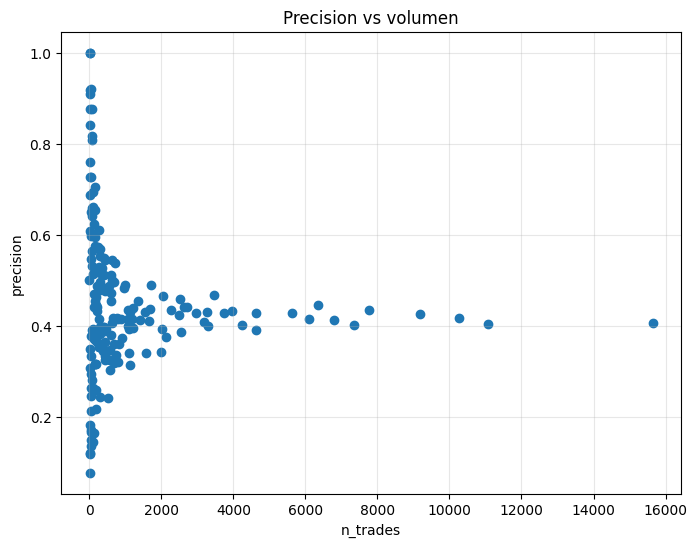

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    df_threshold_analysis["n_trades"],
    df_threshold_analysis["precision"]
)
plt.xlabel("n_trades")
plt.ylabel("precision")
plt.title("Precision vs volumen")
plt.grid(True, alpha=0.3)
plt.show()

**Observaciones sobre el gráfico (precision vs volumen)**

- La zona útil se encuentra en valores intermedios de volumen con precisión aceptable  
- Alta precisión con bajo número de trades no es operativamente relevante  
- A mayor volumen, la precisión converge en torno a 0.40–0.45  
- No se observan configuraciones con alta precisión y alto volumen simultáneamente  

**Observaciones sobre los resultados**

- El percentil p40 domina claramente  
- El threshold 0.30 maximiza el impacto total  
- El threshold 0.35 mejora la precisión con una reducción moderada del volumen  
- Las ventanas de 30 y 60 minutos son las más consistentes  
- El horizonte 90 pierde estabilidad relativa  

**Interpretación del trade-off**

- threshold 0.30 → máximo volumen, precisión moderada (~0.40)  
- threshold 0.35 → mejor equilibrio (~0.43–0.45)  
- threshold ≥ 0.40 → demasiado restrictivo  

**Insight principal**

- El rendimiento depende de generar muchas oportunidades con precisión moderada  
- No es necesario maximizar precisión, sino el balance entre cantidad y calidad  

**Conclusión operativa**

- Zona óptima:
  - threshold entre 0.30 y 0.35  
  - targets basados en p40  

- Evitar:
  - thresholds altos  
  - percentiles restrictivos como p60  

**Conclusión final**

El sistema requiere volumen para explotar la señal; la precisión extrema no es el objetivo principal.

## **6. Análisis diario de operabilidad y estabilidad**

Luego de identificar las configuraciones más prometedoras mediante el análisis de thresholds y el ranking por score, el siguiente paso es evaluar su comportamiento en el tiempo.

Hasta este punto, los resultados se basan en métricas agregadas sobre todo el dataset. Sin embargo, este tipo de evaluación no permite detectar si la señal es consistente o si, por el contrario, está concentrada en pocos días específicos.

Por este motivo, se realiza un análisis diario de operabilidad y estabilidad. El objetivo es observar cómo se distribuyen las señales a lo largo del tiempo y evaluar si el modelo genera oportunidades de manera regular.

En esta etapa se trabajará únicamente con las configuraciones seleccionadas como mejores candidatas, principalmente aquellas basadas en:

- percentil p40  
- thresholds de decisión entre 0.30 y 0.35  
- ventanas de 30 y 60 minutos  

Para cada una de estas configuraciones se analizará, día a día:

- cantidad de trades  
- cantidad de señales útiles  
- precisión diaria  
- tasa de señal útil  

Este análisis permite validar si la señal es realmente explotable en la práctica, evaluando no solo su calidad promedio, sino también su estabilidad y consistencia en el tiempo.

In [ ]:
import numpy as np
import pandas as pd

# =========================================
# Configuraciones seleccionadas
# =========================================
selected_configs = [
    ("t2_p40_h30", 30, 0.30),
    ("t2_p40_h30", 60, 0.30),
    ("t2_p40_h60", 30, 0.30),
    ("t2_p40_h60", 60, 0.30),
    ("t2_p40_h30", 30, 0.35),
]

daily_rows = []
agg_rows = []

print("=" * 100)
print("ANÁLISIS DIARIO DE OPERABILIDAD Y ESTABILIDAD")
print("=" * 100)

# =========================================
# Loop por configuración
# =========================================
for target, window_size, thr in selected_configs:

    print(f"\nProcesando: {target} | L={window_size} | thr={thr}")

    df_tmp = df_pred_all.copy()

    # filtrar configuración
    df_tmp = df_tmp[
        (df_tmp["target"] == target) &
        (df_tmp["window_size"] == window_size)
    ].copy()

    # =========================================
    # Recalcular decisión probabilística
    # =========================================
    df_tmp["y_pred_new"] = 0
    df_tmp.loc[df_tmp["proba_1"] >= thr, "y_pred_new"] = 1
    df_tmp.loc[df_tmp["proba_-1"] >= thr, "y_pred_new"] = -1

    # flags
    df_tmp["is_trade"] = df_tmp["y_pred_new"] != 0
    df_tmp["is_correct"] = df_tmp["y_pred_new"] == df_tmp["y_true"]
    df_tmp["is_useful_signal"] = df_tmp["is_trade"] & df_tmp["is_correct"]

    # =========================================
    # Agrupación diaria
    # =========================================
    daily = (
        df_tmp.groupby("date")
        .agg(
            n_total=("y_true", "size"),
            n_trades=("is_trade", "sum"),
            n_useful=("is_useful_signal", "sum"),
        )
        .reset_index()
    )

    # métricas diarias
    daily["trade_rate"] = daily["n_trades"] / daily["n_total"]
    daily["useful_rate"] = daily["n_useful"] / daily["n_total"]
    daily["precision"] = np.where(
        daily["n_trades"] > 0,
        daily["n_useful"] / daily["n_trades"],
        np.nan
    )

    # metadata
    daily["target"] = target
    daily["window_size"] = window_size
    daily["threshold"] = thr

    daily_rows.append(daily)

    # =========================================
    # Métricas agregadas de estabilidad
    # =========================================
    n_days = len(daily)
    days_with_trades = (daily["n_trades"] > 0).sum()
    days_with_useful = (daily["n_useful"] > 0).sum()

    agg_rows.append({
        "target": target,
        "window_size": window_size,
        "threshold": thr,
        "n_days": n_days,
        "days_with_trades": days_with_trades,
        "days_with_useful": days_with_useful,
        "pct_days_with_trades": days_with_trades / n_days,
        "pct_days_with_useful": days_with_useful / n_days,
        "trades_per_day_mean": daily["n_trades"].mean(),
        "trades_per_day_std": daily["n_trades"].std(),
        "useful_per_day_mean": daily["n_useful"].mean(),
        "useful_per_day_std": daily["n_useful"].std(),
        "precision_mean": daily["precision"].mean(),
        "precision_std": daily["precision"].std(),
        "useful_rate_mean": daily["useful_rate"].mean(),
        "useful_rate_std": daily["useful_rate"].std(),
    })

# =========================================
# DataFrames finales
# =========================================
df_daily_analysis = pd.concat(daily_rows, ignore_index=True)
df_stability_summary = pd.DataFrame(agg_rows).sort_values(
    ["useful_rate_mean"], ascending=False
).reset_index(drop=True)

print("\nResumen de estabilidad:")
print(df_stability_summary)

ANÁLISIS DIARIO DE OPERABILIDAD Y ESTABILIDAD

Procesando: t2_p40_h30 | L=30 | thr=0.3

Procesando: t2_p40_h30 | L=60 | thr=0.3

Procesando: t2_p40_h60 | L=30 | thr=0.3

Procesando: t2_p40_h60 | L=60 | thr=0.3

Procesando: t2_p40_h30 | L=30 | thr=0.35

Resumen de estabilidad:
       target  window_size  threshold  n_days  days_with_trades  \
0  t2_p40_h30           60       0.30     222               219   
1  t2_p40_h30           30       0.30     222               222   
2  t2_p40_h60           30       0.30     222               195   
3  t2_p40_h60           60       0.30     222               179   
4  t2_p40_h30           30       0.35     222               177   

   days_with_useful  pct_days_with_trades  pct_days_with_useful  \
0               202              0.986486              0.909910   
1               210              1.000000              0.945946   
2               170              0.878378              0.765766   
3               148              0.806306           

In [ ]:
df_daily_analysis

,date,n_total,n_trades,n_useful,trade_rate,useful_rate,precision,target,window_size,threshold
0,2024-05-14,91,48,12,0.527473,0.131868,0.250000,t2_p40_h30,30,0.30
1,2024-05-15,91,60,17,0.659341,0.186813,0.283333,t2_p40_h30,30,0.30
2,2024-05-16,91,24,2,0.263736,0.021978,0.083333,t2_p40_h30,30,0.30
3,2024-05-17,91,9,3,0.098901,0.032967,0.333333,t2_p40_h30,30,0.30
4,2024-05-20,91,12,5,0.131868,0.054945,0.416667,t2_p40_h30,30,0.30
...,...,...,...,...,...,...,...,...,...,...
1105,2025-04-30,91,87,18,0.956044,0.197802,0.206897,t2_p40_h30,30,0.35
1106,2025-05-01,91,73,16,0.802198,0.175824,0.219178,t2_p40_h30,30,0.35
1107,2025-05-02,91,64,28,0.703297,0.307692,0.437500,t2_p40_h30,30,0.35
1108,2025-05-05,91,35,17,0.384615,0.186813,0.485714,t2_p40_h30,30,0.35


In [ ]:
df_stability_summary

,target,window_size,threshold,n_days,days_with_trades,days_with_useful,pct_days_with_trades,pct_days_with_useful,trades_per_day_mean,trades_per_day_std,useful_per_day_mean,useful_per_day_std,precision_mean,precision_std,useful_rate_mean,useful_rate_std
0,t2_p40_h30,60,0.30,222,219,202,0.986486,0.909910,46.274775,19.487812,19.256757,15.822883,0.390316,0.268265,0.315685,0.259392
1,t2_p40_h30,30,0.30,222,222,210,1.000000,0.945946,70.513514,25.904057,28.581081,19.776814,0.383363,0.224788,0.314078,0.217328
2,t2_p40_h60,30,0.30,222,195,170,0.878378,0.765766,49.918919,34.691174,20.157658,22.854199,0.389761,0.317853,0.221513,0.251145
3,t2_p40_h60,60,0.30,222,179,148,0.806306,0.666667,30.626126,25.121602,12.626126,16.419000,0.399519,0.360621,0.206986,0.269164
4,t2_p40_h30,30,0.35,222,177,152,0.797297,0.684685,34.986486,32.235485,15.157658,17.700817,0.414660,0.303877,0.166568,0.194514


**Observaciones de estabilidad**

- t2_p40_h30 (L=30 y 60, thr=0.30) son claramente los mejores:
  - operan casi todos los días (~99–100%)
  - alta presencia de señales útiles (~91–95%)
  - mayor useful_rate_mean (~0.31)

- L=30 vs L=60 (mismo target):
  - L=30 → más trades (~70/día), más útiles (~28/día)
  - L=60 → más estable (menor std), menos ruido
  - trade-off: volumen vs estabilidad

- t2_p40_h60 pierde fuerza:
  - menor cobertura de días (~80–87%)
  - menor useful_rate (~0.20–0.22)
  - más inestable (std alto)

- threshold 0.35:
  - mejora precisión (~0.41)
  - pero reduce mucho volumen y cobertura
  - peor impacto total (useful_rate baja)

**Observaciones de riesgo**

- desviaciones estándar altas:
  - precision_std ~0.22–0.36
  - indica alta variabilidad diaria
  - días muy buenos y días muy malos

- useful_rate_std elevado:
  - señal no completamente estable
  - posible concentración en ciertos días

**Conclusión operativa**

- mejor configuración:
  - t2_p40_h30
  - threshold 0.30
  - ventana 30 o 60

- interpretación:
  - L=30 → más agresivo (más oportunidades)
  - L=60 → más conservador (más estable)

**Conclusión final**

El sistema es operativamente viable:
- genera señales casi todos los días
- mantiene una tasa útil consistente (~31%)

Pero:
- presenta variabilidad significativa
- requiere control de riesgo en implementación real

## **7. Análisis ecónomico de target**

RESULTADOS ECONÓMICOS
n_trades        : 15654
win_rate        : 52.13%
avg_pnl         : 8.92 USD
total_pnl       : 139594.00 USD
profit_factor   : 1.16
max_drawdown    : -53754.00 USD


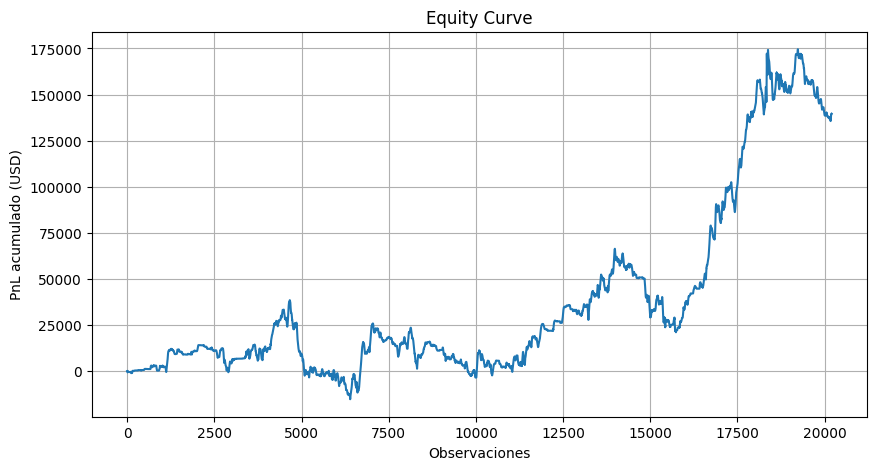

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# Configuración
# =========================================

target = "t2_p40_h30"
window_size = 30
threshold = 0.30

horizon = int(target.split("_h")[-1])  # ej: 30

# costo por trade (ajústalo)
cost_per_trade = 1.0  # USD por trade (ejemplo)

# =========================================
# Filtrar dataset
# =========================================

df = df_pred_all.copy()

df = df[
    (df["target"] == target) &
    (df["window_size"] == window_size)
].copy()

# =========================================
# Regla de decisión (probabilística)
# =========================================

df["y_pred_new"] = 0

df.loc[df["proba_1"] >= threshold, "y_pred_new"] = 1
df.loc[df["proba_-1"] >= threshold, "y_pred_new"] = -1

df["is_trade"] = df["y_pred_new"] != 0

# =========================================
# Obtener delta desde dataset original
# =========================================

delta_col = f"delta_{horizon}"

df_base = mnq_intraday_ind[["date", "minute_of_day", delta_col]].copy()

df = df.merge(
    df_base,
    on=["date", "minute_of_day"],
    how="left"
)

df.rename(columns={delta_col: "delta"}, inplace=True)

# chequeo
missing = df["delta"].isna().sum()
if missing > 0:
    print(f"WARNING: {missing} filas sin delta")

# =========================================
# PnL
# =========================================

# PnL en puntos
df["pnl_pts"] = df["y_pred_new"] * df["delta"]

# convertir a USD (MNQ = 2 USD por punto)
df["pnl_usd"] = df["pnl_pts"] * 2

# aplicar costos SOLO cuando hay trade
df["pnl_net"] = df["pnl_usd"] - np.where(df["is_trade"], cost_per_trade, 0)

# =========================================
# Equity curve
# =========================================

df = df.sort_values(["date", "minute_of_day"])

df["equity"] = df["pnl_net"].cumsum()

# =========================================
# Métricas económicas
# =========================================

df_trades = df[df["is_trade"]].copy()

n_trades = len(df_trades)
wins = (df_trades["pnl_net"] > 0).sum()
losses = (df_trades["pnl_net"] <= 0).sum()

win_rate = wins / n_trades if n_trades > 0 else 0

avg_pnl = df_trades["pnl_net"].mean()

gross_profit = df_trades[df_trades["pnl_net"] > 0]["pnl_net"].sum()
gross_loss = df_trades[df_trades["pnl_net"] <= 0]["pnl_net"].sum()

profit_factor = abs(gross_profit / gross_loss) if gross_loss != 0 else np.inf

# Drawdown
df["cum_max"] = df["equity"].cummax()
df["drawdown"] = df["equity"] - df["cum_max"]

max_drawdown = df["drawdown"].min()

# =========================================
# Resultados
# =========================================

print("=" * 100)
print("RESULTADOS ECONÓMICOS")
print("=" * 100)
print(f"n_trades        : {n_trades}")
print(f"win_rate        : {win_rate:.2%}")
print(f"avg_pnl         : {avg_pnl:.2f} USD")
print(f"total_pnl       : {df['pnl_net'].sum():.2f} USD")
print(f"profit_factor   : {profit_factor:.2f}")
print(f"max_drawdown    : {max_drawdown:.2f} USD")
print("=" * 100)

# =========================================
# Gráfico Equity Curve
# =========================================

plt.figure(figsize=(10, 5))
plt.plot(df["equity"])
plt.title("Equity Curve")
plt.xlabel("Observaciones")
plt.ylabel("PnL acumulado (USD)")
plt.grid(True)
plt.show()

## **8. Selección final de targets a modelar**

**Objetivo**

Elegir un conjunto mínimo de targets que capture distintos regímenes de operabilidad y trade-offs entre volumen y calidad, permitiendo evaluar si otros modelos o features pueden explotar mejor cada caso.

Targets seleccionados

1. t2_p40_h30 | threshold = 0.30
   - mejor score global
   - máxima señal disponible
   - alta frecuencia de trades
   - baseline principal

2. t2_p40_h30 | threshold = 0.35
   - misma estructura que el mejor target
   - menor volumen, mayor precisión
   - permite evaluar impacto de mayor selectividad

3. t2_p40_h60 | threshold = 0.30
   - mismo percentil (p40)
   - distinto horizonte temporal
   - captura dinámica más lenta
   - útil para comparar sensibilidad temporal del modelo

4. t2_p50_h30 | threshold = 0.30
   - percentil más exigente (menos ruido)
   - menor volumen que p40
   - permite evaluar si modelos más complejos capturan mejor señales más limpias

Justificación de la selección

- p40 vs p50:
  - p40 → máxima operabilidad
  - p50 → mayor exigencia (más limpio)

- threshold 0.30 vs 0.35:
  - 0.30 → agresivo (volumen)
  - 0.35 → más conservador (calidad)

- h30 vs h60:
  - h30 → dinámica rápida intradía
  - h60 → movimientos más estables

**Cobertura del espacio de decisión**

Este conjunto permite cubrir:

- volumen alto vs moderado
- precisión moderada vs mayor
- horizontes rápidos vs intermedios
- targets más ruidosos vs más selectivos

**Conclusión**

Estos 4 targets representan distintos escenarios del problema y permiten evaluar de forma robusta:

- si el edge depende del target
- si modelos más complejos mejoran targets más exigentes
- si existe una mejor combinación modelo + target

No se busca un único target óptimo, sino identificar qué combinación es más explotable.

## **9. Cierre**

### 9.1. Guardar resultados

In [ ]:
from pathlib import Path

# =========================================
# Carpeta base
# =========================================
OUTPUT_DIR = Path("/content/drive/MyDrive/neural_profit/T2_v2_investigation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================
# Guardado principal
# =========================================
df_pred_all.to_parquet(OUTPUT_DIR / "df_pred_all_probabilistic.parquet", index=False)
df_metrics_all.to_parquet(OUTPUT_DIR / "df_metrics_all_targets_v0.parquet", index=False)
df_threshold_analysis.to_parquet(OUTPUT_DIR / "df_threshold_analysis.parquet", index=False)
df_stability_summary.to_parquet(OUTPUT_DIR / "df_stability_summary.parquet", index=False)
df_daily_analysis.to_parquet(OUTPUT_DIR / "df_daily_analysis.parquet", index=False)

print("Archivos guardados en:")
for p in [
    "df_pred_all_probabilistic.parquet",
    "df_metrics_all_targets_v0.parquet",
    "df_threshold_analysis.parquet",
    "df_stability_summary.parquet",
    "df_daily_analysis.parquet",
]:
    print(OUTPUT_DIR / p)

Archivos guardados en:
/content/drive/MyDrive/neural_profit/T2_v2_investigation/df_pred_all_probabilistic.parquet
/content/drive/MyDrive/neural_profit/T2_v2_investigation/df_metrics_all_targets_v0.parquet
/content/drive/MyDrive/neural_profit/T2_v2_investigation/df_threshold_analysis.parquet
/content/drive/MyDrive/neural_profit/T2_v2_investigation/df_stability_summary.parquet
/content/drive/MyDrive/neural_profit/T2_v2_investigation/df_daily_analysis.parquet


### 9.2. Guardar selección final de targets

In [ ]:
selected_targets_df = pd.DataFrame([
    {"target": "t2_p40_h30", "threshold": 0.30, "role": "baseline principal"},
    {"target": "t2_p40_h30", "threshold": 0.35, "role": "más selectivo"},
    {"target": "t2_p40_h60", "threshold": 0.30, "role": "horizonte alternativo"},
    {"target": "t2_p50_h30", "threshold": 0.30, "role": "target más limpio"},
])

selected_targets_df.to_parquet(
    OUTPUT_DIR / "selected_targets_final.parquet",
    index=False
)

selected_targets_df

,target,threshold,role
0,t2_p40_h30,0.30,baseline principal
1,t2_p40_h30,0.35,más selectivo
2,t2_p40_h60,0.30,horizonte alternativo
3,t2_p50_h30,0.30,target más limpio


### 9.3. Guardar un script .py para generar targets

In [ ]:
from pathlib import Path

OUTPUT_DIR = Path("/content/drive/MyDrive/neural_profit/T2_v2_investigation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

script_path = OUTPUT_DIR / "build_selected_t2_targets.py"

script_code = r'''
import numpy as np
import pandas as pd


SELECTED_TARGETS = [
    {"percentile": 40, "horizon": 30, "decision_threshold": 0.30, "target_name": "t2_p40_h30"},
    {"percentile": 40, "horizon": 30, "decision_threshold": 0.35, "target_name": "t2_p40_h30"},
    {"percentile": 40, "horizon": 60, "decision_threshold": 0.30, "target_name": "t2_p40_h60"},
    {"percentile": 50, "horizon": 30, "decision_threshold": 0.30, "target_name": "t2_p50_h30"},
]


def compute_thresholds_for_selected_targets(
    df: pd.DataFrame,
    *,
    regimes: tuple[int, ...] = (1, 2),
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Calcula únicamente los thresholds estructurales necesarios para los targets seleccionados.
    El decision_threshold no se usa aquí porque pertenece a la regla de decisión del modelo,
    no a la construcción del target.
    """

    if "regime_id" not in df.columns:
        raise ValueError("El DataFrame debe contener 'regime_id'")

    df_filtered = df[df["regime_id"].isin(regimes)].copy()

    if df_filtered.empty:
        raise ValueError("El DataFrame filtrado por regímenes está vacío")

    unique_pairs = sorted({
        (cfg["percentile"], cfg["horizon"])
        for cfg in SELECTED_TARGETS
    })

    rows = []

    for p, h in unique_pairs:
        delta_col = f"delta_{h}"

        if delta_col not in df_filtered.columns:
            raise ValueError(f"No existe {delta_col} en el DataFrame")

        abs_delta = df_filtered[delta_col].abs().dropna()
        thr = np.percentile(abs_delta, p)

        rows.append({
            "percentile": p,
            "horizon": h,
            "threshold_pts": float(thr),
            "threshold_usd": float(thr * 2),
        })

        if verbose:
            print(f"Threshold estructural | p={p} | h={h} | thr={thr:.2f} pts")

    return (
        pd.DataFrame(rows)
        .sort_values(["percentile", "horizon"])
        .reset_index(drop=True)
    )


def create_selected_t2_targets(
    df: pd.DataFrame,
    df_thresholds: pd.DataFrame,
    *,
    close_col: str = "close",
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    regime_col: str = "regime_id",
    threshold_col: str = "threshold_pts",
    regimes: tuple[int, ...] = (1, 2),
    validate_order: bool = True,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Crea únicamente los targets T2 seleccionados.
    """

    required_cols_df = [close_col, date_col, minute_col, regime_col]
    missing_df = [c for c in required_cols_df if c not in df.columns]
    if missing_df:
        raise ValueError(f"Faltan columnas requeridas en df: {missing_df}")

    required_cols_thr = ["percentile", "horizon", threshold_col]
    missing_thr = [c for c in required_cols_thr if c not in df_thresholds.columns]
    if missing_thr:
        raise ValueError(f"Faltan columnas requeridas en df_thresholds: {missing_thr}")

    out = df.copy()

    if validate_order:
        sorted_index = out.sort_values([date_col, minute_col]).index
        if not out.index.equals(sorted_index):
            raise ValueError(
                f"El DataFrame no está ordenado por [{date_col}, {minute_col}]."
            )

        n_dupes = out.duplicated(subset=[date_col, minute_col]).sum()
        if n_dupes > 0:
            raise ValueError(
                f"Se encontraron {n_dupes} combinaciones duplicadas de "
                f"[{date_col}, {minute_col}]."
            )

    # mapa (p,h) -> threshold estructural
    threshold_map = {
        (int(row["percentile"]), int(row["horizon"])): float(row[threshold_col])
        for _, row in df_thresholds.iterrows()
    }

    # solo horizontes necesarios
    horizons = sorted({cfg["horizon"] for cfg in SELECTED_TARGETS})

    grouped_close = out.groupby(date_col, sort=False)[close_col]

    # crear close_fwd y delta solo para horizontes requeridos
    for h in horizons:
        fwd_col = f"close_fwd_{h}"
        delta_col = f"delta_{h}"

        if fwd_col not in out.columns:
            out[fwd_col] = grouped_close.shift(-h)

        if delta_col not in out.columns:
            out[delta_col] = out[fwd_col] - out[close_col]

    mask_regime = out[regime_col].isin(regimes)
    created_target_cols = []

    # crear solo targets únicos
    unique_pairs = sorted({
        (cfg["percentile"], cfg["horizon"], cfg["target_name"])
        for cfg in SELECTED_TARGETS
    })

    for p, h, target_col in unique_pairs:
        if (p, h) not in threshold_map:
            raise ValueError(f"Falta threshold para (p={p}, h={h})")

        thr = threshold_map[(p, h)]
        fwd_col = f"close_fwd_{h}"
        delta_col = f"delta_{h}"
        delta = out[delta_col]

        out[target_col] = np.where(
            (~mask_regime) | (out[fwd_col].isna()),
            np.nan,
            np.where(
                delta > thr,
                1,
                np.where(delta < -thr, -1, 0)
            )
        ).astype("float")

        created_target_cols.append(target_col)

        if verbose:
            print(f"Target creado: {target_col} | p={p} | h={h} | thr={thr:.2f}")

    if verbose:
        print("Targets finales:", created_target_cols)

    return out


if __name__ == "__main__":
    print("Este script define funciones para construir únicamente los targets seleccionados.")
    print("Targets seleccionados:")
    for cfg in SELECTED_TARGETS:
        print(cfg)
'''

with open(script_path, "w", encoding="utf-8") as f:
    f.write(script_code)

print(f"Script guardado en: {script_path}")

Script guardado en: /content/drive/MyDrive/neural_profit/T2_v2_investigation/build_selected_t2_targets.py


Y una aclaración importante:

- t2_p40_h30 es un único target estructural.
- Lo que cambia entre 0.30 y 0.35 no es el target, sino el decision threshold de la regla probabilística.

Entonces, estructuralmente, este script solo necesita generar:

- t2_p40_h30
- t2_p40_h60
- t2_p50_h30

Qué debe quedar fijo

1. El target estructural
   Es lo que el modelo aprende a predecir.
   En esta etapa, los targets estructurales seleccionados son:

   - t2_p40_h30
   - t2_p40_h60
   - t2_p50_h30

2. El dataset base
   - mismos splits
   - mismas observaciones
   - mismo universo de regímenes

3. Las features
   - si quieres comparar modelos de forma justa, deben usar las mismas features
   - luego, en otra etapa, puedes probar nuevas features

Qué puede cambiar

1. El modelo
   - XGBoost
   - LightGBM
   - GRU
   - Transformer
   - Logistic Regression
   - Random Forest

2. La regla de decisión
   - confidence_threshold = 0.30
   - confidence_threshold = 0.35

Interpretación correcta

- El target define qué se quiere predecir
- El modelo define cómo se aprende esa señal
- El decision threshold define cuándo se convierte la predicción en operación

Conclusión

Para entrenar varios modelos de forma comparable, todos deben predecir los mismos targets estructurales.
Los thresholds 0.30 y 0.35 no generan targets distintos; generan configuraciones operativas distintas sobre el mismo target.

### 9.4. Parámetros para modelos

Qué debe quedar fijo

1. El target estructural
   Es lo que el modelo aprende a predecir.
   En esta etapa, los targets estructurales seleccionados son:

   - t2_p40_h30
   - t2_p40_h60
   - t2_p50_h30

2. El dataset base
   - mismos splits
   - mismas observaciones
   - mismo universo de regímenes

3. Las features
   - si quieres comparar modelos de forma justa, deben usar las mismas features
   - luego, en otra etapa, puedes probar nuevas features

Qué puede cambiar

1. El modelo
   - XGBoost
   - LightGBM
   - GRU
   - Transformer
   - Logistic Regression
   - Random Forest

2. La regla de decisión
   - confidence_threshold = 0.30
   - confidence_threshold = 0.35

Interpretación correcta

- El target define qué se quiere predecir
- El modelo define cómo se aprende esa señal
- El decision threshold define cuándo se convierte la predicción en operación

Conclusión

Para entrenar varios modelos de forma comparable, todos deben predecir los mismos targets estructurales.
Los thresholds 0.30 y 0.35 no generan targets distintos; generan configuraciones operativas distintas sobre el mismo target.

In [ ]:
from pathlib import Path
import json

OUTPUT_DIR = Path("/content/drive/MyDrive/neural_profit/T2_v2_investigation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config_path = OUTPUT_DIR / "selected_experiment_config.json"

experiment_config = {
    "description": "Configuración experimental final para comparar múltiples modelos sobre targets T2 seleccionados.",
    "fixed_targets": [
        "t2_p40_h30",
        "t2_p40_h60",
        "t2_p50_h30"
    ],
    "selected_target_threshold_pairs": [
        {
            "target": "t2_p40_h30",
            "decision_threshold": 0.30,
            "role": "baseline principal"
        },
        {
            "target": "t2_p40_h30",
            "decision_threshold": 0.35,
            "role": "más selectivo"
        },
        {
            "target": "t2_p40_h60",
            "decision_threshold": 0.30,
            "role": "horizonte alternativo"
        },
        {
            "target": "t2_p50_h30",
            "decision_threshold": 0.30,
            "role": "target más limpio"
        }
    ],
    "models_to_compare": [
        "xgboost",
        "lightgbm",
        "gru",
        "transformer",
        "logistic_regression",
        "random_forest"
    ],
    "notes": [
        "Todos los modelos deben predecir los mismos targets estructurales.",
        "El decision_threshold pertenece a la regla de decisión, no al target.",
        "Esto permite comparar modelos bajo el mismo problema predictivo."
    ]
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, indent=4, ensure_ascii=False)

print(f"Configuración guardada en: {config_path}")

Configuración guardada en: /content/drive/MyDrive/neural_profit/T2_v2_investigation/selected_experiment_config.json


In [ ]:
mnq_intraday_t2.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'minute_of_day',
       'regime_id', 'close_fwd_30', 'delta_30', 'close_fwd_60', 'delta_60',
       'close_fwd_90', 'delta_90', 'close_fwd_120', 'delta_120', 't2_p30_h30',
       't2_p30_h60', 't2_p30_h90', 't2_p30_h120', 't2_p40_h30', 't2_p40_h60',
       't2_p40_h90', 't2_p40_h120', 't2_p50_h30', 't2_p50_h60', 't2_p50_h90',
       't2_p50_h120', 't2_p55_h30', 't2_p55_h60', 't2_p55_h90', 't2_p55_h120',
       't2_p60_h30', 't2_p60_h60', 't2_p60_h90', 't2_p60_h120', 't2_p65_h30',
       't2_p65_h60', 't2_p65_h90', 't2_p65_h120', 't2_p70_h30', 't2_p70_h60',
       't2_p70_h90', 't2_p70_h120'],
      dtype='object')

## **10. Dataset de salida**

In [ ]:
import pandas as pd

# =========================================
# Columnas base
# =========================================
base_cols = [
    "date",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "minute_of_day",
    "regime_id",
]

# =========================================
# Horizontes que usamos
# =========================================
horizons = [30, 60]

derived_cols = []
for h in horizons:
    derived_cols += [
        f"close_fwd_{h}",
        f"delta_{h}",
    ]

# =========================================
# Targets seleccionados
# =========================================
target_cols = [
    "t2_p40_h30",
    "t2_p40_h60",
    "t2_p50_h30",
]

# =========================================
# Dataset final
# =========================================
cols_final = base_cols + derived_cols + target_cols

mnq_intraday_t2 = mnq_intraday_t2[cols_final].copy()

print("Columnas finales:")
print(mnq_intraday_t2.columns)
print(f"\nShape: {mnq_intraday_t2.shape}")

Columnas finales:
Index(['date', 'open', 'high', 'low', 'close', 'volume', 'minute_of_day',
       'regime_id', 'close_fwd_30', 'delta_30', 'close_fwd_60', 'delta_60',
       't2_p40_h30', 't2_p40_h60', 't2_p50_h30'],
      dtype='object')

Shape: (1024062, 15)


In [ ]:
OUT_PARQUET = DRIVE_DIR / Path(os.environ.get("OUT_PARQUET", "data/03_targets/mnq_intraday_t2.parquet"))


In [ ]:
OUT_PARQUET.parent.mkdir(parents=True, exist_ok=True)

# =========================================
# Guardar dataset limpio
# =========================================
mnq_intraday_t2.to_parquet(OUT_PARQUET, index=True)

print(f"Dataset guardado en: {OUT_PARQUET}")
print(f"Shape: {mnq_intraday_t2.shape}")

Dataset guardado en: /content/drive/MyDrive/neural_profit/data/03_targets/mnq_intraday_t2.parquet
Shape: (1024062, 15)


In [ ]:
mnq_intraday_t2

,date,open,high,low,close,volume,minute_of_day,regime_id,close_fwd_30,delta_30,close_fwd_60,delta_60,t2_p40_h30,t2_p40_h60,t2_p50_h30
datetime,,,,,,,,,,,,,,,
2020-01-02 04:30:00-05:00,2020-01-02,8813.25,8813.25,8812.50,8813.25,13,270,0,8815.75,2.50,8819.25,6.00,NaN,NaN,NaN
2020-01-02 04:31:00-05:00,2020-01-02,8812.50,8812.50,8811.00,8812.50,121,271,0,8815.75,3.25,8818.75,6.25,NaN,NaN,NaN
2020-01-02 04:32:00-05:00,2020-01-02,8812.50,8813.25,8811.75,8811.75,53,272,0,8817.50,5.75,8819.00,7.25,NaN,NaN,NaN
2020-01-02 04:33:00-05:00,2020-01-02,8812.00,8812.25,8810.50,8810.50,37,273,0,8816.00,5.50,8818.25,7.75,NaN,NaN,NaN
2020-01-02 04:34:00-05:00,2020-01-02,8810.75,8812.25,8810.50,8812.00,36,274,0,8816.00,4.00,8818.75,6.75,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-17 15:56:00-04:00,2026-04-17,26815.50,26829.00,26814.25,26820.00,4185,956,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-17 15:57:00-04:00,2026-04-17,26819.75,26830.00,26815.00,26817.50,2536,957,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-17 15:58:00-04:00,2026-04-17,26818.00,26824.50,26809.00,26823.75,2518,958,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# =========================================================
# FILTRAR FILAS VÁLIDAS PARA TARGETS T2
# =========================================================

t2_cols = [
    "t2_p40_h30",
    "t2_p40_h60",
    "t2_p50_h30",
]

mnq_intraday_t2 = (
    mnq_intraday_t2
    .dropna(subset=t2_cols)
    .copy()
)

# =========================================================
# VERIFICACIÓN
# =========================================================

print("Shape final:", mnq_intraday_t2.shape)

print("\nNaNs restantes:")
print(mnq_intraday_t2[t2_cols].isna().sum())

print("\nDistribución targets:")
for col in t2_cols:
    print(f"\n{col}")
    print(mnq_intraday_t2[col].value_counts().sort_index())

Shape final: (177840, 15)

NaNs restantes:
t2_p40_h30    0
t2_p40_h60    0
t2_p50_h30    0
dtype: int64

Distribución targets:

t2_p40_h30
t2_p40_h30
-1.0    51052
 0.0    71511
 1.0    55277
Name: count, dtype: int64

t2_p40_h60
t2_p40_h60
-1.0    50762
 0.0    71534
 1.0    55544
Name: count, dtype: int64

t2_p50_h30
t2_p50_h30
-1.0    42980
 0.0    88933
 1.0    45927
Name: count, dtype: int64


In [ ]:
mnq_intraday_t2

,date,open,high,low,close,volume,minute_of_day,regime_id,close_fwd_30,delta_30,close_fwd_60,delta_60,t2_p40_h30,t2_p40_h60,t2_p50_h30
datetime,,,,,,,,,,,,,,,
2020-01-02 08:30:00-05:00,2020-01-02,8823.25,8823.50,8821.50,8822.50,61,510,1,8828.25,5.75,8820.50,-2.00,0.0,0.0,0.0
2020-01-02 08:31:00-05:00,2020-01-02,8822.75,8823.75,8822.00,8822.25,86,511,1,8828.00,5.75,8826.00,3.75,0.0,0.0,0.0
2020-01-02 08:32:00-05:00,2020-01-02,8823.00,8823.75,8822.50,8823.75,42,512,1,8826.00,2.25,8818.75,-5.00,0.0,0.0,0.0
2020-01-02 08:33:00-05:00,2020-01-02,8824.25,8825.75,8823.50,8825.75,134,513,1,8822.00,-3.75,8821.75,-4.00,0.0,0.0,0.0
2020-01-02 08:34:00-05:00,2020-01-02,8826.00,8826.50,8825.25,8826.00,102,514,1,8823.50,-2.50,8831.50,5.50,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-17 10:25:00-04:00,2026-04-17,26732.00,26743.75,26727.00,26738.75,3655,625,2,26838.25,99.50,26839.00,100.25,1.0,1.0,1.0
2026-04-17 10:26:00-04:00,2026-04-17,26739.25,26744.75,26733.50,26738.50,3076,626,2,26804.75,66.25,26835.00,96.50,1.0,1.0,1.0
2026-04-17 10:27:00-04:00,2026-04-17,26738.50,26748.50,26729.50,26733.50,4018,627,2,26832.75,99.25,26845.75,112.25,1.0,1.0,1.0


# **Introducción — Investigación de targets operativos (T3 y T4)**

La etapa desarrollada sobre el target T2 permitió validar que los modelos de machine learning poseen capacidad de capturar señal predictiva real sobre el comportamiento futuro del mercado.

A lo largo del análisis se construyó un pipeline completo que incluyó:

- generación de datasets secuenciales
- entrenamiento de modelos tabulares y recurrentes
- evaluación out-of-sample
- calibración de thresholds
- construcción de señales operativas
- evaluación económica mediante PnL
- análisis de equity curve y drawdown
- simulación bajo reglas reales de fondeo

Los resultados obtenidos demostraron que el modelo GRU logra generar señales con ventaja estadística y capacidad de producir PnL positivo fuera de muestra.

Sin embargo, la etapa de simulación operativa permitió identificar una limitación crítica:

una estrategia puede tener edge predictivo y aun así no ser operable bajo condiciones reales de trading.

Limitaciones del target T2
--------------------------

El target T2 representa un enfoque direccional basado en movimientos futuros del precio.

Conceptualmente, responde preguntas del tipo:

> “¿el mercado se moverá una cantidad significativa de puntos en determinada dirección?”

Este enfoque resulta útil para detectar estructura predictiva en el mercado, pero presenta limitaciones importantes desde el punto de vista operativo.

En particular, T2 no incorpora explícitamente:

- riesgo asumido durante la operación
- secuencia temporal del movimiento
- relación riesgo/beneficio
- comportamiento adverso previo
- ejecución real de stops y take profits
- estabilidad del trade bajo drawdown

Como consecuencia, el modelo aprende principalmente dirección futura del mercado, pero no necesariamente calidad operativa de una posición.

Esto explica por qué el sistema puede mostrar:

- accuracy razonable
- PnL positivo
- ventaja estadística

y aun así:

- generar drawdowns elevados
- producir curvas de equity inestables
- fallar bajo reglas de fondeo

Transición hacia targets operativos
-----------------------------------

A partir de estos resultados, el enfoque del proyecto evoluciona desde targets puramente direccionales hacia targets orientados explícitamente a operabilidad.

La transición conceptual puede resumirse de la siguiente forma:

```text
T2 → predicción direccional
T3 → predicción de calidad operativa
T4 → predicción basada en ejecución real
````

Este cambio modifica profundamente la naturaleza del problema.

Con T2:

* el target representa comportamiento futuro del mercado

Con T3 y T4:

* el target representa calidad y viabilidad de trades reales

De esta forma, el aprendizaje deja de centrarse únicamente en dirección y pasa a enfocarse en supervivencia operativa, control de riesgo y estabilidad económica.

**T3 — Outcome de trade**
-------------------------
El target T3 propone reformular el problema como una evaluación de calidad de operación.

En lugar de predecir directamente el movimiento del mercado, el modelo busca responder:

> “¿esta señal tiene probabilidad de convertirse en un trade exitoso?”

El objetivo pasa a ser distinguir entre:

* trades operables
* trades no operables

Este enfoque acerca el modelo a decisiones reales de trading, permitiendo evaluar la utilidad económica de una señal y no solamente su dirección.

**T4 — Target basado en eventos**
--------------------------------
El target T4 representa una evolución aún más alineada con trading profesional y reglas reales de fondeo.

En este caso, el target se define en función del resultado de eventos futuros asociados a una operación concreta.

Por ejemplo:

* TP = +40 puntos
* SL = -20 puntos
* horizonte máximo = 30 barras

y el target queda definido como:

```text
1  → take profit alcanzado primero
-1 → stop loss alcanzado primero
0  → ninguna condición alcanzada
```

Este enfoque introduce explícitamente:

* relación riesgo/beneficio
* secuencia temporal
* ejecución realista
* control implícito de drawdown
* compatibilidad con gestión operativa

De esta forma, el modelo deja de aprender únicamente movimientos del precio y comienza a aprender estructuras asociadas a trades económicamente viables.

## Importancia para estrategias de fondeo

Las empresas de fondeo no evalúan únicamente capacidad predictiva.

En la práctica, las métricas realmente relevantes son:

* estabilidad de la curva de equity
* control de drawdown
* supervivencia operativa
* consistencia temporal
* relación entre retorno y riesgo

Por esta razón, targets como T3 y especialmente T4 presentan una alineación mucho más natural con condiciones reales de trading profesional.

En particular, un target basado en eventos permite penalizar directamente operaciones que:

* alcanzan el stop loss primero
* presentan recorridos adversos elevados
* generan riesgo operativo excesivo

incluso cuando posteriormente el mercado termina moviéndose en la dirección esperada.

## Nuevo criterio de evaluación

A partir de esta etapa, el criterio principal de evaluación deja de ser exclusivamente:

* accuracy
* F1-score
* precisión direccional

y pasa a incorporar prioritariamente:

* drawdown máximo
* estabilidad del equity
* profit factor
* supervivencia bajo reglas de fondeo
* suavidad de la curva de capital
* consistencia operativa

El objetivo ya no es únicamente predecir el mercado, sino identificar operaciones compatibles con restricciones reales de riesgo.

## Objetivo de la siguiente etapa

La siguiente fase de investigación buscará desarrollar targets más cercanos a ejecución operativa real, comenzando con enfoques T3 y evolucionando progresivamente hacia targets T4 basados en eventos.

Esto permitirá trasladar el problema desde:

- predicción de dirección futura

hacia:

- predicción de trades económicamente viables y compatibles con condiciones reales de operación profesional.

# **Target T3 — Outcome de trade**

Percentil: 40
-------------------------------------------------------------------------------
h=30 | thr=19.50 pts | ≈ 39.00 USD
h=60 | thr=33.50 pts | ≈ 67.00 USD

Percentil: 50
--------------------------------------------------------------------------------
h=30 | thr=26.25 pts | ≈ 52.50 USD



In [ ]:
import numpy as np
import pandas as pd

# =========================================================
# CONFIGURACIÓN T3 CORRECTO
# =========================================================

T3_CONFIGS = {
    "t2_p40_h30": {
        "horizon": 30,
        "tp_points": 19.50,
        "sl_points": 19.50,
    },
    "t2_p40_h60": {
        "horizon": 60,
        "tp_points": 33.50,
        "sl_points": 33.50,
    },
    "t2_p50_h30": {
        "horizon": 30,
        "tp_points": 26.25,
        "sl_points": 26.25,
    },
}

COST_POINTS = 0.0


# =========================================================
# FUNCIÓN T3 CORRECTA
# =========================================================

def add_t3_targets_from_t2_event_based(
    df,
    configs,
    cost_points=0.0,
    keep_neutral_as_nan=True,
):
    df = df.copy()

    for t2_col, cfg in configs.items():

        horizon = cfg["horizon"]
        tp_points = cfg["tp_points"]
        sl_points = cfg["sl_points"]

        signal_col = f"signal_{t2_col}"
        t3_col = f"t3_trade_outcome_{t2_col}"
        exit_reason_col = f"t3_exit_reason_{t2_col}"
        pnl_col = f"t3_net_pnl_{t2_col}"
        mfe_col = f"t3_mfe_{t2_col}"
        mae_col = f"t3_mae_{t2_col}"

        df[signal_col] = df[t2_col].astype(float)

        t3_values = []
        exit_reasons = []
        pnl_values = []
        mfe_values = []
        mae_values = []

        for i in range(len(df)):

            signal = df[signal_col].iloc[i]

            if signal == 0 or pd.isna(signal):
                t3_values.append(np.nan if keep_neutral_as_nan else 0)
                exit_reasons.append("no_trade")
                pnl_values.append(np.nan if keep_neutral_as_nan else 0.0)
                mfe_values.append(np.nan)
                mae_values.append(np.nan)
                continue

            if i + horizon >= len(df):
                t3_values.append(np.nan)
                exit_reasons.append("no_future_data")
                pnl_values.append(np.nan)
                mfe_values.append(np.nan)
                mae_values.append(np.nan)
                continue

            entry_price = df["close"].iloc[i]

            future_high = df["high"].iloc[i + 1 : i + horizon + 1].values
            future_low = df["low"].iloc[i + 1 : i + horizon + 1].values
            future_close = df["close"].iloc[i + horizon]

            # =================================================
            # LONG
            # =================================================
            if signal == 1:

                tp_price = entry_price + tp_points
                sl_price = entry_price - sl_points

                tp_hit = future_high >= tp_price
                sl_hit = future_low <= sl_price

                mfe = future_high.max() - entry_price
                mae = future_low.min() - entry_price

                tp_idx = np.argmax(tp_hit) if tp_hit.any() else None
                sl_idx = np.argmax(sl_hit) if sl_hit.any() else None

                if tp_idx is not None and sl_idx is not None:
                    if tp_idx < sl_idx:
                        pnl = tp_points - cost_points
                        t3 = 1
                        reason = "take_profit"
                    else:
                        pnl = -sl_points - cost_points
                        t3 = 0
                        reason = "stop_loss"

                elif tp_idx is not None:
                    pnl = tp_points - cost_points
                    t3 = 1
                    reason = "take_profit"

                elif sl_idx is not None:
                    pnl = -sl_points - cost_points
                    t3 = 0
                    reason = "stop_loss"

                else:
                    pnl = (future_close - entry_price) - cost_points
                    t3 = int(pnl > 0)
                    reason = "horizon_exit"

            # =================================================
            # SHORT
            # =================================================
            elif signal == -1:

                tp_price = entry_price - tp_points
                sl_price = entry_price + sl_points

                tp_hit = future_low <= tp_price
                sl_hit = future_high >= sl_price

                mfe = entry_price - future_low.min()
                mae = entry_price - future_high.max()

                tp_idx = np.argmax(tp_hit) if tp_hit.any() else None
                sl_idx = np.argmax(sl_hit) if sl_hit.any() else None

                if tp_idx is not None and sl_idx is not None:
                    if tp_idx < sl_idx:
                        pnl = tp_points - cost_points
                        t3 = 1
                        reason = "take_profit"
                    else:
                        pnl = -sl_points - cost_points
                        t3 = 0
                        reason = "stop_loss"

                elif tp_idx is not None:
                    pnl = tp_points - cost_points
                    t3 = 1
                    reason = "take_profit"

                elif sl_idx is not None:
                    pnl = -sl_points - cost_points
                    t3 = 0
                    reason = "stop_loss"

                else:
                    pnl = (entry_price - future_close) - cost_points
                    t3 = int(pnl > 0)
                    reason = "horizon_exit"

            else:
                t3 = np.nan
                pnl = np.nan
                reason = "invalid_signal"
                mfe = np.nan
                mae = np.nan

            t3_values.append(t3)
            exit_reasons.append(reason)
            pnl_values.append(pnl)
            mfe_values.append(mfe)
            mae_values.append(mae)

        df[t3_col] = pd.Series(t3_values, index=df.index).astype(float)
        df[exit_reason_col] = exit_reasons
        df[pnl_col] = pnl_values
        df[mfe_col] = mfe_values
        df[mae_col] = mae_values

        print("=" * 100)
        print(f"T3 recalculado correctamente desde: {t2_col}")
        print(f"Horizonte: {horizon} minutos")
        print(f"TP: {tp_points} puntos | SL: {sl_points} puntos | Costos: {cost_points} puntos")
        print("-" * 100)
        print("Distribución T3:")
        print(df[t3_col].value_counts(dropna=False).sort_index())
        print("\nMotivos de salida:")
        print(df[exit_reason_col].value_counts(dropna=False))
        print("\nPnL medio:")
        print(df[pnl_col].mean())
        print()

    return df


# =========================================================
# APLICAR AL DATASET
# =========================================================

mnq_intraday_t3 = add_t3_targets_from_t2_event_based(
    df=mnq_intraday_t2,
    configs=T3_CONFIGS,
    cost_points=COST_POINTS,
    keep_neutral_as_nan=True,
)


# =========================================================
# VERIFICACIÓN FINAL
# =========================================================

t3_cols = [f"t3_trade_outcome_{col}" for col in T3_CONFIGS.keys()]

print("=" * 100)
print("COLUMNAS T3 RECALCULADAS")
print("=" * 100)
print(t3_cols)

print("\nDistribución final:")
for col in t3_cols:
    print("\n" + col)
    print(mnq_intraday_t3[col].value_counts(dropna=False).sort_index())
    print(mnq_intraday_t3[col].value_counts(normalize=True, dropna=True).sort_index())

T3 recalculado correctamente desde: t2_p40_h30
Horizonte: 30 minutos
TP: 19.5 puntos | SL: 19.5 puntos | Costos: 0.0 puntos
----------------------------------------------------------------------------------------------------
Distribución T3:
t3_trade_outcome_t2_p40_h30
0.0000    28930
1.0000    77372
NaN       71538
Name: count, dtype: int64

Motivos de salida:
t3_exit_reason_t2_p40_h30
take_profit       77314
no_trade          71511
stop_loss         28848
horizon_exit        140
no_future_data       27
Name: count, dtype: int64

PnL medio:
8.888362871818028

T3 recalculado correctamente desde: t2_p40_h60
Horizonte: 60 minutos
TP: 33.5 puntos | SL: 33.5 puntos | Costos: 0.0 puntos
----------------------------------------------------------------------------------------------------
Distribución T3:
t3_trade_outcome_t2_p40_h60
0.0000    25601
1.0000    80645
NaN       71594
Name: count, dtype: int64

Motivos de salida:
t3_exit_reason_t2_p40_h60
take_profit       80371
no_trade          7

In [ ]:
mnq_intraday_t3

,date,open,high,low,close,volume,minute_of_day,regime_id,close_fwd_30,delta_30,close_fwd_60,delta_60,t2_p40_h30,t2_p40_h60,t2_p50_h30,signal_t2_p40_h30,t3_trade_outcome_t2_p40_h30,t3_exit_reason_t2_p40_h30,t3_net_pnl_t2_p40_h30,t3_mfe_t2_p40_h30,t3_mae_t2_p40_h30,signal_t2_p40_h60,t3_trade_outcome_t2_p40_h60,t3_exit_reason_t2_p40_h60,t3_net_pnl_t2_p40_h60,t3_mfe_t2_p40_h60,t3_mae_t2_p40_h60,signal_t2_p50_h30,t3_trade_outcome_t2_p50_h30,t3_exit_reason_t2_p50_h30,t3_net_pnl_t2_p50_h30,t3_mfe_t2_p50_h30,t3_mae_t2_p50_h30
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-02 08:30:00-05:00,2020-01-02,"8,823.2500","8,823.5000","8,821.5000","8,822.5000",61,510,1,"8,828.2500",5.7500,"8,820.5000",-2.0000,0.0000,0.0000,0.0000,0.0000,NaN,no_trade,NaN,NaN,NaN,0.0000,NaN,no_trade,NaN,NaN,NaN,0.0000,NaN,no_trade,NaN,NaN,NaN
2020-01-02 08:31:00-05:00,2020-01-02,"8,822.7500","8,823.7500","8,822.0000","8,822.2500",86,511,1,"8,828.0000",5.7500,"8,826.0000",3.7500,0.0000,0.0000,0.0000,0.0000,NaN,no_trade,NaN,NaN,NaN,0.0000,NaN,no_trade,NaN,NaN,NaN,0.0000,NaN,no_trade,NaN,NaN,NaN
2020-01-02 08:32:00-05:00,2020-01-02,"8,823.0000","8,823.7500","8,822.5000","8,823.7500",42,512,1,"8,826.0000",2.2500,"8,818.7500",-5.0000,0.0000,0.0000,0.0000,0.0000,NaN,no_trade,NaN,NaN,NaN,0.0000,NaN,no_trade,NaN,NaN,NaN,0.0000,NaN,no_trade,NaN,NaN,NaN
2020-01-02 08:33:00-05:00,2020-01-02,"8,824.2500","8,825.7500","8,823.5000","8,825.7500",134,513,1,"8,822.0000",-3.7500,"8,821.7500",-4.0000,0.0000,0.0000,0.0000,0.0000,NaN,no_trade,NaN,NaN,NaN,0.0000,NaN,no_trade,NaN,NaN,NaN,0.0000,NaN,no_trade,NaN,NaN,NaN
2020-01-02 08:34:00-05:00,2020-01-02,"8,826.0000","8,826.5000","8,825.2500","8,826.0000",102,514,1,"8,823.5000",-2.5000,"8,831.5000",5.5000,0.0000,0.0000,0.0000,0.0000,NaN,no_trade,NaN,NaN,NaN,0.0000,NaN,no_trade,NaN,NaN,NaN,0.0000,NaN,no_trade,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-17 10:25:00-04:00,2026-04-17,"26,732.0000","26,743.7500","26,727.0000","26,738.7500",3655,625,2,"26,838.2500",99.5000,"26,839.0000",100.2500,1.0000,1.0000,1.0000,1.0000,NaN,no_future_data,NaN,NaN,NaN,1.0000,NaN,no_future_data,NaN,NaN,NaN,1.0000,NaN,no_future_data,NaN,NaN,NaN
2026-04-17 10:26:00-04:00,2026-04-17,"26,739.2500","26,744.7500","26,733.5000","26,738.5000",3076,626,2,"26,804.7500",66.2500,"26,835.0000",96.5000,1.0000,1.0000,1.0000,1.0000,NaN,no_future_data,NaN,NaN,NaN,1.0000,NaN,no_future_data,NaN,NaN,NaN,1.0000,NaN,no_future_data,NaN,NaN,NaN
2026-04-17 10:27:00-04:00,2026-04-17,"26,738.5000","26,748.5000","26,729.5000","26,733.5000",4018,627,2,"26,832.7500",99.2500,"26,845.7500",112.2500,1.0000,1.0000,1.0000,1.0000,NaN,no_future_data,NaN,NaN,NaN,1.0000,NaN,no_future_data,NaN,NaN,NaN,1.0000,NaN,no_future_data,NaN,NaN,NaN


In [ ]:
import numpy as np
import pandas as pd

# =========================================================
# 1) CONFIGURACIÓN GENERAL T3 NUEVO
# =========================================================

t3_configs = {
    "t3_trade_outcome_t2_p40_h30": {
        "t2_col": "t2_p40_h30",
        "signal_col": "signal_t2_p40_h30",
        "pnl_col": "t3_net_pnl_t2_p40_h30",
        "exit_reason_col": "t3_exit_reason_t2_p40_h30",
    },
    "t3_trade_outcome_t2_p40_h60": {
        "t2_col": "t2_p40_h60",
        "signal_col": "signal_t2_p40_h60",
        "pnl_col": "t3_net_pnl_t2_p40_h60",
        "exit_reason_col": "t3_exit_reason_t2_p40_h60",
    },
    "t3_trade_outcome_t2_p50_h30": {
        "t2_col": "t2_p50_h30",
        "signal_col": "signal_t2_p50_h30",
        "pnl_col": "t3_net_pnl_t2_p50_h30",
        "exit_reason_col": "t3_exit_reason_t2_p50_h30",
    },
}

t3_cols = list(t3_configs.keys())


# =========================================================
# 2) FUNCIÓN DRAWDOWN
# =========================================================

def calculate_drawdown(pnl_series):

    pnl_series = pnl_series.fillna(0)

    equity = pnl_series.cumsum()

    running_max = equity.cummax()

    drawdown = equity - running_max

    return drawdown.min()


# =========================================================
# 3) DISTRIBUCIÓN DE CLASES T3
# =========================================================

class_distribution_rows = []

for t3_col in t3_cols:

    total_rows = len(mnq_intraday_t3)

    n_nan = mnq_intraday_t3[t3_col].isna().sum()

    n_valid = mnq_intraday_t3[t3_col].notna().sum()

    counts = (
        mnq_intraday_t3[t3_col]
        .value_counts(dropna=True)
        .sort_index()
    )

    ratios = (
        mnq_intraday_t3[t3_col]
        .value_counts(normalize=True, dropna=True)
        .sort_index()
    )

    class_distribution_rows.append({
        "target_t3": t3_col,
        "total_rows": total_rows,
        "valid_trades": n_valid,
        "nan_no_trade": n_nan,
        "class_0_count": int(counts.get(0.0, 0)),
        "class_1_count": int(counts.get(1.0, 0)),
        "class_0_ratio": ratios.get(0.0, 0.0),
        "class_1_ratio": ratios.get(1.0, 0.0),
    })

df_t3_class_distribution = pd.DataFrame(class_distribution_rows)


# =========================================================
# 4) DATASETS FILTRADOS POR T3
# =========================================================

t3_trade_datasets = {}

for t3_col in t3_cols:

    t3_trade_datasets[t3_col] = (
        mnq_intraday_t3
        .dropna(subset=[t3_col])
        .copy()
    )


# =========================================================
# 5) RESUMEN OPERATIVO T3
# =========================================================

pnl_summary_rows = []

for t3_col, cfg in t3_configs.items():

    df_tmp = t3_trade_datasets[t3_col].copy()

    t2_col = cfg["t2_col"]

    signal_col = cfg["signal_col"]

    pnl_col = cfg["pnl_col"]

    exit_reason_col = cfg["exit_reason_col"]

    n_trades = len(df_tmp)

    n_long = (df_tmp[signal_col] == 1).sum()

    n_short = (df_tmp[signal_col] == -1).sum()

    win_rate = (df_tmp[t3_col] == 1).mean()

    loss_rate = (df_tmp[t3_col] == 0).mean()

    net_pnl_total = df_tmp[pnl_col].sum()

    net_pnl_mean = df_tmp[pnl_col].mean()

    net_pnl_median = df_tmp[pnl_col].median()

    net_pnl_std = df_tmp[pnl_col].std()

    avg_win = (
        df_tmp
        .loc[df_tmp[t3_col] == 1, pnl_col]
        .mean()
    )

    avg_loss = (
        df_tmp
        .loc[df_tmp[t3_col] == 0, pnl_col]
        .mean()
    )

    payoff_ratio = (
        avg_win / abs(avg_loss)
        if pd.notna(avg_loss) and avg_loss < 0
        else np.nan
    )

    max_drawdown_points = calculate_drawdown(df_tmp[pnl_col])

    pnl_to_drawdown = (
        net_pnl_total / abs(max_drawdown_points)
        if max_drawdown_points < 0
        else np.nan
    )

    tp_rate = (
        df_tmp[exit_reason_col]
        .eq("take_profit")
        .mean()
    )

    sl_rate = (
        df_tmp[exit_reason_col]
        .eq("stop_loss")
        .mean()
    )

    horizon_exit_rate = (
        df_tmp[exit_reason_col]
        .eq("horizon_exit")
        .mean()
    )

    pnl_summary_rows.append({
        "target_t3": t3_col,
        "source_t2": t2_col,
        "n_trades": n_trades,
        "n_long": n_long,
        "n_short": n_short,
        "win_rate": win_rate,
        "loss_rate": loss_rate,
        "net_pnl_total_points": net_pnl_total,
        "net_pnl_mean_points": net_pnl_mean,
        "net_pnl_median_points": net_pnl_median,
        "net_pnl_std_points": net_pnl_std,
        "avg_win_points": avg_win,
        "avg_loss_points": avg_loss,
        "payoff_ratio": payoff_ratio,
        "max_drawdown_points": max_drawdown_points,
        "pnl_to_drawdown": pnl_to_drawdown,
        "tp_rate": tp_rate,
        "sl_rate": sl_rate,
        "horizon_exit_rate": horizon_exit_rate,
    })

df_t3_pnl_summary = pd.DataFrame(pnl_summary_rows)


# =========================================================
# 6) RANKING T3
# =========================================================

df_t3_ranking = (
    df_t3_pnl_summary
    .sort_values(
        by=[
            "net_pnl_total_points",
            "pnl_to_drawdown",
            "win_rate",
            "payoff_ratio",
        ],
        ascending=[False, False, False, False],
    )
    .reset_index(drop=True)
)

df_t3_ranking["rank"] = np.arange(1, len(df_t3_ranking) + 1)

best_t3_candidate = df_t3_ranking.loc[0, "target_t3"]


# =========================================================
# 7) COMPARACIÓN T2 VS T3
# =========================================================

comparison_rows = []

for t3_col, cfg in t3_configs.items():

    df_tmp = t3_trade_datasets[t3_col].copy()

    t2_col = cfg["t2_col"]

    pnl_col = cfg["pnl_col"]

    comparison_rows.append({
        "source_t2": t2_col,
        "target_t3": t3_col,
        "n_trades": len(df_tmp),
        "direct_win_rate": (df_tmp[pnl_col] > 0).mean(),
        "direct_total_pnl_points": df_tmp[pnl_col].sum(),
        "direct_mean_pnl_points": df_tmp[pnl_col].mean(),
        "t3_positive_rate": (df_tmp[t3_col] == 1).mean(),
        "t3_negative_rate": (df_tmp[t3_col] == 0).mean(),
    })

df_t2_vs_t3_comparison = pd.DataFrame(comparison_rows)


# =========================================================
# 8) RESULTADOS
# =========================================================

pd.set_option("display.max_columns", None)

pd.set_option("display.width", 200)

pd.set_option("display.float_format", "{:,.4f}".format)

print("=" * 100)
print("1) DISTRIBUCIÓN DE CLASES T3")
print("=" * 100)
display(df_t3_class_distribution)

print("\n" + "=" * 100)
print("2) RESUMEN OPERATIVO T3")
print("=" * 100)
display(df_t3_pnl_summary)

print("\n" + "=" * 100)
print("3) RANKING T3")
print("=" * 100)
display(df_t3_ranking)

print("\n" + "=" * 100)
print("4) COMPARACIÓN T2 VS T3")
print("=" * 100)
display(df_t2_vs_t3_comparison)

print("\n" + "=" * 100)
print("5) MEJOR TARGET T3")
print("=" * 100)
print(best_t3_candidate)


# =========================================================
# 9) DATASET FINAL
# =========================================================

mnq_t3_best = (
    mnq_intraday_t3
    .dropna(subset=[best_t3_candidate])
    .copy()
)

print("\n" + "=" * 100)
print("6) DATASET FINAL ENTRENAMIENTO")
print("=" * 100)

print("Target seleccionado:", best_t3_candidate)

print("Shape:", mnq_t3_best.shape)

print("\nDistribución absoluta:")

print(
    mnq_t3_best[best_t3_candidate]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nDistribución porcentual:")

print(
    mnq_t3_best[best_t3_candidate]
    .value_counts(normalize=True, dropna=False)
    .sort_index()
)

1) DISTRIBUCIÓN DE CLASES T3


,target_t3,total_rows,valid_trades,nan_no_trade,class_0_count,class_1_count,class_0_ratio,class_1_ratio
0,t3_trade_outcome_t2_p40_h30,177840,106302,71538,28930,77372,0.2721,0.7279
1,t3_trade_outcome_t2_p40_h60,177840,106246,71594,25601,80645,0.2410,0.7590
2,t3_trade_outcome_t2_p50_h30,177840,88881,88959,19270,69611,0.2168,0.7832



2) RESUMEN OPERATIVO T3


,target_t3,source_t2,n_trades,n_long,n_short,win_rate,loss_rate,net_pnl_total_points,net_pnl_mean_points,net_pnl_median_points,net_pnl_std_points,avg_win_points,avg_loss_points,payoff_ratio,max_drawdown_points,pnl_to_drawdown,tp_rate,sl_rate,horizon_exit_rate
0,t3_trade_outcome_t2_p40_h30,t2_p40_h30,106302,55250,51052,0.7279,0.2721,"944,850.7500",8.8884,19.5000,17.3446,19.4899,-19.4649,1.0013,-975.0000,969.0777,0.7273,0.2714,0.0013
1,t3_trade_outcome_t2_p40_h60,t2_p40_h60,106246,55484,50762,0.7590,0.2410,"1,843,535.7500",17.3516,33.5000,28.5769,33.4281,-33.2908,1.0041,"-2,780.5000",663.0231,0.7565,0.2385,0.0050
2,t3_trade_outcome_t2_p50_h30,t2_p50_h30,88881,45901,42980,0.7832,0.2168,"1,321,609.7500",14.8694,26.2500,21.5946,26.2200,-26.1335,1.0033,-761.2500,"1,736.1048",0.7818,0.2152,0.0030



3) RANKING T3


,target_t3,source_t2,n_trades,n_long,n_short,win_rate,loss_rate,net_pnl_total_points,net_pnl_mean_points,net_pnl_median_points,net_pnl_std_points,avg_win_points,avg_loss_points,payoff_ratio,max_drawdown_points,pnl_to_drawdown,tp_rate,sl_rate,horizon_exit_rate,rank
0,t3_trade_outcome_t2_p40_h60,t2_p40_h60,106246,55484,50762,0.7590,0.2410,"1,843,535.7500",17.3516,33.5000,28.5769,33.4281,-33.2908,1.0041,"-2,780.5000",663.0231,0.7565,0.2385,0.0050,1
1,t3_trade_outcome_t2_p50_h30,t2_p50_h30,88881,45901,42980,0.7832,0.2168,"1,321,609.7500",14.8694,26.2500,21.5946,26.2200,-26.1335,1.0033,-761.2500,"1,736.1048",0.7818,0.2152,0.0030,2
2,t3_trade_outcome_t2_p40_h30,t2_p40_h30,106302,55250,51052,0.7279,0.2721,"944,850.7500",8.8884,19.5000,17.3446,19.4899,-19.4649,1.0013,-975.0000,969.0777,0.7273,0.2714,0.0013,3



4) COMPARACIÓN T2 VS T3


,source_t2,target_t3,n_trades,direct_win_rate,direct_total_pnl_points,direct_mean_pnl_points,t3_positive_rate,t3_negative_rate
0,t2_p40_h30,t3_trade_outcome_t2_p40_h30,106302,0.7279,"944,850.7500",8.8884,0.7279,0.2721
1,t2_p40_h60,t3_trade_outcome_t2_p40_h60,106246,0.7590,"1,843,535.7500",17.3516,0.7590,0.2410
2,t2_p50_h30,t3_trade_outcome_t2_p50_h30,88881,0.7832,"1,321,609.7500",14.8694,0.7832,0.2168



5) MEJOR TARGET T3
t3_trade_outcome_t2_p40_h60

6) DATASET FINAL ENTRENAMIENTO
Target seleccionado: t3_trade_outcome_t2_p40_h60
Shape: (106246, 33)

Distribución absoluta:
t3_trade_outcome_t2_p40_h60
0.0000    25601
1.0000    80645
Name: count, dtype: int64

Distribución porcentual:
t3_trade_outcome_t2_p40_h60
0.0000   0.2410
1.0000   0.7590
Name: proportion, dtype: float64


# **Target T4 — Target basado en eventos**
